In [ ]:

import marimo as mo
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import time
from adjustText import adjust_text
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

PALETTE = {
    "blue_main": "#0F4D92",
    "blue_secondary": "#3775BA",
    "green": "#8BCF8B",
    "red": "#B64342",
    "neutral_light": "#CFCECE",
    "neutral_mid": "#767676",
    "neutral_dark": "#4D4D4D",
    "neutral_black": "#272727",
    "gold": "#FFD700",
    "teal": "#42949E",
    "violet": "#9A4D8E",
}


def set_plot_style() -> None:
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans", "Liberation Sans"]
    plt.rcParams["svg.fonttype"] = "none"
    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "font.size": 10,
            "axes.titlesize": 12,
            "axes.labelsize": 10,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 9,
            "axes.spines.right": False,
            "axes.spines.top": False,
            "axes.linewidth": 1.1,
            "legend.frameon": False,
        }
    )
    sns.set_theme(context="paper", style="white")


def save_figure(fig, name: str, out_dir: str | Path = "figures") -> None:
    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)
    fig.savefig(out / f"{name}.svg", bbox_inches="tight")
    fig.savefig(out / f"{name}.png", dpi=300, bbox_inches="tight")


set_plot_style()

# The Hidden Axes of Primary Ciliary Dyskinesia in Public Molecular Data

Primary Ciliary Dyskinesia (PCD) is usually recognized through respiratory disease, but motile-cilia biology spans multiple body systems and many public evidence systems. This notebook asks an atlas-style question:

**When we combine GTEx tissue expression, ProteinGym benchmark coverage, and public clinical/literature/evidence catalogs, which PCD mechanisms are visible, which are underrepresented, and where are the most useful public-data gaps?**

The analysis is hypothesis-generating. It maps public-data visibility and tissue context; it does **not** diagnose PCD, predict symptoms or prognosis, recommend treatment, or interpret any individual's variants.

## Dataset Provenance

The notebook keeps **GTEx v8** and **ProteinGym v1** as the official-dataset backbone, then adds lightweight public context layers that either strengthen, qualify, or bound the central visibility claim.

- **GTEx v8 API**: median gene expression by tissue from `https://gtexportal.org/api/v2`, fetched for a focused PCD gene panel. `DNAAF4` is queried using the GTEx-resolved historical symbol `DYX1C1`.
- **ProteinGym v1 clinical substitutions**: Hugging Face parquet file `OATML-Markslab/ProteinGym_v1/clinical_substitutions/train-00000-of-00001.parquet`, counted by strict RefSeq protein ID match. When several candidate proteins map to one gene, gene-level counts use a conservative single-best matched candidate to avoid double-counting isoforms.
- **ClinVar gene-specific summary**: `gene_specific_summary.txt` from NCBI ClinVar, used only as gene-level public catalog visibility.
- **ProteinGym DMS substitution metadata**: public ProteinGym reference metadata checked for DMS assay coverage without downloading assay matrices.
- **PubMed E-utilities**: title/abstract ESearch counts using fixed query templates, cached with fetch status so failed requests are not silently treated as true zeroes.
- **ClinicalTrials.gov, Human Protein Atlas, Open Targets, and curated phenotype/prognosis context**: public context layers used to explain tissue, evidence, and translational boundaries, not to infer clinical action.

Processed outputs are cached under `data/processed/` during execution so reruns are faster. The final source-metadata table near the end lists URLs, cache filenames, access dates, and limitations for external layers.

In [ ]:
pcd_gene_records = [
    {"gene_symbol": "DNAH5", "gtex_query_symbol": "DNAH5", "pcd_module": "Outer dynein arm", "diagnostic_visibility": "Visible TEM defect", "protein_id_candidates": ["NP_001360.1"], "tier": "Canonical"},
    {"gene_symbol": "DNAI1", "gtex_query_symbol": "DNAI1", "pcd_module": "Outer dynein arm", "diagnostic_visibility": "Visible TEM defect", "protein_id_candidates": ["NP_036276.1"], "tier": "Canonical"},
    {"gene_symbol": "DNAI2", "gtex_query_symbol": "DNAI2", "pcd_module": "Outer dynein arm", "diagnostic_visibility": "Visible TEM defect", "protein_id_candidates": ["NP_075462.3"], "tier": "Canonical"},
    {"gene_symbol": "CCDC103", "gtex_query_symbol": "CCDC103", "pcd_module": "Outer dynein arm", "diagnostic_visibility": "Visible TEM defect", "protein_id_candidates": [], "tier": "Canonical"},
    {"gene_symbol": "CCDC114", "gtex_query_symbol": "CCDC114", "pcd_module": "Outer dynein arm", "diagnostic_visibility": "Visible TEM defect", "protein_id_candidates": ["NP_653178.3"], "tier": "Canonical"},
    {"gene_symbol": "ARMC4", "gtex_query_symbol": "ARMC4", "pcd_module": "Outer dynein arm", "diagnostic_visibility": "Visible TEM defect", "protein_id_candidates": ["NP_060546.2"], "tier": "Canonical"},
    {"gene_symbol": "CCDC39", "gtex_query_symbol": "CCDC39", "pcd_module": "IDA / microtubular disorganization", "diagnostic_visibility": "Visible TEM defect", "protein_id_candidates": ["NP_852091.1"], "tier": "Canonical"},
    {"gene_symbol": "CCDC40", "gtex_query_symbol": "CCDC40", "pcd_module": "IDA / microtubular disorganization", "diagnostic_visibility": "Visible TEM defect", "protein_id_candidates": ["NP_060420.2"], "tier": "Canonical"},
    {"gene_symbol": "DNAAF1", "gtex_query_symbol": "DNAAF1", "pcd_module": "Dynein assembly", "diagnostic_visibility": "Visible TEM defect", "protein_id_candidates": ["NP_848547.4"], "tier": "Canonical"},
    {"gene_symbol": "DNAAF4", "gtex_query_symbol": "DYX1C1", "pcd_module": "Dynein assembly", "diagnostic_visibility": "Visible TEM defect", "protein_id_candidates": ["NP_570722.2"], "tier": "Canonical"},
    {"gene_symbol": "DNAAF5", "gtex_query_symbol": "DNAAF5", "pcd_module": "Dynein assembly", "diagnostic_visibility": "Visible TEM defect", "protein_id_candidates": ["NP_060272.3"], "tier": "Canonical"},
    {"gene_symbol": "LRRC6", "gtex_query_symbol": "LRRC6", "pcd_module": "Dynein assembly", "diagnostic_visibility": "Visible TEM defect", "protein_id_candidates": ["NP_036604.2"], "tier": "Canonical"},
    {"gene_symbol": "ZMYND10", "gtex_query_symbol": "ZMYND10", "pcd_module": "Dynein assembly", "diagnostic_visibility": "Visible TEM defect", "protein_id_candidates": ["NP_056980.2"], "tier": "Canonical"},
    {"gene_symbol": "PIH1D3", "gtex_query_symbol": "PIH1D3", "pcd_module": "Dynein assembly", "diagnostic_visibility": "Syndromic / inheritance exception", "protein_id_candidates": ["NP_001162625.1"], "tier": "Syndromic or rare"},
    {"gene_symbol": "RSPH1", "gtex_query_symbol": "RSPH1", "pcd_module": "Radial spoke / central pair", "diagnostic_visibility": "Often subtle / variable TEM", "protein_id_candidates": ["NP_543136.1"], "tier": "Canonical"},
    {"gene_symbol": "RSPH4A", "gtex_query_symbol": "RSPH4A", "pcd_module": "Radial spoke / central pair", "diagnostic_visibility": "Often subtle / variable TEM", "protein_id_candidates": ["NP_001010892.1"], "tier": "Canonical"},
    {"gene_symbol": "RSPH9", "gtex_query_symbol": "RSPH9", "pcd_module": "Radial spoke / central pair", "diagnostic_visibility": "Often subtle / variable TEM", "protein_id_candidates": ["NP_001180270.1", "NP_689945.2"], "tier": "Canonical"},
    {"gene_symbol": "CCNO", "gtex_query_symbol": "CCNO", "pcd_module": "Ciliogenesis / oligocilia", "diagnostic_visibility": "Reduced cilia number", "protein_id_candidates": ["NP_066970.3"], "tier": "Canonical"},
    {"gene_symbol": "MCIDAS", "gtex_query_symbol": "MCIDAS", "pcd_module": "Ciliogenesis / oligocilia", "diagnostic_visibility": "Reduced cilia number", "protein_id_candidates": ["NP_001177716.1"], "tier": "Canonical"},
    {"gene_symbol": "DNAH11", "gtex_query_symbol": "DNAH11", "pcd_module": "Normal-TEM / beat-pattern", "diagnostic_visibility": "Normal TEM / beat-pattern", "protein_id_candidates": ["NP_001264044.1"], "tier": "Canonical"},
    {"gene_symbol": "HYDIN", "gtex_query_symbol": "HYDIN", "pcd_module": "Normal-TEM / beat-pattern", "diagnostic_visibility": "Normal TEM / beat-pattern", "protein_id_candidates": ["NP_001185471.1", "NP_001185472.1", "NP_001257903.1", "NP_060028.2"], "tier": "Canonical"},
    {"gene_symbol": "DRC1", "gtex_query_symbol": "DRC1", "pcd_module": "Normal-TEM / beat-pattern", "diagnostic_visibility": "Normal TEM / beat-pattern", "protein_id_candidates": ["NP_659475.2"], "tier": "Canonical"},
    {"gene_symbol": "GAS8", "gtex_query_symbol": "GAS8", "pcd_module": "Normal-TEM / beat-pattern", "diagnostic_visibility": "Normal TEM / beat-pattern", "protein_id_candidates": ["NP_001273134.1", "NP_001273137.1", "NP_001273138.1", "NP_001472.1"], "tier": "Canonical"},
    {"gene_symbol": "FOXJ1", "gtex_query_symbol": "FOXJ1", "pcd_module": "Syndromic / inheritance exceptions", "diagnostic_visibility": "Syndromic / inheritance exception", "protein_id_candidates": ["NP_001445.2"], "tier": "Syndromic or rare"},
    {"gene_symbol": "OFD1", "gtex_query_symbol": "OFD1", "pcd_module": "Syndromic / inheritance exceptions", "diagnostic_visibility": "Syndromic / inheritance exception", "protein_id_candidates": ["NP_003602.1"], "tier": "Syndromic or rare"},
    {"gene_symbol": "RPGR", "gtex_query_symbol": "RPGR", "pcd_module": "Syndromic / inheritance exceptions", "diagnostic_visibility": "Syndromic / inheritance exception", "protein_id_candidates": ["NP_001030025.1"], "tier": "Syndromic or rare"},
]

module_order = [
    "Outer dynein arm",
    "IDA / microtubular disorganization",
    "Dynein assembly",
    "Radial spoke / central pair",
    "Ciliogenesis / oligocilia",
    "Normal-TEM / beat-pattern",
    "Syndromic / inheritance exceptions",
]

pcd_genes = pd.DataFrame(pcd_gene_records)
pcd_genes["pcd_module"] = pd.Categorical(
    pcd_genes["pcd_module"], categories=module_order, ordered=True
)
pcd_genes["refseq_candidates"] = pcd_genes["protein_id_candidates"].map(
    lambda candidates: ", ".join(candidates) if candidates else "not curated"
)
pcd_genes = pcd_genes.sort_values(["pcd_module", "gene_symbol"]).reset_index(drop=True)

mo.vstack(
    [
        mo.md(
            f"## Curated PCD Panel\n\nFocused panel: **{len(pcd_genes)} genes** across "
            f"**{pcd_genes['pcd_module'].nunique()} mechanism modules**. "
            "RefSeq candidates are used for a strict ProteinGym overlap check; `DNAAF4` is queried "
            "in GTEx using its historical symbol `DYX1C1`."
        ),
        mo.ui.table(
            pcd_genes.drop(columns=["protein_id_candidates"]),
            pagination=True,
            page_size=8,
        ),
    ]
)

Curated PCD Panel 
 Focused panel: 26 genes across 7 mechanism modules . RefSeq candidates are used for a strict ProteinGym overlap check; DNAAF4 is queried in GTEx using its historical symbol DYX1C1 . <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"_marimo_row_id\":0,\"gene_symbol\":\"ARMC4\",\"gtex_query_symbol\":\"ARMC4\",\"pcd_module\":\"Outer dynein arm\",\"diagnostic_visibility\":\"Visible TEM defect\",\"tier\":\"Canonical\",\"refseq_candidates\":\"NP_060546.2\"},{\"_marimo_row_id\":1,\"gene_symbol\":\"CCDC103\",\"gtex_query_symbol\":\"CCDC103\",\"pcd_module\":\"Outer dynein arm\",\"diagnostic_visibility\":\"Visible TEM defect\",\"tier\":\"Canonical\",\"refseq_candidates\":\"not curated\"},{\"_marimo_row_id\":2,\"gene_symbol\":\"CCDC114\",\"gtex_query_symbol\":\"CCDC114\",\"pcd_module\":\"Outer dynein arm\",\"diagnostic_visibility\":\"Visible TEM defect\",\"tier\":\"Canonical\",\"refseq_candidates\":\"NP_653178.3\"},{\"_marimo_row_id\":3,\"gene_symbol\":\"DNAH5\",\"gtex_query_symbol\":\"DNAH5\",\"pcd_module\":\"Outer dynein arm\",\"diagnostic_visibility\":\"Visible TEM defect\",\"tier\":\"Canonical\",\"refseq_candidates\":\"NP_001360.1\"},{\"_marimo_row_id\":4,\"gene_symbol\":\"DNAI1\",\"gtex_query_symbol\":\"DNAI1\",\"pcd_module\":\"Outer dynein arm\",\"diagnostic_visibility\":\"Visible TEM defect\",\"tier\":\"Canonical\",\"refseq_candidates\":\"NP_036276.1\"},{\"_marimo_row_id\":5,\"gene_symbol\":\"DNAI2\",\"gtex_query_symbol\":\"DNAI2\",\"pcd_module\":\"Outer dynein arm\",\"diagnostic_visibility\":\"Visible TEM defect\",\"tier\":\"Canonical\",\"refseq_candidates\":\"NP_075462.3\"},{\"_marimo_row_id\":6,\"gene_symbol\":\"CCDC39\",\"gtex_query_symbol\":\"CCDC39\",\"pcd_module\":\"IDA / microtubular disorganization\",\"diagnostic_visibility\":\"Visible TEM defect\",\"tier\":\"Canonical\",\"refseq_candidates\":\"NP_852091.1\"},{\"_marimo_row_id\":7,\"gene_symbol\":\"CCDC40\",\"gtex_query_symbol\":\"CCDC40\",\"pcd_module\":\"IDA / microtubular disorganization\",\"diagnostic_visibility\":\"Visible TEM defect\",\"tier\":\"Canonical\",\"refseq_candidates\":\"NP_060420.2\"}]"' data-total-rows='26' data-total-columns='6' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='8' data-field-types='[["gene_symbol",["string","str"]],["gtex_query_symbol",["string","str"]],["pcd_module",["string","category"]],["diagnostic_visibility",["string","str"]],["tier",["string","str"]],["refseq_candidates",["string","str"]]]' data-selection='"multi"' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='true' data-lazy='false' data-preload='false'>

In [ ]:
GTEX_API = "https://gtexportal.org/api/v2"
PROCESSED_DIR = Path("data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
GTEX_CACHE = PROCESSED_DIR / "pcd_gtex_expression_v8_alias_resolved.csv"
GTEX_UNRESOLVED_CACHE = PROCESSED_DIR / "pcd_gtex_unresolved_v8_alias_resolved.csv"


def resolve_gtex_gene_id(gtex_query_symbol: str) -> str | None:
    response = requests.get(
        f"{GTEX_API}/reference/gene",
        params={"geneId": gtex_query_symbol},
        timeout=30,
    )
    response.raise_for_status()
    records = response.json().get("data", [])
    if not records:
        return None
    exact_records = [
        record for record in records if record.get("geneSymbol") == gtex_query_symbol
    ]
    return (exact_records or records)[0].get("gencodeId")


def fetch_gtex_expression_for_panel_gene(
    gene_symbol: str, gtex_query_symbol: str
) -> list[dict[str, object]]:
    gencode_id = resolve_gtex_gene_id(gtex_query_symbol)
    if gencode_id is None:
        return []
    response = requests.get(
        f"{GTEX_API}/expression/medianGeneExpression",
        params={
            "datasetId": "gtex_v8",
            "gencodeId": gencode_id,
            "itemsPerPage": 250,
        },
        timeout=30,
    )
    response.raise_for_status()
    fetched_rows = []
    for gtex_record in response.json().get("data", []):
        fetched_rows.append(
            {
                "gene_symbol": gene_symbol,
                "gtex_query_symbol": gtex_query_symbol,
                "gencode_id": gencode_id,
                "gtex_returned_symbol": gtex_record.get("geneSymbol"),
                "tissue": gtex_record["tissueSiteDetailId"],
                "median_tpm": float(gtex_record["median"]),
                "unit": gtex_record.get("unit", "TPM"),
            }
        )
    return fetched_rows


if GTEX_CACHE.exists():
    gtex_expression = pd.read_csv(GTEX_CACHE)
    try:
        gtex_unresolved = pd.read_csv(GTEX_UNRESOLVED_CACHE)
    except (FileNotFoundError, pd.errors.EmptyDataError):
        gtex_unresolved = pd.DataFrame(columns=["gene_symbol", "gtex_query_symbol"])
else:
    gtex_expression_rows = []
    gtex_unresolved_rows = []
    for gtex_panel_record in pcd_genes[["gene_symbol", "gtex_query_symbol"]].to_dict("records"):
        gtex_rows_for_gene = fetch_gtex_expression_for_panel_gene(
            gtex_panel_record["gene_symbol"],
            gtex_panel_record["gtex_query_symbol"],
        )
        if gtex_rows_for_gene:
            gtex_expression_rows.extend(gtex_rows_for_gene)
        else:
            gtex_unresolved_rows.append(gtex_panel_record)
    gtex_expression = pd.DataFrame(gtex_expression_rows)
    gtex_unresolved = pd.DataFrame(gtex_unresolved_rows)
    gtex_expression.to_csv(GTEX_CACHE, index=False)
    gtex_unresolved.to_csv(GTEX_UNRESOLVED_CACHE, index=False)

gtex_expression["log1p_tpm"] = np.log1p(gtex_expression["median_tpm"])
gtex_expression["tissue_label"] = gtex_expression["tissue"].str.replace("_", " ")

gtex_summary = pd.DataFrame(
    {
        "metric": [
            "genes with GTEx expression",
            "GTEx expression rows",
            "unresolved genes",
            "alias-resolved genes",
        ],
        "value": [
            gtex_expression["gene_symbol"].nunique(),
            len(gtex_expression),
            ", ".join(gtex_unresolved["gene_symbol"].tolist())
            if not gtex_unresolved.empty
            else "none",
            "DNAAF4 via DYX1C1" if "DNAAF4" in set(gtex_expression["gene_symbol"]) else "none",
        ],
    }
)

mo.vstack([mo.md("## GTEx Pull Check"), mo.ui.table(gtex_summary, pagination=False)])

GTEx Pull Check <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"_marimo_row_id\":0,\"metric\":\"genes with GTEx expression\",\"value\":26},{\"_marimo_row_id\":1,\"metric\":\"GTEx expression rows\",\"value\":1404},{\"_marimo_row_id\":2,\"metric\":\"unresolved genes\",\"value\":\"none\"},{\"_marimo_row_id\":3,\"metric\":\"alias-resolved genes\",\"value\":\"DNAAF4 via DYX1C1\"}]"' data-total-rows='4' data-total-columns='2' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='4' data-field-types='[["metric",["string","str"]],["value",["string","object"]]]' data-selection='"multi"' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='true' data-lazy='false' data-preload='false'>

In [ ]:

PROTEINGYM_CLINICAL_URL = "https://huggingface.co/datasets/OATML-Markslab/ProteinGym_v1/resolve/main/clinical_substitutions/train-00000-of-00001.parquet"
PROTEINGYM_CACHE = PROCESSED_DIR / "proteingym_clinical_substitutions_pcd_counts.csv"

if PROTEINGYM_CACHE.exists():
    proteingym_counts = pd.read_csv(PROTEINGYM_CACHE)
else:
    proteingym_clinical = pd.read_parquet(
        PROTEINGYM_CLINICAL_URL,
        columns=["protein_id", "annotation", "mutant"],
    )
    proteingym_counts = (
        proteingym_clinical.groupby("protein_id")
        .agg(
            clinical_variant_count=("mutant", "count"),
            pathogenic_count=(
                "annotation",
                lambda annotation_values: (annotation_values == "Pathogenic").sum(),
            ),
            benign_count=("annotation", lambda annotation_values: (annotation_values == "Benign").sum()),
        )
        .reset_index()
    )
    proteingym_counts.to_csv(PROTEINGYM_CACHE, index=False)

protein_candidate_rows = (
    pcd_genes[["gene_symbol", "protein_id_candidates"]]
    .explode("protein_id_candidates")
    .rename(columns={"protein_id_candidates": "protein_id_candidate"})
)
protein_candidate_rows = protein_candidate_rows.dropna(subset=["protein_id_candidate"])
protein_candidate_rows = protein_candidate_rows[
    protein_candidate_rows["protein_id_candidate"].astype(str).str.len() > 0
]

candidate_hits = protein_candidate_rows.merge(
    proteingym_counts,
    how="left",
    left_on="protein_id_candidate",
    right_on="protein_id",
)

candidate_hits["clinical_variant_count"] = candidate_hits["clinical_variant_count"].fillna(0).astype(int)
candidate_hits["pathogenic_count"] = candidate_hits["pathogenic_count"].fillna(0).astype(int)
candidate_hits["benign_count"] = candidate_hits["benign_count"].fillna(0).astype(int)
candidate_hits["is_matched_candidate"] = candidate_hits["protein_id"].notna()

matched_candidate_counts = (
    candidate_hits.groupby("gene_symbol")
    .agg(
        refseq_candidates_checked=("protein_id_candidate", lambda ids: ", ".join(ids)),
        matched_protein_ids=(
            "protein_id",
            lambda ids: ", ".join(sorted({str(protein_id) for protein_id in ids.dropna()})),
        ),
        proteingym_matched_candidate_count=("is_matched_candidate", "sum"),
    )
    .reset_index()
)

# A few genes have multiple curated candidate isoforms. Use the single matched
# candidate with the largest label count for gene-level burden summaries so one
# gene is not inflated simply because several isoforms are listed.
best_candidate_counts = (
    candidate_hits.sort_values(
        ["gene_symbol", "clinical_variant_count", "pathogenic_count", "benign_count"],
        ascending=[True, False, False, False],
    )
    .groupby("gene_symbol")
    .head(1)[
        ["gene_symbol", "clinical_variant_count", "pathogenic_count", "benign_count"]
    ]
)

protein_summary = matched_candidate_counts.merge(best_candidate_counts, on="gene_symbol", how="left")

coverage = pcd_genes.merge(protein_summary, how="left", on="gene_symbol")
coverage["refseq_candidates_checked"] = coverage["refseq_candidates_checked"].fillna("not curated")
coverage["matched_protein_ids"] = coverage["matched_protein_ids"].fillna("")
coverage["proteingym_matched_candidate_count"] = coverage["proteingym_matched_candidate_count"].fillna(0).astype(int)
for coverage_metric_col in ["clinical_variant_count", "pathogenic_count", "benign_count"]:
    coverage[coverage_metric_col] = coverage[coverage_metric_col].fillna(0).astype(int)
coverage["proteingym_covered"] = coverage["clinical_variant_count"] > 0
coverage["proteingym_counting_rule"] = np.where(
    coverage["proteingym_matched_candidate_count"] > 1,
    "multiple candidates matched; using largest single-candidate count",
    "single candidate or no candidate matched",
)
coverage["proteingym_mapping_status"] = np.where(
    coverage["refseq_candidates_checked"].eq("not curated"),
    "no RefSeq candidate curated",
    np.where(coverage["proteingym_covered"], "strict RefSeq match", "strict RefSeq checked: absent"),
)

coverage_summary = pd.DataFrame(
    {
        "metric": [
            "PCD panel genes",
            "genes with RefSeq candidates checked",
            "ProteinGym-covered genes",
            "Total clinical substitution labels in covered PCD genes",
            "genes with multiple matched candidates",
        ],
        "value": [
            len(coverage),
            int((~coverage["refseq_candidates_checked"].eq("not curated")).sum()),
            int(coverage["proteingym_covered"].sum()),
            int(coverage["clinical_variant_count"].sum()),
            int((coverage["proteingym_matched_candidate_count"] > 1).sum()),
        ],
    }
)

mo.vstack([
    mo.md(
        "## ProteinGym Pull Check\n\nProteinGym overlap uses strict RefSeq candidates. Gene-level label counts use the largest matched candidate if multiple candidate isoforms match, which avoids inflating a gene simply because several isoforms are listed."
    ),
    mo.ui.table(coverage_summary, pagination=False),
])

ProteinGym Pull Check 
 ProteinGym overlap uses strict RefSeq candidates. Gene-level label counts use the largest matched candidate if multiple candidate isoforms match, which avoids inflating a gene simply because several isoforms are listed. <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"_marimo_row_id\":0,\"metric\":\"PCD panel genes\",\"value\":26},{\"_marimo_row_id\":1,\"metric\":\"genes with RefSeq candidates checked\",\"value\":25},{\"_marimo_row_id\":2,\"metric\":\"ProteinGym-covered genes\",\"value\":17},{\"_marimo_row_id\":3,\"metric\":\"Total clinical substitution labels in covered PCD genes\",\"value\":343},{\"_marimo_row_id\":4,\"metric\":\"genes with multiple matched candidates\",\"value\":0}]"' data-total-rows='5' data-total-columns='2' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='5' data-field-types='[["metric",["string","str"]],["value",["integer","int64"]]]' data-selection='"multi"' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='true' data-lazy='false' data-preload='false'>

In [ ]:
respiratory_tissues = ["Lung"]
reproductive_tissues = [
    "Testis",
    "Fallopian_Tube",
    "Ovary",
    "Uterus",
    "Cervix_Ectocervix",
    "Cervix_Endocervix",
    "Vagina",
    "Prostate",
]
context_tissues = [
    "Pituitary",
    "Thyroid",
    "Adrenal_Gland",
    "Kidney_Cortex",
    "Kidney_Medulla",
    "Brain_Cortex",
    "Brain_Cerebellum",
    "Brain_Caudate_basal_ganglia",
]
selected_tissues = [
    "Lung",
    "Testis",
    "Fallopian_Tube",
    "Ovary",
    "Uterus",
    "Cervix_Ectocervix",
    "Cervix_Endocervix",
    "Vagina",
    "Prostate",
    "Pituitary",
    "Thyroid",
    "Adrenal_Gland",
    "Kidney_Cortex",
    "Brain_Cortex",
    "Brain_Cerebellum",
]


def tissue_domain(tissue: str) -> str:
    if tissue in respiratory_tissues:
        return "respiratory"
    if tissue in reproductive_tissues:
        return "reproductive"
    if tissue in context_tissues:
        return "other ciliary context"
    return "other"


expr = gtex_expression.merge(
    pcd_genes[["gene_symbol", "pcd_module", "diagnostic_visibility"]],
    on="gene_symbol",
    how="left",
)
expr["domain"] = expr["tissue"].map(tissue_domain)
expr["gene_max_log1p_tpm"] = expr.groupby("gene_symbol")["log1p_tpm"].transform("max")
expr["relative_expression"] = expr["log1p_tpm"] / expr["gene_max_log1p_tpm"].replace(0, np.nan)

module_tissue = (
    expr[expr["tissue"].isin(selected_tissues)]
    .groupby(["pcd_module", "tissue"], observed=True)["relative_expression"]
    .mean()
    .unstack()
    .reindex(module_order)
)
module_tissue = module_tissue[
    [available_tissue_col for available_tissue_col in selected_tissues if available_tissue_col in module_tissue.columns]
]
module_tissue.columns = module_tissue.columns.str.replace("_", " ")

domain_scores = (
    expr[expr["domain"].isin(["respiratory", "reproductive", "other ciliary context"])]
    .groupby(["gene_symbol", "domain"])["log1p_tpm"]
    .mean()
    .unstack()
    .reset_index()
)
for domain_score_col in ["respiratory", "reproductive", "other ciliary context"]:
    if domain_score_col not in domain_scores:
        domain_scores[domain_score_col] = np.nan

reproductive_max = (
    expr[expr["tissue"].isin(reproductive_tissues)]
    .groupby("gene_symbol")["log1p_tpm"]
    .max()
    .rename("reproductive_max")
    .reset_index()
)

top_tissues = (
    expr.sort_values("log1p_tpm", ascending=False)
    .groupby("gene_symbol")
    .head(1)[["gene_symbol", "tissue", "log1p_tpm"]]
    .rename(columns={"tissue": "top_gtex_tissue", "log1p_tpm": "top_gtex_log1p_tpm"})
)
top_tissues["top_tissue_domain"] = top_tissues["top_gtex_tissue"].map(tissue_domain)

analysis_table = coverage.merge(domain_scores, on="gene_symbol", how="left")
analysis_table = analysis_table.merge(reproductive_max, on="gene_symbol", how="left")
analysis_table = analysis_table.merge(top_tissues, on="gene_symbol", how="left")
analysis_table["gtex_resolved"] = analysis_table["gene_symbol"].isin(gtex_expression["gene_symbol"])
analysis_table["reproductive_minus_respiratory"] = (
    analysis_table["reproductive"] - analysis_table["respiratory"]
)
analysis_table["reproductive_max_minus_respiratory"] = (
    analysis_table["reproductive_max"] - analysis_table["respiratory"]
)
analysis_table["max_domain_score"] = analysis_table[
    ["respiratory", "reproductive", "other ciliary context"]
].max(axis=1, skipna=True)

module_domain_summary = (
    analysis_table[analysis_table["gtex_resolved"]]
    .groupby("pcd_module", observed=True)[["respiratory", "reproductive", "reproductive_max", "other ciliary context"]]
    .mean()
    .round(2)
    .reset_index()
)

mo.vstack([
    mo.md(
        "## Tissue-Domain Scores\n\nDomain scores use log1p median TPM. "
        "The module heatmap below uses **within-gene normalized expression** "
        "so high-expression genes do not dominate module averages."
    ),
    mo.ui.table(module_domain_summary, pagination=False),
])

Tissue-Domain Scores 
 Domain scores use log1p median TPM. The module heatmap below uses within-gene normalized expression so high-expression genes do not dominate module averages. <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"_marimo_row_id\":0,\"pcd_module\":\"Outer dynein arm\",\"respiratory\":0.95,\"reproductive\":0.82,\"reproductive_max\":2.81,\"other ciliary context\":0.48},{\"_marimo_row_id\":1,\"pcd_module\":\"IDA / microtubular disorganization\",\"respiratory\":1.55,\"reproductive\":1.86,\"reproductive_max\":2.86,\"other ciliary context\":1.3},{\"_marimo_row_id\":2,\"pcd_module\":\"Dynein assembly\",\"respiratory\":1.56,\"reproductive\":1.53,\"reproductive_max\":3.72,\"other ciliary context\":1.35},{\"_marimo_row_id\":3,\"pcd_module\":\"Radial spoke / central pair\",\"respiratory\":1.55,\"reproductive\":1.54,\"reproductive_max\":3.41,\"other ciliary context\":1.44},{\"_marimo_row_id\":4,\"pcd_module\":\"Ciliogenesis / oligocilia\",\"respiratory\":0.44,\"reproductive\":0.72,\"reproductive_max\":2.09,\"other ciliary context\":1.1},{\"_marimo_row_id\":5,\"pcd_module\":\"Normal-TEM / beat-pattern\",\"respiratory\":1.11,\"reproductive\":1.07,\"reproductive_max\":2.52,\"other ciliary context\":1.05},{\"_marimo_row_id\":6,\"pcd_module\":\"Syndromic / inheritance exceptions\",\"respiratory\":2.64,\"reproductive\":2.29,\"reproductive_max\":3.46,\"other ciliary context\":1.88}]"' data-total-rows='7' data-total-columns='5' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='7' data-field-types='[["pcd_module",["string","category"]],["respiratory",["number","float64"]],["reproductive",["number","float64"]],["reproductive_max",["number","float64"]],["other ciliary context",["number","float64"]]]' data-selection='"multi"' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='true' data-lazy='false' data-preload='false'>

In [ ]:
module_palette = dict(
    zip(module_order, sns.color_palette("tab10", n_colors=len(module_order)), strict=True)
)

How to read this: each gene is scaled to its own strongest GTEx tissue before module averages are computed. This emphasizes tissue preference rather than absolute expression level, reducing the risk that one high-expression gene drives the module map.
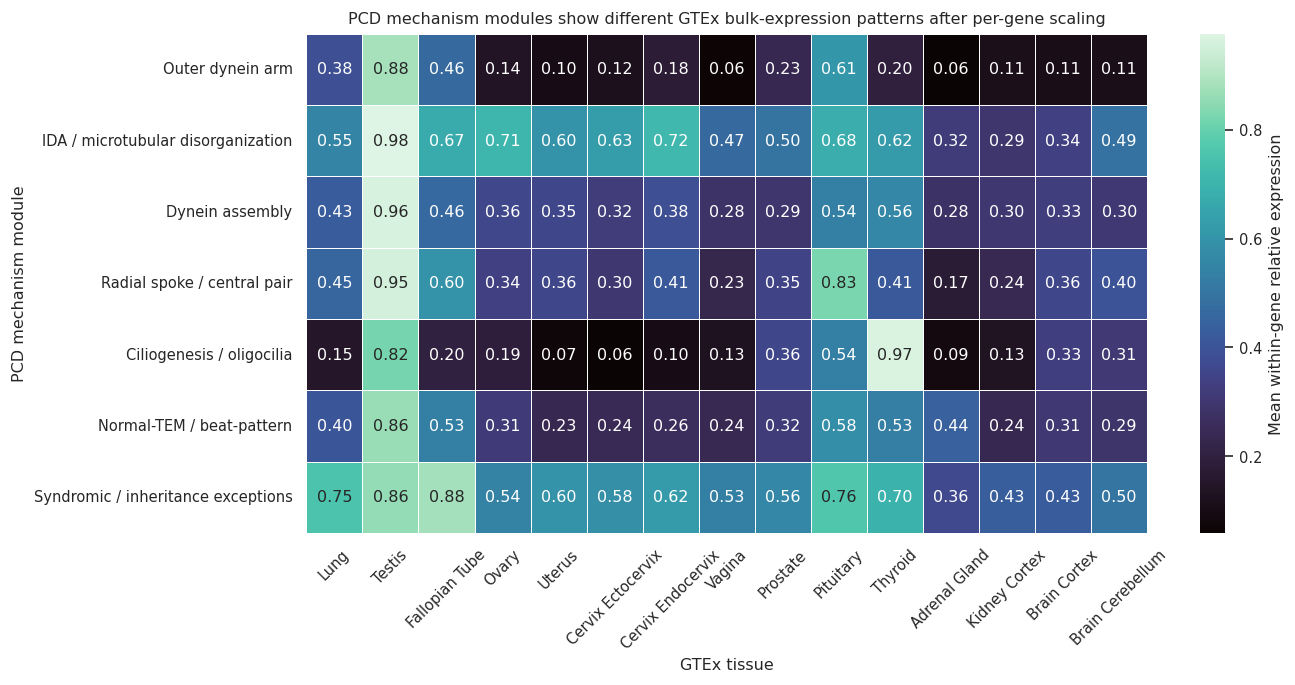

In [ ]:
fig_heatmap, ax_heatmap = plt.subplots(figsize=(11.5, 5.8))
sns.heatmap(
    module_tissue,
    cmap="mako",
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Mean within-gene relative expression"},
    ax=ax_heatmap,
)
ax_heatmap.set_title("PCD mechanism modules show different GTEx bulk-expression patterns after per-gene scaling")
ax_heatmap.set_xlabel("GTEx tissue")
ax_heatmap.set_ylabel("PCD mechanism module")
ax_heatmap.tick_params(axis="x", labelrotation=45)
fig_heatmap.tight_layout()
save_figure(fig_heatmap, "pcd_module_tissue_heatmap")

mo.vstack([
    fig_heatmap,
    mo.md(
        "**How to read this:** each gene is scaled to its own strongest GTEx tissue before "
        "module averages are computed. This emphasizes tissue preference rather than absolute "
        "expression level, reducing the risk that one high-expression gene drives the module map."
    ),
])

Evidence: 24/26 GTEx-resolved genes have at least one reproductive tissue above lung, and 18/26 have a reproductive tissue as their top GTEx tissue. ProteinGym coverage is shown separately in the module coverage chart to avoid overloading this scatter.
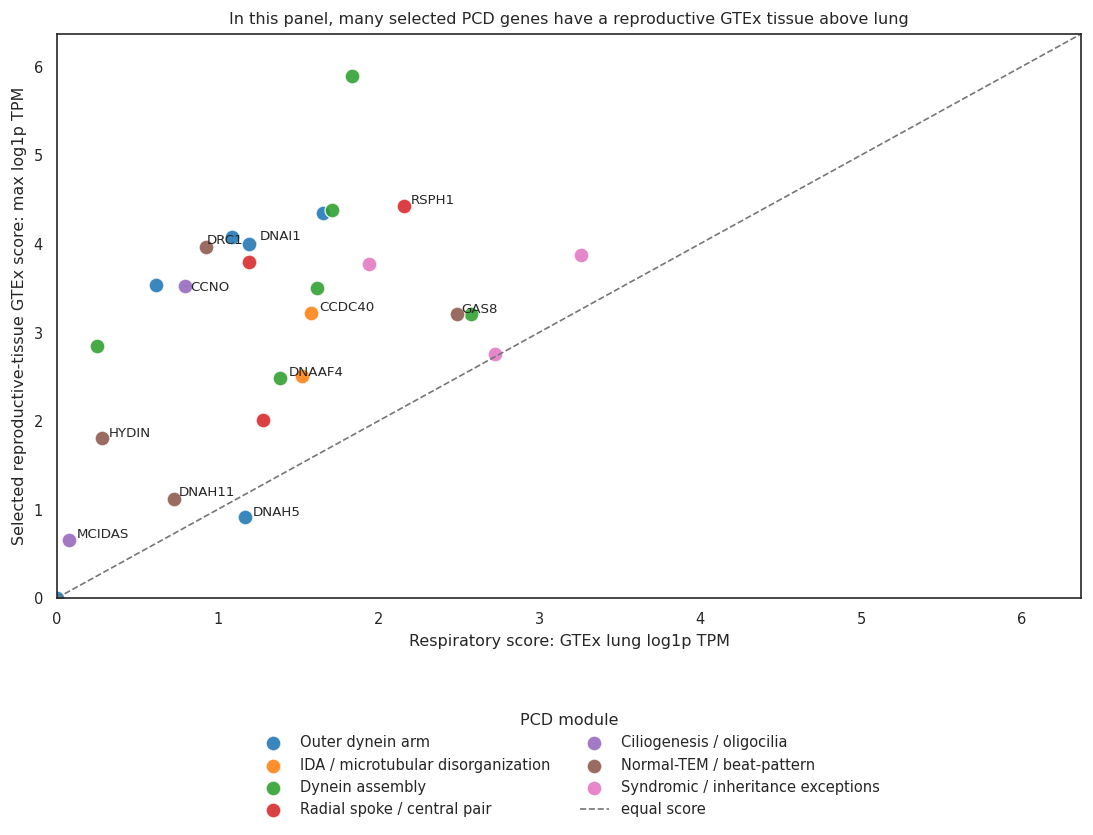

In [ ]:
axis_plot_table = analysis_table[analysis_table["gtex_resolved"]].copy()
fig_axis, ax_axis = plt.subplots(figsize=(9.2, 7.2))

for module_axis, axis_group in axis_plot_table.groupby("pcd_module", observed=True):
    ax_axis.scatter(
        axis_group["respiratory"],
        axis_group["reproductive_max"],
        s=80,
        alpha=0.88,
        label=module_axis,
        color=module_palette[module_axis],
        edgecolor="white",
        linewidth=0.8,
    )

axis_limit = max(axis_plot_table["respiratory"].max(), axis_plot_table["reproductive_max"].max()) * 1.08
ax_axis.plot(
    [0, axis_limit],
    [0, axis_limit],
    color=PALETTE["neutral_mid"],
    linestyle="--",
    linewidth=1,
    label="equal score",
)
ax_axis.set_xlim(0, axis_limit)
ax_axis.set_ylim(0, axis_limit)
ax_axis.set_xlabel("Respiratory score: GTEx lung log1p TPM")
ax_axis.set_ylabel("Selected reproductive-tissue GTEx score: max log1p TPM")
ax_axis.set_title("In this panel, many selected PCD genes have a reproductive GTEx tissue above lung")

label_genes = {
    "DNAH5",
    "DNAH11",
    "DNAI1",
    "CCDC40",
    "DNAAF4",
    "RSPH1",
    "CCNO",
    "MCIDAS",
    "HYDIN",
    "DRC1",
    "GAS8",
}
axis_texts = []
for axis_record in axis_plot_table[axis_plot_table["gene_symbol"].isin(label_genes)].to_dict("records"):
    axis_texts.append(
        ax_axis.text(
            axis_record["respiratory"],
            axis_record["reproductive_max"],
            axis_record["gene_symbol"],
            fontsize=8,
        )
    )
adjust_text(
    axis_texts,
    ax=ax_axis,
    arrowprops={"arrowstyle": "-", "color": PALETTE["neutral_mid"], "lw": 0.5},
)

ax_axis.legend(
    bbox_to_anchor=(0.5, -0.18),
    loc="upper center",
    frameon=False,
    title="PCD module",
    ncol=2,
)
fig_axis.tight_layout()
save_figure(fig_axis, "pcd_reproductive_vs_respiratory_axis")

reproductive_visible = int((axis_plot_table["reproductive_max"] > axis_plot_table["respiratory"]).sum())
resolved_count = len(axis_plot_table)
top_reproductive = int(axis_plot_table["top_tissue_domain"].eq("reproductive").sum())

mo.vstack([
    fig_axis,
    mo.md(
        f"**Evidence:** {reproductive_visible}/{resolved_count} GTEx-resolved genes have at least one "
        f"reproductive tissue above lung, and {top_reproductive}/{resolved_count} have a reproductive "
        "tissue as their top GTEx tissue. ProteinGym coverage is shown separately in the module "
        "coverage chart to avoid overloading this scatter."
    ),
])

Evidence: coverage ranges from complete coverage in dynein assembly and ciliogenesis modules to 0/4 in the normal-TEM / beat-pattern module after checking curated RefSeq candidate IDs. Missing means absent from the checked ProteinGym clinical substitutions under strict RefSeq matching, not biological irrelevance.
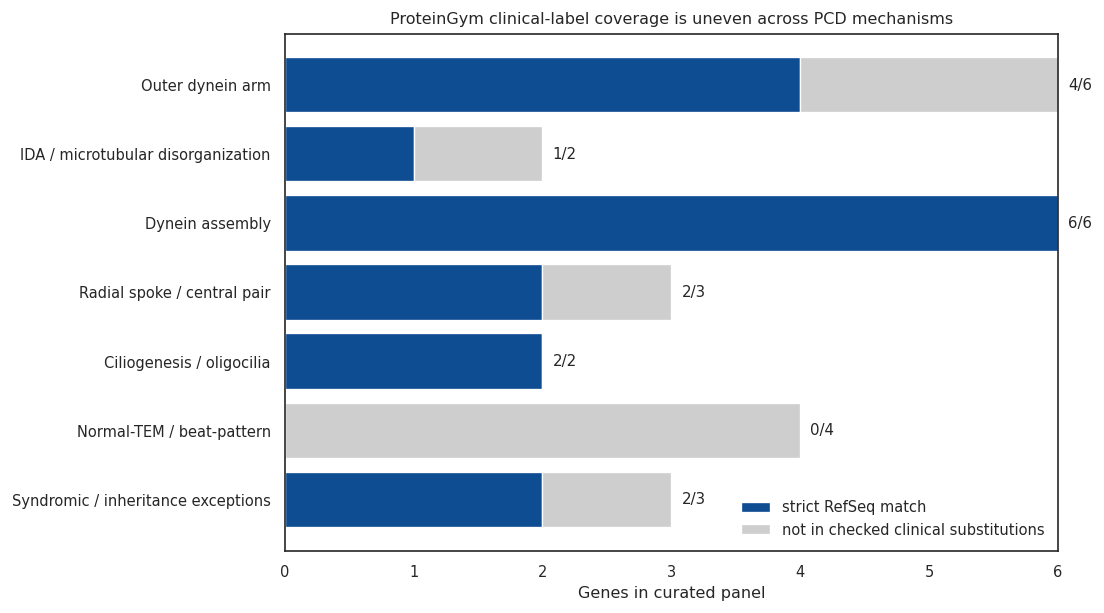

In [ ]:
coverage_by_module = (
    analysis_table.assign(missing=lambda coverage_frame: ~coverage_frame["proteingym_covered"])
    .groupby("pcd_module", observed=True)
    .agg(
        covered=("proteingym_covered", "sum"),
        missing=("missing", "sum"),
        total=("gene_symbol", "count"),
    )
    .reindex(module_order)
    .dropna(how="all")
)
coverage_by_module[["covered", "missing", "total"]] = coverage_by_module[
    ["covered", "missing", "total"]
].astype(int)
coverage_by_module["coverage_fraction"] = coverage_by_module["covered"] / coverage_by_module["total"]

fig_coverage, ax_coverage = plt.subplots(figsize=(9.3, 5.2))
coverage_y = np.arange(len(coverage_by_module))
ax_coverage.barh(
    coverage_y,
    coverage_by_module["covered"],
    color=PALETTE["blue_main"],
    label="strict RefSeq match",
)
ax_coverage.barh(
    coverage_y,
    coverage_by_module["missing"],
    left=coverage_by_module["covered"],
    color=PALETTE["neutral_light"],
    label="not in checked clinical substitutions",
)
for coverage_idx, coverage_record in enumerate(coverage_by_module.to_dict("records")):
    ax_coverage.text(
        coverage_record["total"] + 0.08,
        coverage_idx,
        f"{coverage_record['covered']}/{coverage_record['total']}",
        va="center",
        fontsize=9,
    )
ax_coverage.set_yticks(coverage_y)
ax_coverage.set_yticklabels(coverage_by_module.index)
ax_coverage.set_xlabel("Genes in curated panel")
ax_coverage.set_title("ProteinGym clinical-label coverage is uneven across PCD mechanisms")
ax_coverage.invert_yaxis()
ax_coverage.legend(loc="lower right", frameon=False)
fig_coverage.tight_layout()
save_figure(fig_coverage, "pcd_proteingym_coverage_by_module")

mo.vstack([
    fig_coverage,
    mo.md(
        "**Evidence:** coverage ranges from complete coverage in dynein assembly and ciliogenesis "
        "modules to 0/4 in the normal-TEM / beat-pattern module after checking curated RefSeq "
        "candidate IDs. Missing means absent from the checked ProteinGym clinical substitutions "
        "under strict RefSeq matching, not biological irrelevance."
    ),
])

Definition: gap index = max tissue-domain expression × (1 + diagnostic-subtlety weight) × variant-coverage penalty. It is a public-data prioritization heuristic, not a pathogenicity, severity, or diagnostic score.
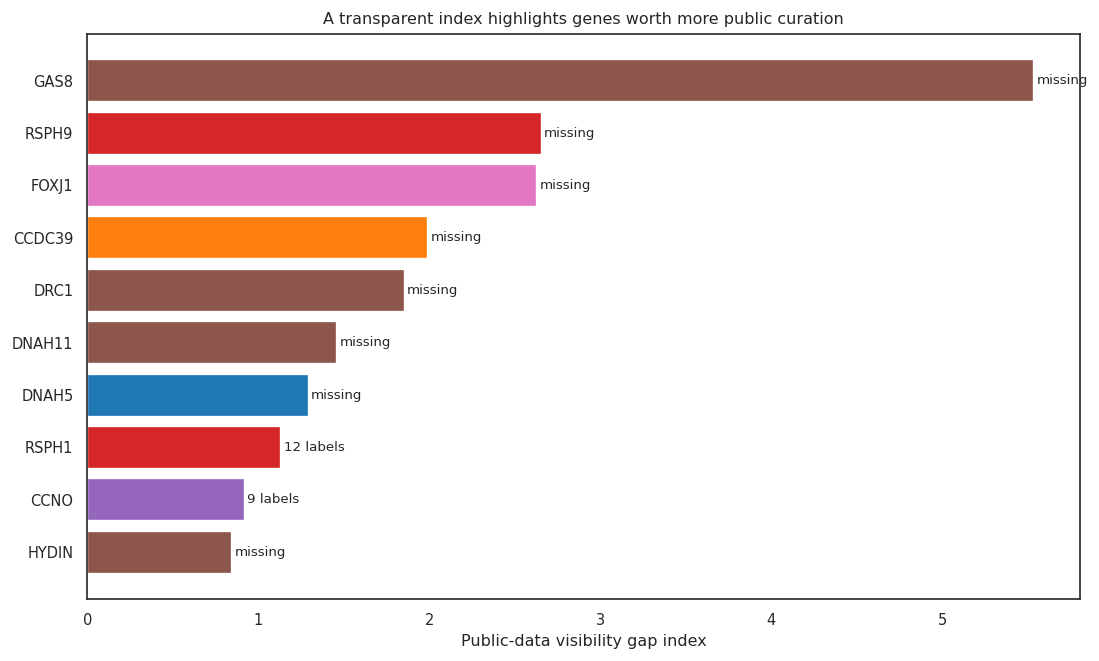

In [ ]:
diagnostic_subtlety = {
    "Normal TEM / beat-pattern": 1.0,
    "Often subtle / variable TEM": 0.65,
    "Reduced cilia number": 0.45,
    "Syndromic / inheritance exception": 0.35,
    "Visible TEM defect": 0.1,
}
analysis_with_gap_scores = analysis_table.assign(
    diagnostic_subtlety_score=analysis_table["diagnostic_visibility"].map(diagnostic_subtlety).fillna(0.25),
    variant_coverage_penalty=np.where(
        analysis_table["proteingym_covered"],
        1 / np.sqrt(analysis_table["clinical_variant_count"] + 1),
        1.0,
    ),
)
analysis_with_gap_scores["public_data_gap_score"] = (
    analysis_with_gap_scores["max_domain_score"].fillna(0)
    * (1 + analysis_with_gap_scores["diagnostic_subtlety_score"])
    * analysis_with_gap_scores["variant_coverage_penalty"]
)

gap_ranking = analysis_with_gap_scores.sort_values("public_data_gap_score", ascending=False)[
    [
        "gene_symbol",
        "pcd_module",
        "diagnostic_visibility",
        "top_gtex_tissue",
        "respiratory",
        "reproductive_max",
        "proteingym_covered",
        "clinical_variant_count",
        "public_data_gap_score",
    ]
].reset_index(drop=True)

top_gap = gap_ranking.head(10).copy()
fig_gap, ax_gap = plt.subplots(figsize=(9.3, 5.6))
gap_bar_colors = [module_palette[gap_module] for gap_module in top_gap["pcd_module"]]
ax_gap.barh(top_gap["gene_symbol"], top_gap["public_data_gap_score"], color=gap_bar_colors)
ax_gap.set_xlabel("Public-data visibility gap index")
ax_gap.set_title("A transparent index highlights genes worth more public curation")
ax_gap.invert_yaxis()
for gap_idx, gap_record in enumerate(top_gap.to_dict("records")):
    gap_label = "missing" if not gap_record["proteingym_covered"] else f"{gap_record['clinical_variant_count']} labels"
    ax_gap.text(gap_record["public_data_gap_score"] + 0.02, gap_idx, gap_label, va="center", fontsize=8)
fig_gap.tight_layout()
save_figure(fig_gap, "pcd_public_data_gap_ranking")

mo.vstack([
    fig_gap,
    mo.md(
        "**Definition:** gap index = max tissue-domain expression × (1 + diagnostic-subtlety weight) "
        "× variant-coverage penalty. It is a public-data prioritization heuristic, not a pathogenicity, "
        "severity, or diagnostic score."
    ),
])

In [ ]:
male_reproductive_tissues = ["Testis", "Prostate"]
female_reproductive_tissues = [
    "Fallopian_Tube", "Ovary", "Uterus", "Cervix_Ectocervix", "Cervix_Endocervix", "Vagina",
]
sex_axis_scores = []
for sex_axis_gene, sex_axis_group in gtex_expression.groupby("gene_symbol"):
    sex_axis_scores.append({
        "gene_symbol": sex_axis_gene,
        "male_reproductive_max": sex_axis_group.loc[sex_axis_group["tissue"].isin(male_reproductive_tissues), "log1p_tpm"].max(),
        "female_reproductive_max": sex_axis_group.loc[sex_axis_group["tissue"].isin(female_reproductive_tissues), "log1p_tpm"].max(),
    })
sex_axis_scores = pd.DataFrame(sex_axis_scores)
analysis_table_extended = analysis_with_gap_scores.merge(sex_axis_scores, on="gene_symbol", how="left")
analysis_table_extended["sex_axis_bias"] = analysis_table_extended["male_reproductive_max"] - analysis_table_extended["female_reproductive_max"]
sex_axis_summary = (
    analysis_table_extended.groupby("pcd_module", observed=True)[["male_reproductive_max", "female_reproductive_max", "respiratory"]]
    .mean().round(2).reset_index()
)
mo.vstack([
    mo.md("## Male and Female Reproductive Visibility\n\nThe reproductive axis can be split into male-associated GTEx tissues (`Testis`, `Prostate`) and female-associated GTEx tissues (`Fallopian Tube`, `Ovary`, `Uterus`, `Cervix`, `Vagina`). This is tissue context, not symptom prediction."),
    mo.ui.table(sex_axis_summary, pagination=False),
])

Male and Female Reproductive Visibility 
 The reproductive axis can be split into male-associated GTEx tissues ( Testis , Prostate ) and female-associated GTEx tissues ( Fallopian Tube , Ovary , Uterus , Cervix , Vagina ). This is tissue context, not symptom prediction. <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"_marimo_row_id\":0,\"pcd_module\":\"Outer dynein arm\",\"male_reproductive_max\":2.81,\"female_reproductive_max\":1.43,\"respiratory\":0.95},{\"_marimo_row_id\":1,\"pcd_module\":\"IDA / microtubular disorganization\",\"male_reproductive_max\":2.8,\"female_reproductive_max\":2.38,\"respiratory\":1.55},{\"_marimo_row_id\":2,\"pcd_module\":\"Dynein assembly\",\"male_reproductive_max\":3.65,\"female_reproductive_max\":1.86,\"respiratory\":1.56},{\"_marimo_row_id\":3,\"pcd_module\":\"Radial spoke / central pair\",\"male_reproductive_max\":3.41,\"female_reproductive_max\":2.05,\"respiratory\":1.55},{\"_marimo_row_id\":4,\"pcd_module\":\"Ciliogenesis / oligocilia\",\"male_reproductive_max\":2.09,\"female_reproductive_max\":0.7,\"respiratory\":0.44},{\"_marimo_row_id\":5,\"pcd_module\":\"Normal-TEM / beat-pattern\",\"male_reproductive_max\":2.43,\"female_reproductive_max\":1.46,\"respiratory\":1.11},{\"_marimo_row_id\":6,\"pcd_module\":\"Syndromic / inheritance exceptions\",\"male_reproductive_max\":3.2,\"female_reproductive_max\":3.15,\"respiratory\":2.64}]"' data-total-rows='7' data-total-columns='4' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='7' data-field-types='[["pcd_module",["string","category"]],["male_reproductive_max",["number","float64"]],["female_reproductive_max",["number","float64"]],["respiratory",["number","float64"]]]' data-selection='"multi"' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='true' data-lazy='false' data-preload='false'>

Evidence: the normal-TEM / beat-pattern class is 0/4 covered in the strict ProteinGym check while still showing GTEx tissue visibility.
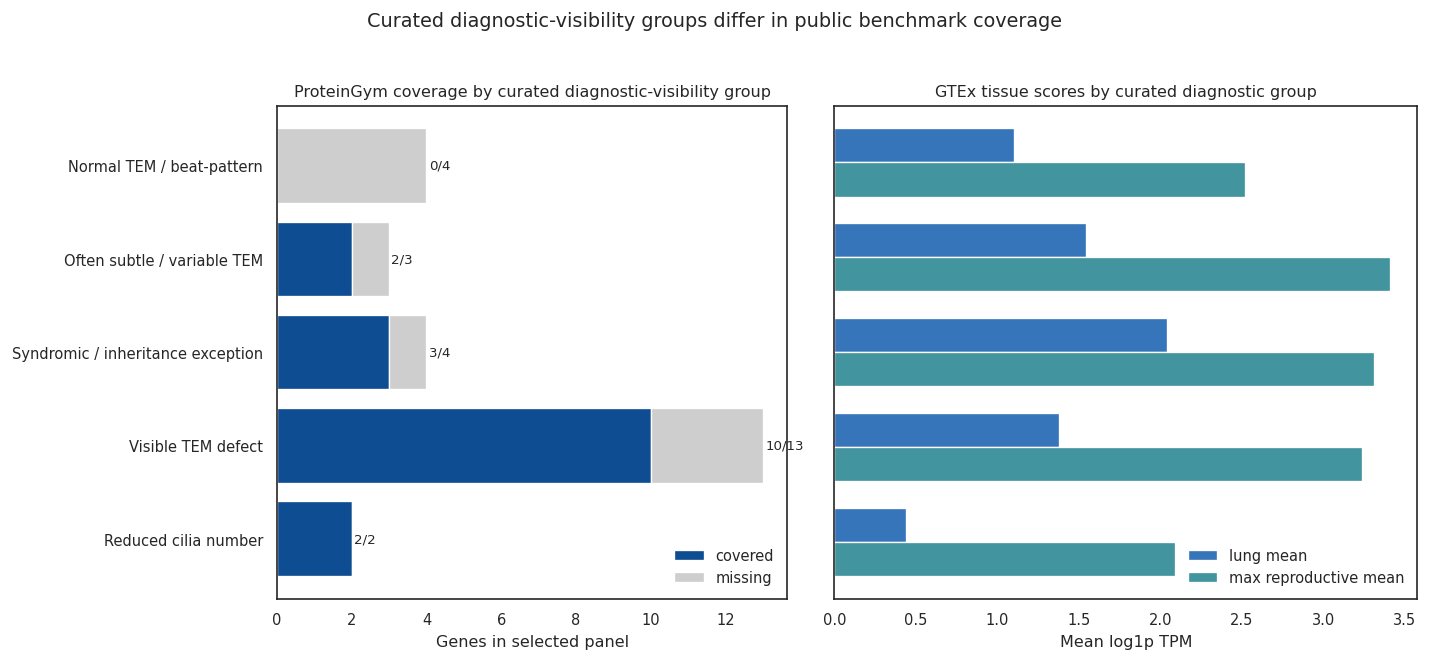

In [ ]:
diagnostic_summary = (
    analysis_table_extended.assign(missing=lambda diagnostic_frame: ~diagnostic_frame["proteingym_covered"])
    .groupby("diagnostic_visibility")
    .agg(
        genes=("gene_symbol", "count"), covered=("proteingym_covered", "sum"), missing=("missing", "sum"),
        lung_mean=("respiratory", "mean"), reproductive_max_mean=("reproductive_max", "mean"),
    ).reset_index()
)
diagnostic_summary[["covered", "missing", "genes"]] = diagnostic_summary[["covered", "missing", "genes"]].astype(int)
diagnostic_summary["coverage_fraction"] = diagnostic_summary["covered"] / diagnostic_summary["genes"]
diagnostic_order = diagnostic_summary.sort_values("coverage_fraction")["diagnostic_visibility"].tolist()
diagnostic_plot = diagnostic_summary.set_index("diagnostic_visibility").loc[diagnostic_order]
fig_diagnostic, (ax_diag_cov, ax_diag_expr) = plt.subplots(ncols=2, figsize=(12, 5.3), gridspec_kw={"width_ratios": [1.05, 1.2]})
diag_y = np.arange(len(diagnostic_plot))
ax_diag_cov.barh(diag_y, diagnostic_plot["covered"], color=PALETTE["blue_main"], label="covered")
ax_diag_cov.barh(diag_y, diagnostic_plot["missing"], left=diagnostic_plot["covered"], color=PALETTE["neutral_light"], label="missing")
for diag_idx, diag_record in enumerate(diagnostic_plot.to_dict("records")):
    ax_diag_cov.text(diag_record["genes"] + 0.06, diag_idx, f"{diag_record['covered']}/{diag_record['genes']}", va="center", fontsize=8)
ax_diag_cov.set_yticks(diag_y)
ax_diag_cov.set_yticklabels(diagnostic_plot.index)
ax_diag_cov.set_xlabel("Genes in selected panel")
ax_diag_cov.set_title("ProteinGym coverage by curated diagnostic-visibility group")
ax_diag_cov.invert_yaxis()
ax_diag_cov.legend(loc="lower right", frameon=False)
bar_width_diag = 0.36
ax_diag_expr.barh(diag_y - bar_width_diag / 2, diagnostic_plot["lung_mean"], height=bar_width_diag, color=PALETTE["blue_secondary"], label="lung mean")
ax_diag_expr.barh(diag_y + bar_width_diag / 2, diagnostic_plot["reproductive_max_mean"], height=bar_width_diag, color=PALETTE["teal"], label="max reproductive mean")
ax_diag_expr.set_yticks(diag_y)
ax_diag_expr.set_yticklabels([])
ax_diag_expr.set_xlabel("Mean log1p TPM")
ax_diag_expr.set_title("GTEx tissue scores by curated diagnostic group")
ax_diag_expr.invert_yaxis()
ax_diag_expr.legend(loc="lower right", frameon=False)
fig_diagnostic.suptitle("Curated diagnostic-visibility groups differ in public benchmark coverage", y=1.03)
fig_diagnostic.tight_layout()
save_figure(fig_diagnostic, "pcd_diagnostic_visibility_comparison")
mo.vstack([fig_diagnostic, mo.md("**Evidence:** the normal-TEM / beat-pattern class is 0/4 covered in the strict ProteinGym check while still showing GTEx tissue visibility.")])

How to read this: upper-left genes combine diagnostic subtlety with little or no public ProteinGym clinical-label evidence. The grouped callout marks the four normal-TEM / beat-pattern genes that share the same strict zero-coverage corner.
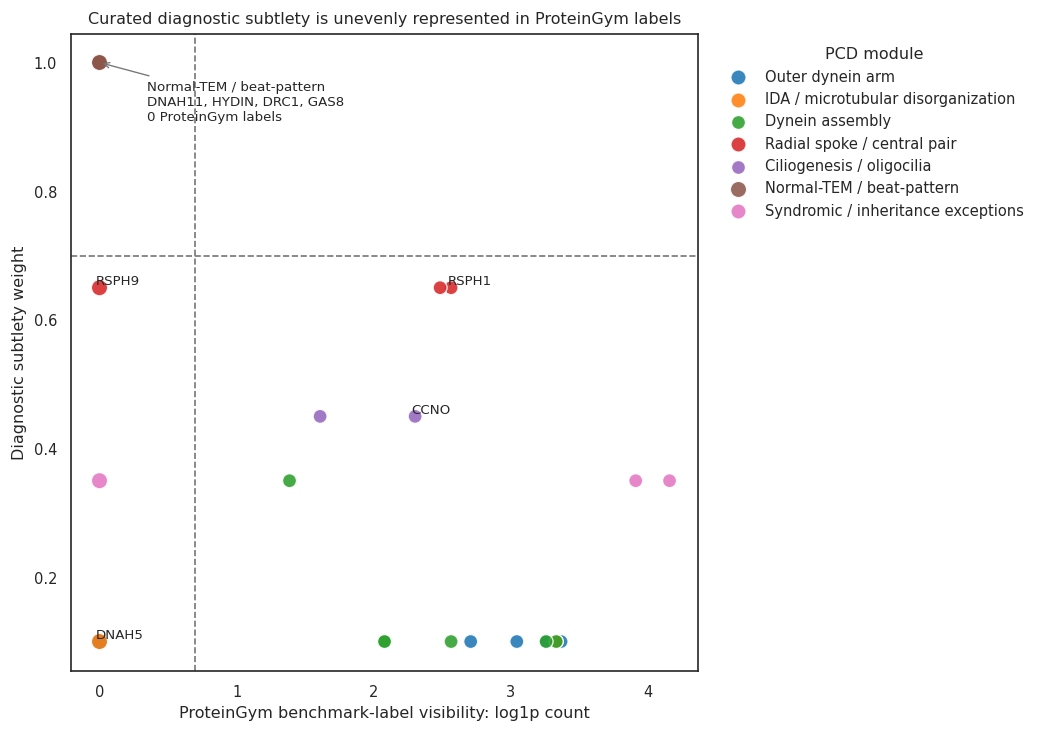

In [ ]:
quadrant_table = analysis_table_extended.copy()
quadrant_table["variant_evidence_score"] = np.log1p(quadrant_table["clinical_variant_count"])
quadrant_table["uncovered"] = ~quadrant_table["proteingym_covered"]
fig_quadrant, ax_quad = plt.subplots(figsize=(8.8, 6.2))
for quad_module, quad_group in quadrant_table.groupby("pcd_module", observed=True):
    ax_quad.scatter(
        quad_group["variant_evidence_score"],
        quad_group["diagnostic_subtlety_score"],
        s=np.where(quad_group["uncovered"], 95, 70),
        color=module_palette[quad_module],
        edgecolor="white",
        linewidth=0.8,
        alpha=0.88,
        label=quad_module,
    )
ax_quad.axvline(np.log1p(1), color=PALETTE["neutral_mid"], linestyle="--", linewidth=1)
ax_quad.axhline(0.7, color=PALETTE["neutral_mid"], linestyle="--", linewidth=1)
ax_quad.set_xlabel("ProteinGym benchmark-label visibility: log1p count")
ax_quad.set_ylabel("Diagnostic subtlety weight")
ax_quad.set_title("Curated diagnostic subtlety is unevenly represented in ProteinGym labels")

ax_quad.annotate(
    "Normal-TEM / beat-pattern\nDNAH11, HYDIN, DRC1, GAS8\n0 ProteinGym labels",
    xy=(0, 1.0),
    xytext=(0.35, 0.91),
    arrowprops={"arrowstyle": "->", "color": PALETTE["neutral_mid"], "lw": 0.8},
    fontsize=8,
    ha="left",
)
quad_labels = {"DNAH5", "RSPH9", "RSPH1", "CCNO"}
quad_texts = []
for quad_record in quadrant_table[quadrant_table["gene_symbol"].isin(quad_labels)].to_dict("records"):
    quad_texts.append(
        ax_quad.text(
            quad_record["variant_evidence_score"],
            quad_record["diagnostic_subtlety_score"],
            quad_record["gene_symbol"],
            fontsize=8,
        )
    )
adjust_text(
    quad_texts,
    ax=ax_quad,
    arrowprops={"arrowstyle": "-", "color": PALETTE["neutral_mid"], "lw": 0.5},
)
ax_quad.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, title="PCD module")
fig_quadrant.tight_layout()
save_figure(fig_quadrant, "pcd_diagnostic_subtlety_variant_evidence_quadrant")
mo.vstack([
    fig_quadrant,
    mo.md(
        "**How to read this:** upper-left genes combine diagnostic subtlety with little or no "
        "public ProteinGym clinical-label evidence. The grouped callout marks the four "
        "normal-TEM / beat-pattern genes that share the same strict zero-coverage corner."
    ),
])

Caveat: these are benchmark labels, not true PCD prevalence or definitive clinical interpretation.
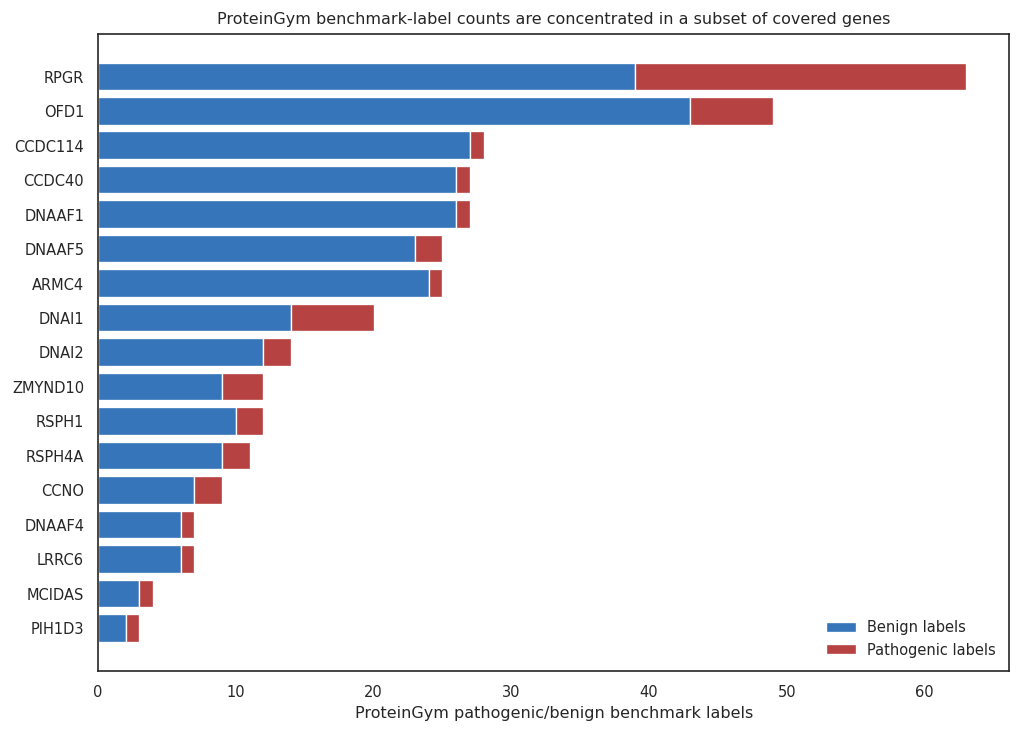

In [ ]:
burden_table = analysis_table_extended[analysis_table_extended["proteingym_covered"]].copy().sort_values("clinical_variant_count", ascending=True)
fig_burden, ax_burden = plt.subplots(figsize=(8.6, 6.2))
burden_y = np.arange(len(burden_table))
ax_burden.barh(burden_y, burden_table["benign_count"], color=PALETTE["blue_secondary"], label="Benign labels")
ax_burden.barh(burden_y, burden_table["pathogenic_count"], left=burden_table["benign_count"], color=PALETTE["red"], label="Pathogenic labels")
ax_burden.set_yticks(burden_y)
ax_burden.set_yticklabels(burden_table["gene_symbol"])
ax_burden.set_xlabel("ProteinGym pathogenic/benign benchmark labels")
ax_burden.set_title("ProteinGym benchmark-label counts are concentrated in a subset of covered genes")
ax_burden.legend(loc="lower right", frameon=False)
fig_burden.tight_layout()
save_figure(fig_burden, "pcd_proteingym_benign_pathogenic_burden")
mo.vstack([fig_burden, mo.md("**Caveat:** these are benchmark labels, not true PCD prevalence or definitive clinical interpretation.")])

In [ ]:
context_card_genes = ["DNAH11", "GAS8", "DNAH5", "DNAAF4", "RSPH1", "CCNO"]
context_cards = analysis_table_extended[analysis_table_extended["gene_symbol"].isin(context_card_genes)].copy()
context_cards["top_gtex_tissue"] = context_cards["top_gtex_tissue"].str.replace("_", " ")
context_cards["coverage_summary"] = np.where(context_cards["proteingym_covered"], context_cards["clinical_variant_count"].astype(str) + " clinical labels", "no strict RefSeq match")
context_cards["reproductive_visibility"] = context_cards["reproductive_max"].round(2)
context_cards["lung_visibility"] = context_cards["respiratory"].round(2)
card_rows = []
for card_record in context_cards.sort_values("public_data_gap_score", ascending=False).to_dict("records"):
    card_rows.append([
        card_record["gene_symbol"], str(card_record["pcd_module"]), card_record["diagnostic_visibility"], card_record["top_gtex_tissue"],
        f"{card_record['lung_visibility']} / {card_record['reproductive_visibility']}", card_record["coverage_summary"],
    ])
mo.vstack([
    mo.md("## Tissue-Aware Gene Context Cards\n\nThese compact cards translate the module-level findings back to individual genes. They are intended for interpretation and prioritization, not clinical variant review."),
    mo.ui.table(pd.DataFrame(card_rows, columns=["Gene", "Module", "Diagnostic context", "Top GTEx tissue", "Lung / reproductive max log1p TPM", "ProteinGym status"]), pagination=False),
])

Tissue-Aware Gene Context Cards 
 These compact cards translate the module-level findings back to individual genes. They are intended for interpretation and prioritization, not clinical variant review. <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"_marimo_row_id\":0,\"Gene\":\"GAS8\",\"Module\":\"Normal-TEM / beat-pattern\",\"Diagnostic context\":\"Normal TEM / beat-pattern\",\"Top GTEx tissue\":\"Pituitary\",\"Lung / reproductive max log1p TPM\":\"2.49 / 3.21\",\"ProteinGym status\":\"no strict RefSeq match\"},{\"_marimo_row_id\":1,\"Gene\":\"DNAH11\",\"Module\":\"Normal-TEM / beat-pattern\",\"Diagnostic context\":\"Normal TEM / beat-pattern\",\"Top GTEx tissue\":\"Esophagus Muscularis\",\"Lung / reproductive max log1p TPM\":\"0.73 / 1.11\",\"ProteinGym status\":\"no strict RefSeq match\"},{\"_marimo_row_id\":2,\"Gene\":\"DNAH5\",\"Module\":\"Outer dynein arm\",\"Diagnostic context\":\"Visible TEM defect\",\"Top GTEx tissue\":\"Pituitary\",\"Lung / reproductive max log1p TPM\":\"1.17 / 0.91\",\"ProteinGym status\":\"no strict RefSeq match\"},{\"_marimo_row_id\":3,\"Gene\":\"RSPH1\",\"Module\":\"Radial spoke / central pair\",\"Diagnostic context\":\"Often subtle / variable TEM\",\"Top GTEx tissue\":\"Testis\",\"Lung / reproductive max log1p TPM\":\"2.16 / 4.43\",\"ProteinGym status\":\"12 clinical labels\"},{\"_marimo_row_id\":4,\"Gene\":\"CCNO\",\"Module\":\"Ciliogenesis / oligocilia\",\"Diagnostic context\":\"Reduced cilia number\",\"Top GTEx tissue\":\"Testis\",\"Lung / reproductive max log1p TPM\":\"0.8 / 3.52\",\"ProteinGym status\":\"9 clinical labels\"},{\"_marimo_row_id\":5,\"Gene\":\"DNAAF4\",\"Module\":\"Dynein assembly\",\"Diagnostic context\":\"Visible TEM defect\",\"Top GTEx tissue\":\"Thyroid\",\"Lung / reproductive max log1p TPM\":\"1.39 / 2.49\",\"ProteinGym status\":\"7 clinical labels\"}]"' data-total-rows='6' data-total-columns='6' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='6' data-field-types='[["Gene",["string","str"]],["Module",["string","str"]],["Diagnostic context",["string","str"]],["Top GTEx tissue",["string","str"]],["Lung / reproductive max log1p TPM",["string","str"]],["ProteinGym status",["string","str"]]]' data-selection='"multi"' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='true' data-lazy='false' data-preload='false'>

In [ ]:

findings_resolved = analysis_table[analysis_table["gtex_resolved"]].copy()
findings_normal_tem = analysis_table[
    analysis_table["diagnostic_visibility"].eq("Normal TEM / beat-pattern")
]
findings_normal_tem_covered = int(findings_normal_tem["proteingym_covered"].sum())
findings_normal_tem_total = len(findings_normal_tem)
findings_covered_total = int(analysis_table["proteingym_covered"].sum())
findings_panel_total = len(analysis_table)
findings_resolved_total = len(findings_resolved)
findings_repro_max_dominant = int(
    (findings_resolved["reproductive_max"] > findings_resolved["respiratory"]).sum()
)
findings_top_reproductive = int(findings_resolved["top_tissue_domain"].eq("reproductive").sum())

mo.md(
    f"""
## Core Backbone Checkpoint

Before adding external public-data layers, the official-dataset backbone already shows the central pattern:

- **GTEx resolves {findings_resolved_total}/{findings_panel_total} selected genes**, including `DNAAF4` through `DYX1C1`.
- **{findings_repro_max_dominant}/{findings_resolved_total} genes have at least one selected reproductive tissue above lung**, and **{findings_top_reproductive}/{findings_resolved_total}** have a reproductive top GTEx tissue.
- **ProteinGym strict RefSeq matching covers {findings_covered_total}/{findings_panel_total} genes**, but **{findings_normal_tem_covered}/{findings_normal_tem_total}** normal-TEM / beat-pattern genes.

The final atlas section below tests whether ClinVar, PubMed, Open Targets, DMS metadata, phenotype context, and trial context strengthen or qualify this backbone story.
"""
)

## Core Backbone Checkpoint

Before adding external public-data layers, the official-dataset backbone already shows the central pattern:

- **GTEx resolves 26/26 selected genes**, including `DNAAF4` through `DYX1C1`.
- **24/26 genes have at least one selected reproductive tissue above lung**, and **18/26** have a reproductive top GTEx tissue.
- **ProteinGym strict RefSeq matching covers 17/26 genes**, but **0/4** normal-TEM / beat-pattern genes.

The final atlas section below tests whether ClinVar, PubMed, Open Targets, DMS metadata, phenotype context, and trial context strengthen or qualify this backbone story.

## Interpretation Guardrails for the Atlas

- **GTEx is bulk normal tissue.** Lung expression is not the same as airway ciliated-cell expression, and high expression in a tissue does not prove clinical involvement.
- **The reproductive axis is a visibility axis.** It shows where selected genes are strongly expressed in selected public bulk GTEx tissues, not who will experience fertility symptoms.
- **ProteinGym clinical substitutions are benchmark labels.** Counts describe public benchmark coverage under strict RefSeq matching and a conservative gene-level counting rule, not how common variants are in PCD.
- **ClinVar and PubMed are visibility layers.** ClinVar gene-summary counts are public submission aggregates; PubMed counts are title/abstract ESearch metadata with no quality filter or systematic-review guarantee.
- **The phenotype heatmap is schematic.** Its body-system tags are curated disease-context annotations for communication, not data-derived probabilities of organ involvement by gene or module.
- **DMS, HPA, Open Targets, and trials answer different questions.** DMS metadata checks assay availability, HPA provides independent tissue/cell context, Open Targets aggregates disease-gene evidence, and trial records provide translational context. None replace clinical genetics review.
- **ClinicalTrials.gov rows are source-dated context.** Trial status can change, and this notebook makes no treatment, safety, efficacy, or eligibility recommendation.
- **Cold-cache reruns require network access.** The notebook caches processed public pulls under `data/processed/`; fresh runs depend on GTEx, Hugging Face, NCBI, ClinicalTrials.gov, Open Targets, and GitHub endpoints being available.
- **The gap index is a heuristic.** It is useful for research-prioritization discussion, not diagnosis, pathogenicity scoring, prognosis, or treatment recommendation.

**Guardrail for the rest of the notebook:** in bulk GTEx and public evidence catalogs, PCD genes show multiple visible axes of biology while benchmark-ready variant resources unevenly cover the genes and diagnostic contexts that make PCD difficult to recognize.

## Expanded Public-Data Layers

The official-dataset backbone remains **GTEx v8** plus **ProteinGym v1**. The following sections add public, aggregate external context only where it strengthens or qualifies the atlas:

- **ClinVar gene-specific summary** for gene-level clinical-variant catalog visibility.
- **ProteinGym DMS substitutions metadata** for mutation-effect assay coverage.
- **PubMed E-utilities** for query-dependent literature visibility.
- **ClinicalTrials.gov**, public phenotype/prognosis sources, **Human Protein Atlas**, and **Open Targets** as source-cited context layers.

These layers describe public-data visibility and disease-level context. They are not used to diagnose PCD, predict prognosis, recommend treatment, or interpret individual variants.

In [ ]:

atlas_clinvar_url = "https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/gene_specific_summary.txt"
atlas_clinvar_cache = PROCESSED_DIR / "pcd_clinvar_gene_specific_summary.csv"
atlas_clinvar_numeric_cols = [
    "Total_submissions",
    "Total_alleles",
    "Submissions_reporting_this_gene",
    "Alleles_reported_Pathogenic_Likely_pathogenic",
    "Number_uncertain",
    "Number_with_conflicts",
]

if atlas_clinvar_cache.exists():
    atlas_clinvar_visibility = pd.read_csv(atlas_clinvar_cache)
    if "clinvar_fetch_status" not in atlas_clinvar_visibility.columns:
        atlas_clinvar_visibility["clinvar_fetch_status"] = "ok_cached_without_status"
else:
    try:
        atlas_clinvar_raw = pd.read_csv(atlas_clinvar_url, sep="\t", skiprows=1, dtype=str)
        atlas_clinvar_raw = atlas_clinvar_raw.rename(columns={"#Symbol": "gene_symbol"})
        for atlas_clinvar_metric_col in atlas_clinvar_numeric_cols:
            atlas_clinvar_raw[atlas_clinvar_metric_col] = (
                pd.to_numeric(atlas_clinvar_raw[atlas_clinvar_metric_col].replace("-", 0), errors="coerce")
                .fillna(0)
                .astype(int)
            )
        atlas_clinvar_visibility = atlas_clinvar_raw[["gene_symbol", "GeneID", *atlas_clinvar_numeric_cols]].copy()
        atlas_clinvar_visibility["clinvar_fetch_status"] = "ok"
        atlas_clinvar_visibility.to_csv(atlas_clinvar_cache, index=False)
    except Exception as atlas_clinvar_error:
        atlas_clinvar_visibility = pd.DataFrame(
            {
                "gene_symbol": analysis_table_extended["gene_symbol"],
                "GeneID": "",
                "Total_submissions": 0,
                "Total_alleles": 0,
                "Submissions_reporting_this_gene": 0,
                "Alleles_reported_Pathogenic_Likely_pathogenic": 0,
                "Number_uncertain": 0,
                "Number_with_conflicts": 0,
                "clinvar_fetch_status": f"fetch_failed: {atlas_clinvar_error}",
            }
        )

atlas_clinvar_panel = analysis_table_extended[["gene_symbol"]].merge(atlas_clinvar_visibility, on="gene_symbol", how="left")
if "clinvar_fetch_status" not in atlas_clinvar_panel.columns:
    atlas_clinvar_panel["clinvar_fetch_status"] = "missing_status"
atlas_clinvar_panel["clinvar_fetch_status"] = atlas_clinvar_panel["clinvar_fetch_status"].fillna("fetched_symbol_absent")
for atlas_panel_metric_col in atlas_clinvar_numeric_cols:
    atlas_clinvar_panel[atlas_panel_metric_col] = atlas_clinvar_panel[atlas_panel_metric_col].fillna(0).astype(int)
atlas_clinvar_panel["clinvar_total_records"] = atlas_clinvar_panel["Total_alleles"]
atlas_clinvar_panel["clinvar_pathogenic_like"] = atlas_clinvar_panel["Alleles_reported_Pathogenic_Likely_pathogenic"]
atlas_clinvar_panel["clinvar_uncertain"] = atlas_clinvar_panel["Number_uncertain"]
atlas_clinvar_panel["clinvar_visible"] = atlas_clinvar_panel["clinvar_total_records"] > 0
atlas_clinvar_panel["clinvar_visibility_score"] = np.log1p(atlas_clinvar_panel["clinvar_total_records"])

atlas_after_clinvar = analysis_table_extended.merge(
    atlas_clinvar_panel[
        [
            "gene_symbol",
            "clinvar_total_records",
            "clinvar_pathogenic_like",
            "clinvar_uncertain",
            "clinvar_visible",
            "clinvar_visibility_score",
            "clinvar_fetch_status",
        ]
    ],
    on="gene_symbol",
    how="left",
)
atlas_clinvar_missing_pg_present = atlas_after_clinvar[
    (~atlas_after_clinvar["proteingym_covered"]) & atlas_after_clinvar["clinvar_visible"]
][["gene_symbol", "pcd_module", "diagnostic_visibility", "clinvar_total_records", "clinvar_pathogenic_like"]].sort_values("clinvar_total_records", ascending=False)

atlas_dms_url = "https://raw.githubusercontent.com/OATML-Markslab/ProteinGym/main/reference_files/DMS_substitutions.csv"
atlas_dms_cache = PROCESSED_DIR / "proteingym_dms_substitutions_metadata_pcd_check.csv"
if atlas_dms_cache.exists():
    atlas_mutation_effect_context = pd.read_csv(atlas_dms_cache)
else:
    try:
        atlas_dms_metadata = pd.read_csv(
            atlas_dms_url,
            usecols=["DMS_id", "UniProt_ID", "molecule_name", "title", "source_organism", "selection_type"],
        )
        atlas_dms_search_text = atlas_dms_metadata.fillna("").astype(str).agg(" ".join, axis=1)
        atlas_dms_rows = []
        for atlas_dms_gene_symbol in atlas_after_clinvar["gene_symbol"].tolist():
            atlas_dms_hits = atlas_dms_metadata[atlas_dms_search_text.str.contains(atlas_dms_gene_symbol, case=False, regex=False)]
            atlas_dms_rows.append(
                {
                    "gene_symbol": atlas_dms_gene_symbol,
                    "proteingym_dms_assay_count": len(atlas_dms_hits),
                    "proteingym_dms_examples": "; ".join(atlas_dms_hits["DMS_id"].head(3).tolist()),
                    "mutation_effect_source": atlas_dms_url,
                    "constraint_status": "gnomAD constraint demoted: no small stable public TSV/API path used in this notebook run",
                }
            )
        atlas_mutation_effect_context = pd.DataFrame(atlas_dms_rows)
        atlas_mutation_effect_context.to_csv(atlas_dms_cache, index=False)
    except Exception as atlas_dms_error:
        atlas_mutation_effect_context = pd.DataFrame(
            {
                "gene_symbol": atlas_after_clinvar["gene_symbol"],
                "proteingym_dms_assay_count": 0,
                "proteingym_dms_examples": "",
                "mutation_effect_source": atlas_dms_url,
                "constraint_status": f"DMS metadata fetch failed: {atlas_dms_error}",
            }
        )

atlas_after_mutation = atlas_after_clinvar.merge(atlas_mutation_effect_context, on="gene_symbol", how="left")
atlas_after_mutation["proteingym_dms_covered"] = atlas_after_mutation["proteingym_dms_assay_count"].fillna(0).astype(int) > 0

atlas_pubmed_cache = PROCESSED_DIR / "pcd_pubmed_visibility_counts.csv"
atlas_pubmed_api_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
atlas_pubmed_visibility = None
if atlas_pubmed_cache.exists():
    atlas_pubmed_visibility = pd.read_csv(atlas_pubmed_cache)
    if "pubmed_pcd_fetch_status" not in atlas_pubmed_visibility.columns or "pubmed_gene_fetch_status" not in atlas_pubmed_visibility.columns:
        atlas_pubmed_cache.unlink()
        atlas_pubmed_visibility = None
if atlas_pubmed_visibility is None:
    atlas_pubmed_rows = []
    for atlas_pubmed_gene_symbol in atlas_after_mutation["gene_symbol"].tolist():
        atlas_pubmed_pcd_query = f'("{atlas_pubmed_gene_symbol}"[Title/Abstract]) AND ("primary ciliary dyskinesia"[Title/Abstract] OR PCD[Title/Abstract])'
        atlas_pubmed_gene_query = f'"{atlas_pubmed_gene_symbol}"[Title/Abstract]'
        atlas_pubmed_counts_for_gene = {}
        atlas_pubmed_status_for_gene = {}
        for atlas_pubmed_query_name, atlas_pubmed_query_text in [
            ("pubmed_pcd_count", atlas_pubmed_pcd_query),
            ("pubmed_gene_count", atlas_pubmed_gene_query),
        ]:
            try:
                atlas_pubmed_response = requests.get(
                    atlas_pubmed_api_url,
                    params={"db": "pubmed", "retmode": "json", "term": atlas_pubmed_query_text},
                    timeout=30,
                )
                atlas_pubmed_response.raise_for_status()
                atlas_pubmed_counts_for_gene[atlas_pubmed_query_name] = int(atlas_pubmed_response.json()["esearchresult"]["count"])
                atlas_pubmed_status_for_gene[atlas_pubmed_query_name.replace("_count", "_fetch_status")] = "ok"
            except Exception as atlas_pubmed_error:
                atlas_pubmed_counts_for_gene[atlas_pubmed_query_name] = np.nan
                atlas_pubmed_status_for_gene[atlas_pubmed_query_name.replace("_count", "_fetch_status")] = f"fetch_failed: {atlas_pubmed_error}"
            time.sleep(0.36)
        atlas_pubmed_rows.append(
            {
                "gene_symbol": atlas_pubmed_gene_symbol,
                "pubmed_pcd_query": atlas_pubmed_pcd_query,
                "pubmed_gene_query": atlas_pubmed_gene_query,
                "pubmed_access_date": date.today().isoformat(),
                **atlas_pubmed_counts_for_gene,
                **atlas_pubmed_status_for_gene,
            }
        )
    atlas_pubmed_visibility = pd.DataFrame(atlas_pubmed_rows)
    atlas_pubmed_visibility.to_csv(atlas_pubmed_cache, index=False)

atlas_after_pubmed = atlas_after_mutation.merge(atlas_pubmed_visibility, on="gene_symbol", how="left")
for atlas_pubmed_status_col in ["pubmed_pcd_fetch_status", "pubmed_gene_fetch_status"]:
    if atlas_pubmed_status_col not in atlas_after_pubmed.columns:
        atlas_after_pubmed[atlas_pubmed_status_col] = "missing_status"
    atlas_after_pubmed[atlas_pubmed_status_col] = atlas_after_pubmed[atlas_pubmed_status_col].fillna("missing_status")
for atlas_pubmed_count_col in ["pubmed_pcd_count", "pubmed_gene_count"]:
    atlas_after_pubmed[atlas_pubmed_count_col] = pd.to_numeric(
        atlas_after_pubmed[atlas_pubmed_count_col], errors="coerce"
    )
    atlas_pubmed_status_col = atlas_pubmed_count_col.replace("_count", "_fetch_status")
    atlas_after_pubmed[f"{atlas_pubmed_count_col}_for_score"] = np.where(
        atlas_after_pubmed[atlas_pubmed_status_col].eq("ok"),
        atlas_after_pubmed[atlas_pubmed_count_col].fillna(0),
        np.nan,
    )
atlas_after_pubmed["literature_visibility_score"] = np.log1p(atlas_after_pubmed["pubmed_pcd_count_for_score"])
atlas_after_pubmed["computable_variant_visibility_score"] = np.log1p(
    atlas_after_pubmed["clinical_variant_count"] + atlas_after_pubmed["clinvar_total_records"]
)
atlas_after_pubmed["known_but_not_benchmark_ready"] = (
    (atlas_after_pubmed["pubmed_pcd_count_for_score"] >= atlas_after_pubmed["pubmed_pcd_count_for_score"].median())
    & (~atlas_after_pubmed["proteingym_covered"])
)

atlas_phenotype_body_systems = pd.DataFrame(
    [
        {"body_system": "Respiratory", "disease_level_context": "chronic upper/lower airway disease, recurrent infections, bronchiectasis context", "source": "GeneReviews / GARD / Orphanet disease summaries"},
        {"body_system": "Ear, nose, sinus", "disease_level_context": "chronic rhinosinusitis and otitis media recognition context", "source": "GeneReviews / GARD / Orphanet disease summaries"},
        {"body_system": "Laterality / developmental", "disease_level_context": "situs inversus or heterotaxy can make motile-cilia disease visible", "source": "GeneReviews / Orphanet disease summaries"},
        {"body_system": "Reproductive / fertility", "disease_level_context": "motile-cilia biology is relevant to sperm flagella and fallopian-tube cilia", "source": "GeneReviews / review literature context"},
        {"body_system": "Hearing", "disease_level_context": "middle-ear disease can affect hearing context at disease level", "source": "GeneReviews / GARD disease summaries"},
        {"body_system": "Syndromic renal/visual", "disease_level_context": "some ciliary genes overlap syndromic renal or retinal phenotypes", "source": "Orphanet / GeneReviews context"},
    ]
)
atlas_phenotype_system_columns = ["Respiratory", "Ear, nose, sinus", "Laterality / developmental", "Reproductive / fertility", "Hearing", "Syndromic renal/visual"]
atlas_module_system_rows = []
for atlas_phenotype_module_name in module_order:
    atlas_module_system_rows.append(
        {
            "pcd_module": atlas_phenotype_module_name,
            "Respiratory": 1,
            "Ear, nose, sinus": 1,
            "Laterality / developmental": 1 if atlas_phenotype_module_name in ["Outer dynein arm", "Dynein assembly", "IDA / microtubular disorganization", "Normal-TEM / beat-pattern"] else 0,
            "Reproductive / fertility": 1 if atlas_phenotype_module_name != "Syndromic / inheritance exceptions" else 0.5,
            "Hearing": 1 if atlas_phenotype_module_name in ["Ciliogenesis / oligocilia", "Outer dynein arm", "Dynein assembly"] else 0.5,
            "Syndromic renal/visual": 1 if atlas_phenotype_module_name == "Syndromic / inheritance exceptions" else 0,
        }
    )
atlas_module_body_system_map = pd.DataFrame(atlas_module_system_rows).set_index("pcd_module")

atlas_prognosis_context = pd.DataFrame(
    [
        {"source": "iPCD Cohort / international cohort literature", "public_context": "aggregate studies track diagnostic delay, clinical presentation, and lung-function outcomes", "notebook_use": "motivation for better public-data coverage", "boundary": "no patient-level prognosis modeling"},
        {"source": "FOLLOW-PCD and PCD registry descriptions", "public_context": "standardized follow-up frameworks describe longitudinal outcomes collected in specialist care", "notebook_use": "explain what longitudinal registries can answer", "boundary": "no private registry data used"},
        {"source": "PCD Foundation Registry / public registry pages", "public_context": "registry infrastructure exists for patient-reported and clinical follow-up context", "notebook_use": "show why public molecular gaps matter for future translational datasets", "boundary": "no individual records, no predictions"},
    ]
)

atlas_delivery_trials_url = "https://clinicaltrials.gov/api/v2/studies"
atlas_delivery_cache = PROCESSED_DIR / "pcd_clinicaltrials_delivery_context.csv"
if atlas_delivery_cache.exists():
    atlas_delivery_context = pd.read_csv(atlas_delivery_cache)
    if "source_mode" not in atlas_delivery_context.columns:
        atlas_delivery_context["source_mode"] = "cached_without_source_mode"
else:
    atlas_delivery_rows = []
    try:
        atlas_delivery_response = requests.get(
            atlas_delivery_trials_url,
            params={"query.cond": "primary ciliary dyskinesia", "pageSize": 100, "format": "json"},
            timeout=30,
            headers={"User-Agent": "Mozilla/5.0"},
        )
        atlas_delivery_response.raise_for_status()
        for atlas_delivery_study in atlas_delivery_response.json().get("studies", []):
            atlas_delivery_protocol = atlas_delivery_study.get("protocolSection", {})
            atlas_delivery_id = atlas_delivery_protocol.get("identificationModule", {})
            atlas_delivery_status = atlas_delivery_protocol.get("statusModule", {})
            atlas_delivery_design = atlas_delivery_protocol.get("designModule", {})
            atlas_delivery_arms = atlas_delivery_protocol.get("armsInterventionsModule", {})
            atlas_delivery_interventions = atlas_delivery_arms.get("interventions", [])
            atlas_delivery_intervention_names = "; ".join([atlas_intervention.get("name", "") for atlas_intervention in atlas_delivery_interventions])
            atlas_delivery_title = atlas_delivery_id.get("briefTitle", "")
            atlas_delivery_search_blob = (atlas_delivery_title + " " + atlas_delivery_intervention_names).lower()
            if any(atlas_delivery_keyword in atlas_delivery_search_blob for atlas_delivery_keyword in ["rct1100", "dnai1", "mrna", "inhal"]):
                atlas_delivery_rows.append(
                    {
                        "nct_id": atlas_delivery_id.get("nctId"),
                        "title": atlas_delivery_title,
                        "status": atlas_delivery_status.get("overallStatus"),
                        "phase": "; ".join(atlas_delivery_design.get("phases", [])),
                        "intervention": atlas_delivery_intervention_names,
                        "target_gene": "DNAI1" if "dnai1" in atlas_delivery_search_blob else "not specified",
                        "delivery_route": "inhaled / airway" if "inhal" in atlas_delivery_search_blob else "not specified",
                        "source": atlas_delivery_trials_url,
                        "source_mode": "live_api",
                        "fetch_note": "ok",
                        "access_date": date.today().isoformat(),
                    }
                )
    except Exception as atlas_delivery_error:
        atlas_delivery_rows = []
        atlas_delivery_fetch_note = f"fetch_failed: {atlas_delivery_error}"
    else:
        atlas_delivery_fetch_note = "ok"
    if not atlas_delivery_rows:
        atlas_delivery_rows = [
            {
                "nct_id": "NCT06633757",
                "title": "Study of inhaled RCT1100 in adults with PCD caused by pathogenic DNAI1 mutations",
                "status": "Active, not recruiting (public listing observed in web search)",
                "phase": "Phase 1b",
                "intervention": "RCT1100 mRNA therapy",
                "target_gene": "DNAI1",
                "delivery_route": "oral inhalation / nebulized airway delivery",
                "source": "ClinicalTrials.gov / public trial listings",
                "source_mode": "fallback_citation",
                "fetch_note": atlas_delivery_fetch_note,
                "access_date": date.today().isoformat(),
            }
        ]
    atlas_delivery_context = pd.DataFrame(atlas_delivery_rows)
    atlas_delivery_context.to_csv(atlas_delivery_cache, index=False)

atlas_hpa_validation_context = pd.DataFrame(
    [
        {"gene_symbol": "DNAH5", "hpa_context": "HPA has tissue and single-cell pages for DNAH5, including ciliated-cell context", "hpa_url": "https://www.proteinatlas.org/ENSG00000039139-DNAH5/tissue", "decision": "qualitative support"},
        {"gene_symbol": "DNAI1", "hpa_context": "HPA has DNAI1 tissue, bronchus, and lung single-cell pages with ciliated-cell context", "hpa_url": "https://www.proteinatlas.org/ENSG00000122735-DNAI1/tissue/primary+data", "decision": "qualitative support"},
    ]
)

atlas_opentargets_cache = PROCESSED_DIR / "pcd_opentargets_mondo_0016575_associations.csv"
atlas_opentargets_api_url = "https://api.platform.opentargets.org/api/v4/graphql"
atlas_opentargets_query = """
query disease($efoId: String!) {
  disease(efoId: $efoId) {
    id
    name
    associatedTargets(page: {size: 500, index: 0}) {
      rows { score target { approvedSymbol } }
    }
  }
}
"""
if atlas_opentargets_cache.exists():
    atlas_opentargets_visibility = pd.read_csv(atlas_opentargets_cache)
    if "opentargets_fetch_status" not in atlas_opentargets_visibility.columns:
        atlas_opentargets_visibility["opentargets_fetch_status"] = "ok_cached_without_status"
else:
    try:
        atlas_opentargets_response = requests.post(
            atlas_opentargets_api_url,
            json={"query": atlas_opentargets_query, "variables": {"efoId": "MONDO_0016575"}},
            timeout=30,
        )
        atlas_opentargets_response.raise_for_status()
        atlas_opentargets_disease = atlas_opentargets_response.json()["data"]["disease"]
        atlas_opentargets_rows = []
        for atlas_opentargets_assoc in atlas_opentargets_disease["associatedTargets"]["rows"]:
            atlas_opentargets_rows.append(
                {
                    "gene_symbol": atlas_opentargets_assoc["target"]["approvedSymbol"],
                    "opentargets_pcd_score": atlas_opentargets_assoc["score"],
                    "opentargets_disease_id": atlas_opentargets_disease["id"],
                    "opentargets_disease_name": atlas_opentargets_disease["name"],
                    "opentargets_fetch_status": "ok",
                }
            )
        atlas_opentargets_visibility = pd.DataFrame(atlas_opentargets_rows)
        atlas_opentargets_visibility.to_csv(atlas_opentargets_cache, index=False)
    except Exception as atlas_opentargets_error:
        atlas_opentargets_visibility = pd.DataFrame(
            {
                "gene_symbol": atlas_after_pubmed["gene_symbol"],
                "opentargets_pcd_score": np.nan,
                "opentargets_disease_id": "MONDO_0016575",
                "opentargets_disease_name": "Primary ciliary dyskinesia",
                "opentargets_fetch_status": f"fetch_failed: {atlas_opentargets_error}",
            }
        )

atlas_final_atlas_table = atlas_after_pubmed.merge(
    atlas_opentargets_visibility[["gene_symbol", "opentargets_pcd_score", "opentargets_disease_id", "opentargets_disease_name", "opentargets_fetch_status"]],
    on="gene_symbol",
    how="left",
)
atlas_final_atlas_table["opentargets_fetch_status"] = atlas_final_atlas_table["opentargets_fetch_status"].fillna("ok_no_association_row")
atlas_final_atlas_table["opentargets_found"] = atlas_final_atlas_table["opentargets_pcd_score"].notna() & atlas_final_atlas_table["opentargets_fetch_status"].str.startswith("ok")
atlas_final_atlas_table["reproductive_dominant"] = atlas_final_atlas_table["reproductive_max"] > atlas_final_atlas_table["respiratory"]
atlas_final_atlas_table["normal_or_subtle_tem"] = atlas_final_atlas_table["diagnostic_visibility"].isin(["Normal TEM / beat-pattern", "Often subtle / variable TEM"])

atlas_source_metadata = pd.DataFrame(
    [
        {"layer": "GTEx v8", "source": "https://gtexportal.org/api/v2", "cache": "pcd_gtex_expression_v8_alias_resolved.csv", "access_date": "cache or live run", "limitation": "bulk normal tissue; not ciliated-airway cell specificity"},
        {"layer": "ProteinGym clinical substitutions", "source": "OATML-Markslab/ProteinGym_v1 Hugging Face parquet", "cache": "proteingym_clinical_substitutions_pcd_counts.csv", "access_date": "cache or live run", "limitation": "benchmark labels; strict RefSeq matching; conservative single-candidate gene counts"},
        {"layer": "ClinVar gene summary", "source": atlas_clinvar_url, "cache": atlas_clinvar_cache.name, "access_date": date.today().isoformat(), "limitation": "gene-level public submission aggregate, not prevalence"},
        {"layer": "ProteinGym DMS metadata", "source": atlas_dms_url, "cache": atlas_dms_cache.name, "access_date": date.today().isoformat(), "limitation": "metadata assay coverage only; no assay matrices downloaded"},
        {"layer": "PubMed ESearch", "source": atlas_pubmed_api_url, "cache": atlas_pubmed_cache.name, "access_date": date.today().isoformat(), "limitation": "title/abstract query counts; failed fetches stay distinct from scored zero counts"},
        {"layer": "ClinicalTrials.gov", "source": atlas_delivery_trials_url, "cache": atlas_delivery_cache.name, "access_date": date.today().isoformat(), "limitation": "trial status can change; source_mode distinguishes live API rows from fallback citations; context only, no treatment recommendation"},
        {"layer": "Human Protein Atlas", "source": "https://www.proteinatlas.org", "cache": "qualitative source table plus pcd_wow_hpa_gene_support.csv", "access_date": date.today().isoformat(), "limitation": "tissue/cell context and HPA nTPM/nCPM support; not raw GTEx validation or patient evidence"},
        {"layer": "Open Targets", "source": atlas_opentargets_api_url, "cache": atlas_opentargets_cache.name, "access_date": date.today().isoformat(), "limitation": "MONDO_0016575 platform aggregation score, not clinical actionability"},
        {"layer": "Phenotype/prognosis context", "source": "GeneReviews NBK1122 PMID 20301301; ERS guideline PMID 27836958; iPCD PMID 28053154; Kuehni PMID 20530032; Orphanet ORPHA:244; GARD", "cache": "curated in-notebook context and precise source rows", "access_date": date.today().isoformat(), "limitation": "disease-level context only; no patient-level data, prognosis model, or gene-specific symptom inference"},
    ]
)

atlas_comparator_diagnostic_summary = (
    atlas_final_atlas_table.groupby("normal_or_subtle_tem")
    .agg(
        genes=("gene_symbol", "count"),
        proteingym_covered=("proteingym_covered", "sum"),
        median_clinvar_records=("clinvar_total_records", "median"),
        median_pubmed_pcd_count=("pubmed_pcd_count", "median"),
        median_opentargets_score=("opentargets_pcd_score", "median"),
    )
    .reset_index()
)

atlas_review_gate_table = pd.DataFrame(
    [
        {"layer": "Baseline", "decision": "keep", "review": "Marimo run and project validation passed before adding external layers."},
        {"layer": "ClinVar", "decision": "main comparison", "review": "Clarifies benchmark-specific gaps versus broader clinical-catalog visibility; counts are not prevalence."},
        {"layer": "Mutation-effect metadata", "decision": "compact context", "review": "No selected PCD genes matched ProteinGym DMS metadata; framed as assay coverage, not biology."},
        {"layer": "PubMed", "decision": "main support", "review": "Adds query-dependent literature visibility and known-but-not-benchmark-ready examples."},
        {"layer": "Phenotype", "decision": "explanatory", "review": "Disease-level body-system tags clarify why lung-only framing is incomplete."},
        {"layer": "Prognosis", "decision": "boundary section", "review": "Uses public aggregate context only; no prognosis model."},
        {"layer": "Delivery targeting", "decision": "context callout", "review": "ClinicalTrials.gov/RCT1100 DNAI1 context is attributed and non-recommendational."},
        {"layer": "HPA", "decision": "quantitative support with caveats", "review": "Uses HPA per-gene TSV fields as tissue/cell context; avoids calling raw HPA and GTEx values validation."},
        {"layer": "Open Targets", "decision": "supporting table", "review": "PCD resolves to MONDO_0016575; scores are database aggregation evidence."},
        {"layer": "Comparator", "decision": "final robustness check", "review": "Normal/subtle TEM grouping remains lower in benchmark-ready visibility; small-n caveat retained."},
    ]
)

atlas_expanded_card_genes = ["DNAH11", "GAS8", "DRC1", "DNAH5", "DNAI1", "CCDC39", "RSPH1", "CCNO"]
atlas_expanded_context_cards = atlas_final_atlas_table[atlas_final_atlas_table["gene_symbol"].isin(atlas_expanded_card_genes)].copy()
atlas_expanded_context_cards["Top GTEx tissue"] = atlas_expanded_context_cards["top_gtex_tissue"].str.replace("_", " ")
atlas_expanded_context_cards["ProteinGym"] = np.where(
    atlas_expanded_context_cards["proteingym_covered"],
    atlas_expanded_context_cards["clinical_variant_count"].astype(str) + " labels",
    "no strict RefSeq match",
)
atlas_expanded_context_cards["ClinVar"] = atlas_expanded_context_cards["clinvar_total_records"].astype(int).astype(str) + " ClinVar gene-summary alleles"
atlas_expanded_context_cards["PubMed PCD"] = np.where(
    atlas_expanded_context_cards["pubmed_pcd_fetch_status"].eq("ok"),
    atlas_expanded_context_cards["pubmed_pcd_count_for_score"].fillna(0).astype(int).astype(str) + " title/abstract query hits",
    "fetch failed / not scored",
)
atlas_expanded_context_cards["Open Targets"] = atlas_expanded_context_cards["opentargets_pcd_score"].round(3).astype(str).replace("nan", "not found")
atlas_expanded_context_cards["Tissue axis"] = "lung " + atlas_expanded_context_cards["respiratory"].round(2).astype(str) + " / repro max " + atlas_expanded_context_cards["reproductive_max"].round(2).astype(str)
atlas_expanded_context_cards = atlas_expanded_context_cards[
    ["gene_symbol", "pcd_module", "diagnostic_visibility", "Top GTEx tissue", "Tissue axis", "ProteinGym", "ClinVar", "PubMed PCD", "Open Targets"]
].sort_values("gene_symbol")

atlas_layer_summary = pd.DataFrame(
    [
        {"metric": "ClinVar-visible panel genes", "value": int(atlas_final_atlas_table["clinvar_visible"].sum())},
        {"metric": "ProteinGym-visible panel genes", "value": int(atlas_final_atlas_table["proteingym_covered"].sum())},
        {"metric": "ProteinGym-missing but ClinVar-visible genes", "value": len(atlas_clinvar_missing_pg_present)},
        {"metric": "PCD PubMed-visible genes", "value": int((atlas_final_atlas_table["pubmed_pcd_count"] > 0).sum())},
        {"metric": "Open Targets-found genes", "value": int(atlas_final_atlas_table["opentargets_found"].sum())},
        {"metric": "ProteinGym DMS-covered genes", "value": int(atlas_final_atlas_table["proteingym_dms_covered"].sum())},
    ]
)

mo.vstack(
    [
        mo.md("## External Public-Data Layer Checks"),
        mo.ui.table(atlas_layer_summary, pagination=False),
        mo.md("### ProteinGym-missing but ClinVar-visible genes"),
        mo.ui.table(atlas_clinvar_missing_pg_present, pagination=True, page_size=8),
        mo.md("### Expanded gene context cards"),
        mo.ui.table(atlas_expanded_context_cards, pagination=False),
    ]
)

External Public-Data Layer Checks <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"_marimo_row_id\":0,\"metric\":\"ClinVar-visible panel genes\",\"value\":20},{\"_marimo_row_id\":1,\"metric\":\"ProteinGym-visible panel genes\",\"value\":17},{\"_marimo_row_id\":2,\"metric\":\"ProteinGym-missing but ClinVar-visible genes\",\"value\":7},{\"_marimo_row_id\":3,\"metric\":\"PCD PubMed-visible genes\",\"value\":26},{\"_marimo_row_id\":4,\"metric\":\"Open Targets-found genes\",\"value\":20},{\"_marimo_row_id\":5,\"metric\":\"ProteinGym DMS-covered genes\",\"value\":0}]"' data-total-rows='6' data-total-columns='2' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='6' data-field-types='[["metric",["string","str"]],["value",["integer","int64"]]]' data-selection='"multi"' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='true' data-lazy='false' data-preload='false'> ProteinGym-missing but ClinVar-visible genes <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"\":3,\"_marimo_row_id\":0,\"gene_symbol\":\"DNAH5\",\"pcd_module\":\"Outer dynein arm\",\"diagnostic_visibility\":\"Visible TEM defect\",\"clinvar_total_records\":6835,\"clinvar_pathogenic_like\":1163},{\"\":19,\"_marimo_row_id\":1,\"gene_symbol\":\"DNAH11\",\"pcd_module\":\"Normal-TEM / beat-pattern\",\"diagnostic_visibility\":\"Normal TEM / beat-pattern\",\"clinvar_total_records\":6683,\"clinvar_pathogenic_like\":611},{\"\":6,\"_marimo_row_id\":2,\"gene_symbol\":\"CCDC39\",\"pcd_module\":\"IDA / microtubular disorganization\",\"diagnostic_visibility\":\"Visible TEM defect\",\"clinvar_total_records\":1012,\"clinvar_pathogenic_like\":185},{\"\":22,\"_marimo_row_id\":3,\"gene_symbol\":\"HYDIN\",\"pcd_module\":\"Normal-TEM / beat-pattern\",\"diagnostic_visibility\":\"Normal TEM / beat-pattern\",\"clinvar_total_records\":676,\"clinvar_pathogenic_like\":70},{\"\":20,\"_marimo_row_id\":4,\"gene_symbol\":\"DRC1\",\"pcd_module\":\"Normal-TEM / beat-pattern\",\"diagnostic_visibility\":\"Normal TEM / beat-pattern\",\"clinvar_total_records\":625,\"clinvar_pathogenic_like\":42},{\"\":16,\"_marimo_row_id\":5,\"gene_symbol\":\"RSPH9\",\"pcd_module\":\"Radial spoke / central pair\",\"diagnostic_visibility\":\"Often subtle / variable TEM\",\"clinvar_total_records\":270,\"clinvar_pathogenic_like\":23},{\"\":23,\"_marimo_row_id\":6,\"gene_symbol\":\"FOXJ1\",\"pcd_module\":\"Syndromic / inheritance exceptions\",\"diagnostic_visibility\":\"Syndromic / inheritance exception\",\"clinvar_total_records\":147,\"clinvar_pathogenic_like\":8}]"' data-total-rows='7' data-total-columns='5' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='8' data-field-types='[["gene_symbol",["string","str"]],["pcd_module",["string","category"]],["diagnostic_visibility",["string","str"]],["clinvar_total_records",["integer","int64"]],["clinvar_pathogenic_like",["integer","int64"]]]' data-selection='"multi"' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[["",["integer","int64"]]]' data-has-stable-row-id='true' data-lazy='false' data-preload='false'> Expanded gene context cards <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"\":6,\"_marimo_row_id\":0,\"gene_symbol\":\"CCDC39\",\"pcd_module\":\"IDA / microtubular disorganization\",\"diagnostic_visibility\":\"Visible TEM defect\",\"Top GTEx tissue\":\"Ovary\",\"Tissue axis\":\"lung 1.52 / repro max 2.5\",\"ProteinGym\":\"no strict RefSeq match\",\"ClinVar\":\"1012 ClinVar gene-summary alleles\",\"PubMed PCD\":\"66 title/abstract query hits\",\"Open Targets\":\"0.

External Evidence Figures ClinVar interpretation: high-y / low-x genes are visible in ClinVar gene-summary aggregates but missing from the checked ProteinGym benchmark labels. Literature interpretation: PubMed counts separate search visibility from computable benchmark/catalog visibility. Phenotype interpretation: this schematic disease-level body-system context explains why lung-only framing is incomplete; it is not a gene-specific symptom model. Comparator interpretation: small-n descriptive summaries are used instead of p-values; normal/subtle TEM remains a lower benchmark-ready visibility group.
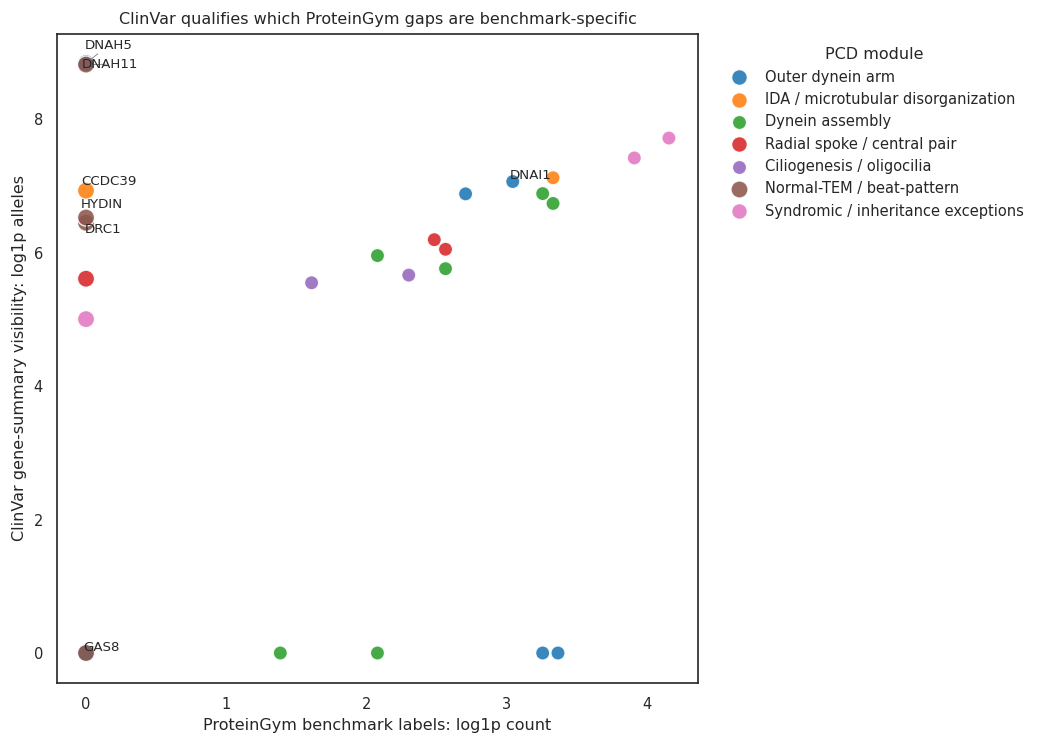
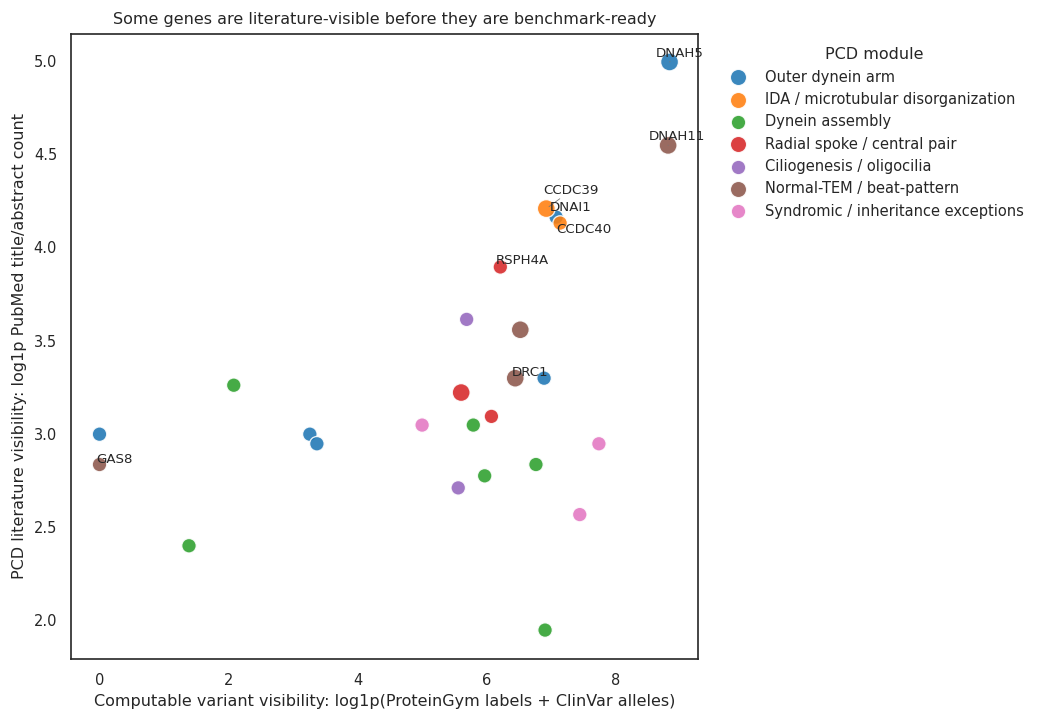
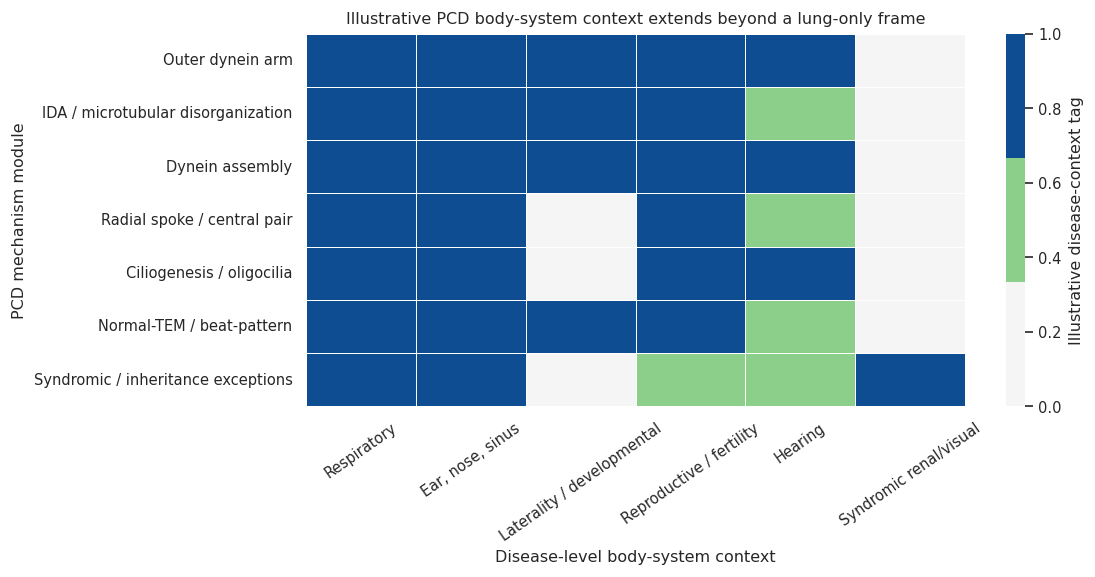
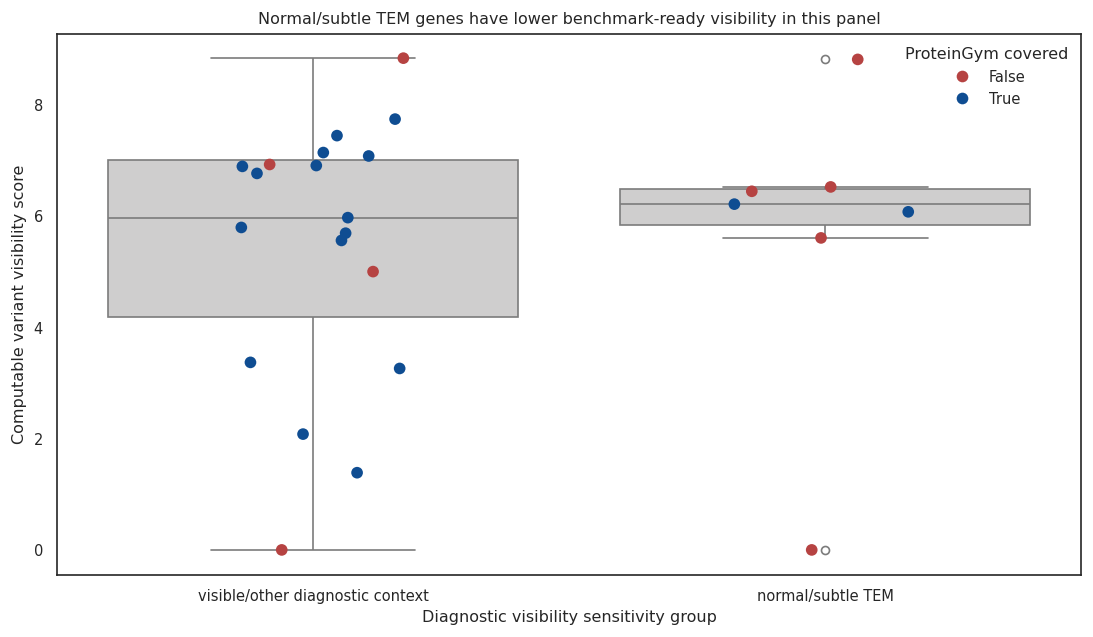

In [ ]:

atlas_clinvar_plot_table = atlas_final_atlas_table.copy()
fig_atlas_clinvar, ax_atlas_clinvar = plt.subplots(figsize=(8.8, 6.3))
for atlas_clinvar_module_name, atlas_clinvar_module_group in atlas_clinvar_plot_table.groupby("pcd_module", observed=True):
    ax_atlas_clinvar.scatter(
        atlas_clinvar_module_group["clinical_variant_count"].map(np.log1p),
        atlas_clinvar_module_group["clinvar_visibility_score"],
        s=np.where(atlas_clinvar_module_group["proteingym_covered"], 72, 105),
        color=module_palette[atlas_clinvar_module_name],
        edgecolor="white",
        linewidth=0.8,
        alpha=0.88,
        label=atlas_clinvar_module_name,
    )
ax_atlas_clinvar.set_xlabel("ProteinGym benchmark labels: log1p count")
ax_atlas_clinvar.set_ylabel("ClinVar gene-summary visibility: log1p alleles")
ax_atlas_clinvar.set_title("ClinVar qualifies which ProteinGym gaps are benchmark-specific")
atlas_clinvar_label_genes = {"DNAH5", "DNAH11", "DRC1", "GAS8", "CCDC39", "HYDIN", "DNAI1"}
atlas_clinvar_texts = []
for atlas_clinvar_label_record in atlas_clinvar_plot_table[atlas_clinvar_plot_table["gene_symbol"].isin(atlas_clinvar_label_genes)].to_dict("records"):
    atlas_clinvar_texts.append(
        ax_atlas_clinvar.text(
            np.log1p(atlas_clinvar_label_record["clinical_variant_count"]),
            atlas_clinvar_label_record["clinvar_visibility_score"],
            atlas_clinvar_label_record["gene_symbol"],
            fontsize=8,
        )
    )
adjust_text(atlas_clinvar_texts, ax=ax_atlas_clinvar, arrowprops={"arrowstyle": "-", "color": PALETTE["neutral_mid"], "lw": 0.5})
ax_atlas_clinvar.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, title="PCD module")
fig_atlas_clinvar.tight_layout()
save_figure(fig_atlas_clinvar, "pcd_clinvar_vs_proteingym_visibility")

atlas_literature_plot_table = atlas_final_atlas_table.copy()
fig_atlas_literature, ax_atlas_literature = plt.subplots(figsize=(8.8, 6.1))
for atlas_literature_module_name, atlas_literature_module_group in atlas_literature_plot_table.groupby("pcd_module", observed=True):
    ax_atlas_literature.scatter(
        atlas_literature_module_group["computable_variant_visibility_score"],
        atlas_literature_module_group["literature_visibility_score"],
        s=np.where(atlas_literature_module_group["known_but_not_benchmark_ready"], 115, 76),
        color=module_palette[atlas_literature_module_name],
        edgecolor="white",
        linewidth=0.8,
        alpha=0.88,
        label=atlas_literature_module_name,
    )
ax_atlas_literature.set_xlabel("Computable variant visibility: log1p(ProteinGym labels + ClinVar alleles)")
ax_atlas_literature.set_ylabel("PCD literature visibility: log1p PubMed title/abstract count")
ax_atlas_literature.set_title("Some genes are literature-visible before they are benchmark-ready")
atlas_literature_label_genes = set(atlas_literature_plot_table.sort_values("pubmed_pcd_count", ascending=False).head(6)["gene_symbol"]).union({"DNAH11", "DRC1", "GAS8"})
atlas_literature_texts = []
for atlas_literature_label_record in atlas_literature_plot_table[atlas_literature_plot_table["gene_symbol"].isin(atlas_literature_label_genes)].to_dict("records"):
    atlas_literature_texts.append(
        ax_atlas_literature.text(
            atlas_literature_label_record["computable_variant_visibility_score"],
            atlas_literature_label_record["literature_visibility_score"],
            atlas_literature_label_record["gene_symbol"],
            fontsize=8,
        )
    )
adjust_text(atlas_literature_texts, ax=ax_atlas_literature, arrowprops={"arrowstyle": "-", "color": PALETTE["neutral_mid"], "lw": 0.5})
ax_atlas_literature.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, title="PCD module")
fig_atlas_literature.tight_layout()
save_figure(fig_atlas_literature, "pcd_literature_vs_computable_variant_visibility")

fig_atlas_phenotype, ax_atlas_phenotype = plt.subplots(figsize=(9.6, 4.9))
sns.heatmap(
    atlas_module_body_system_map[atlas_phenotype_system_columns],
    cmap=sns.color_palette(["#F5F5F5", PALETTE["green"], PALETTE["blue_main"]], as_cmap=True),
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Illustrative disease-context tag"},
    ax=ax_atlas_phenotype,
)
ax_atlas_phenotype.set_title("Illustrative PCD body-system context extends beyond a lung-only frame")
ax_atlas_phenotype.set_xlabel("Disease-level body-system context")
ax_atlas_phenotype.set_ylabel("PCD mechanism module")
ax_atlas_phenotype.tick_params(axis="x", labelrotation=35)
fig_atlas_phenotype.tight_layout()
save_figure(fig_atlas_phenotype, "pcd_body_system_context_map")

fig_atlas_comparator, ax_atlas_comparator = plt.subplots(figsize=(9.2, 5.4))
atlas_comparator_plot = atlas_final_atlas_table.assign(
    atlas_comparator_class=np.where(atlas_final_atlas_table["normal_or_subtle_tem"], "normal/subtle TEM", "visible/other diagnostic context")
)
sns.boxplot(data=atlas_comparator_plot, x="atlas_comparator_class", y="computable_variant_visibility_score", color=PALETTE["neutral_light"], ax=ax_atlas_comparator)
sns.stripplot(
    data=atlas_comparator_plot,
    x="atlas_comparator_class",
    y="computable_variant_visibility_score",
    hue="proteingym_covered",
    palette={True: PALETTE["blue_main"], False: PALETTE["red"]},
    size=7,
    jitter=0.18,
    ax=ax_atlas_comparator,
)
ax_atlas_comparator.set_xlabel("Diagnostic visibility sensitivity group")
ax_atlas_comparator.set_ylabel("Computable variant visibility score")
ax_atlas_comparator.set_title("Normal/subtle TEM genes have lower benchmark-ready visibility in this panel")
ax_atlas_comparator.legend(title="ProteinGym covered", loc="upper right", frameon=False)
fig_atlas_comparator.tight_layout()
save_figure(fig_atlas_comparator, "pcd_diagnostic_sensitivity_variant_visibility")

mo.vstack(
    [
        mo.md("## External Evidence Figures"),
        fig_atlas_clinvar,
        mo.md("**ClinVar interpretation:** high-y / low-x genes are visible in ClinVar gene-summary aggregates but missing from the checked ProteinGym benchmark labels."),
        fig_atlas_literature,
        mo.md("**Literature interpretation:** PubMed counts separate search visibility from computable benchmark/catalog visibility."),
        fig_atlas_phenotype,
        mo.md("**Phenotype interpretation:** this schematic disease-level body-system context explains why lung-only framing is incomplete; it is not a gene-specific symptom model."),
        fig_atlas_comparator,
        mo.md("**Comparator interpretation:** small-n descriptive summaries are used instead of p-values; normal/subtle TEM remains a lower benchmark-ready visibility group."),
    ]
)

In [ ]:

atlas_final_resolved_total = len(atlas_final_atlas_table[atlas_final_atlas_table["gtex_resolved"]])
atlas_final_panel_total = len(atlas_final_atlas_table)
atlas_final_repro_max_dominant = int((atlas_final_atlas_table["reproductive_max"] > atlas_final_atlas_table["respiratory"]).sum())
atlas_final_pg_covered = int(atlas_final_atlas_table["proteingym_covered"].sum())
atlas_final_clinvar_visible = int(atlas_final_atlas_table["clinvar_visible"].sum())
atlas_final_pubmed_visible = int((atlas_final_atlas_table["pubmed_pcd_count_for_score"] > 0).sum())
atlas_final_opentargets_found = int(atlas_final_atlas_table["opentargets_found"].sum())
atlas_final_normal_tem = atlas_final_atlas_table[atlas_final_atlas_table["diagnostic_visibility"].eq("Normal TEM / beat-pattern")]
atlas_final_known_not_benchmark = atlas_final_atlas_table[atlas_final_atlas_table["known_but_not_benchmark_ready"]]["gene_symbol"].tolist()
atlas_final_top_gap_genes = atlas_final_atlas_table.sort_values("public_data_gap_score", ascending=False).head(5)["gene_symbol"].tolist()

mo.vstack(
    [
        mo.md(
            f"""
## Final Public-Data Atlas Findings

1. **What we found:** In **bulk GTEx normal-tissue expression**, the selected PCD panel is not a lung-only story. **Evidence:** {atlas_final_repro_max_dominant}/{atlas_final_resolved_total} GTEx-resolved genes have at least one selected reproductive tissue above lung. **Why it matters:** public tissue-expression data makes the multi-system biology visible to a reader. **Caveat:** this does not predict fertility symptoms, organ involvement, or disease severity.

2. **What we found:** ProteinGym benchmark-label visibility is uneven across mechanisms and diagnostic contexts. **Evidence:** strict RefSeq matching covers **{atlas_final_pg_covered}/{atlas_final_panel_total}** selected genes and **{int(atlas_final_normal_tem['proteingym_covered'].sum())}/{len(atlas_final_normal_tem)}** normal-TEM / beat-pattern genes. **Why it matters:** benchmark-ready variant resources can undersample genes that are biologically and diagnostically important. **Caveat:** absence from the checked ProteinGym file is not absence from biology or clinical relevance.

3. **What we found:** ClinVar and PubMed qualify the benchmark-gap story. **Evidence:** ClinVar has gene-level visibility for **{atlas_final_clinvar_visible}/{atlas_final_panel_total}** selected genes, and PubMed PCD title/abstract queries return at least one visible hit for **{atlas_final_pubmed_visible}/{atlas_final_panel_total}** genes after separating failed fetches from true zero counts. **Why it matters:** some genes are catalog- or literature-visible even when they are not represented in the checked ProteinGym benchmark layer. **Caveat:** these are catalog/search visibility signals, not prevalence, evidence quality, or clinical interpretation.

4. **What we found:** broader evidence platforms expose different parts of the public-data landscape. **Evidence:** Open Targets returned PCD association scores for **{atlas_final_opentargets_found}/{atlas_final_panel_total}** selected genes using `MONDO_0016575`; ProteinGym DMS metadata returned no selected PCD gene assays in the lightweight metadata check. **Why it matters:** clinical labels, DMS assays, literature, and database associations should not be collapsed into one kind of evidence. **Caveat:** Open Targets scores are platform aggregations, and DMS absence is assay-resource absence, not biological absence.

5. **Final atlas curation leads:** `{', '.join(atlas_final_top_gap_genes)}` remain high-priority public-data gap examples in this run. Known-but-not-benchmark-ready examples include `{', '.join(atlas_final_known_not_benchmark) if atlas_final_known_not_benchmark else 'none under the current threshold'}`.
"""
        ),
        mo.md("## Source Metadata"),
        mo.ui.table(atlas_source_metadata, pagination=False),
        mo.md("## Context Tables"),
        mo.ui.table(atlas_phenotype_body_systems, pagination=False),
        mo.ui.table(atlas_prognosis_context, pagination=False),
        mo.ui.table(atlas_delivery_context, pagination=False),
        mo.ui.table(atlas_hpa_validation_context, pagination=False),
        mo.md("## Review Gates"),
        mo.ui.table(atlas_review_gate_table, pagination=False),
        mo.ui.table(atlas_comparator_diagnostic_summary, pagination=False),
    ]
)

Final Public-Data Atlas Findings 
 
 What we found: In bulk GTEx normal-tissue expression , the selected PCD panel is not a lung-only story. Evidence: 24/26 GTEx-resolved genes have at least one selected reproductive tissue above lung. Why it matters: public tissue-expression data makes the multi-system biology visible to a reader. Caveat: this does not predict fertility symptoms, organ involvement, or disease severity. 
 What we found: ProteinGym benchmark-label visibility is uneven across mechanisms and diagnostic contexts. Evidence: strict RefSeq matching covers 17/26 selected genes and 0/4 normal-TEM / beat-pattern genes. Why it matters: benchmark-ready variant resources can undersample genes that are biologically and diagnostically important. Caveat: absence from the checked ProteinGym file is not absence from biology or clinical relevance. 
 What we found: ClinVar and PubMed qualify the benchmark-gap story. Evidence: ClinVar has gene-level visibility for 20/26 selected genes, and PubMed PCD title/abstract queries return at least one visible hit for 26/26 genes after separating failed fetches from true zero counts. Why it matters: some genes are catalog- or literature-visible even when they are not represented in the checked ProteinGym benchmark layer. Caveat: these are catalog/search visibility signals, not prevalence, evidence quality, or clinical interpretation. 
 What we found: broader evidence platforms expose different parts of the public-data landscape. Evidence: Open Targets returned PCD association scores for 20/26 selected genes using MONDO_0016575 ; ProteinGym DMS metadata returned no selected PCD gene assays in the lightweight metadata check. Why it matters: clinical labels, DMS assays, literature, and database associations should not be collapsed into one kind of evidence. Caveat: Open Targets scores are platform aggregations, and DMS absence is assay-resource absence, not biological absence. 
 Final atlas curation leads: GAS8, RSPH9, FOXJ1, CCDC39, DRC1 remain high-priority public-data gap examples in this run. Known-but-not-benchmark-ready examples include DNAH5, CCDC39, RSPH9, DNAH11, DRC1, HYDIN . 
 Source Metadata <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"_marimo_row_id\":0,\"layer\":\"GTEx v8\",\"source\":\"https://gtexportal.org/api/v2\",\"cache\":\"pcd_gtex_expression_v8_alias_resolved.csv\",\"access_date\":\"cache or live run\",\"limitation\":\"bulk normal tissue; not ciliated-airway cell specificity\"},{\"_marimo_row_id\":1,\"layer\":\"ProteinGym clinical substitutions\",\"source\":\"OATML-Markslab/ProteinGym_v1 Hugging Face parquet\",\"cache\":\"proteingym_clinical_substitutions_pcd_counts.csv\",\"access_date\":\"cache or live run\",\"limitation\":\"benchmark labels; strict RefSeq matching; conservative single-candidate gene counts\"},{\"_marimo_row_id\":2,\"layer\":\"ClinVar gene summary\",\"source\":\"https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/gene_specific_summary.txt\",\"cache\":\"pcd_clinvar_gene_specific_summary.csv\",\"access_date\":\"2026-05-14\",\"limitation\":\"gene-level public submission aggregate, not prevalence\"},{\"_marimo_row_id\":3,\"layer\":\"ProteinGym DMS metadata\",\"source\":\"https://raw.githubusercontent.com/OATML-Markslab/ProteinGym/main/reference_files/DMS_substitutions.csv\",\"cache\":\"proteingym_dms_substitutions_metadata_pcd_check.csv\",\"access_date\":\"2026-05-14\",\"limitation\":\"metadata assay coverage only; no assay matrices downloaded\"},{\"_marimo_row_id\":4,\"layer\":\"PubMed ESearch\",\"source\":\"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi\",\"cache\":\"pcd_pubmed_visibility_counts.csv\",\"access_date\":\"2026-05-14\",\"limitation\":\"title/abstract query counts; failed fetches stay distinct from scored zero counts\"},{\"_marimo_row_id\":5,\"layer\":\"ClinicalTrials.gov\",\"source\":\"https://clinicaltrials.gov/api/v2/studies\",\"cache\":\"pcd_clinicaltrials_delivery_context.csv\",\"access_date\":\"20

PCD vs Broader Ciliary Universe 
 This pilot comparator tests whether the GTEx reproductive axis is a PCD-panel feature or a broader ciliary-gene visibility pattern. Comparator genes are deliberately small and source-cited so the control remains interpretable. <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"_marimo_row_id\":0,\"gene_symbol\":\"DNAAF2\",\"gtex_query_symbol\":\"DNAAF2\",\"comparator_class\":\"expanded_motile_cilia\",\"source\":\"Curated motile-cilia comparator\",\"source_url\":\"https://www.ncbi.nlm.nih.gov/books/NBK1122/\",\"source_note\":\"Dynein assembly / motile-cilia biology comparator; not part of the core selected PCD panel here.\"},{\"_marimo_row_id\":1,\"gene_symbol\":\"DNAAF3\",\"gtex_query_symbol\":\"DNAAF3\",\"comparator_class\":\"expanded_motile_cilia\",\"source\":\"Curated motile-cilia comparator\",\"source_url\":\"https://www.ncbi.nlm.nih.gov/books/NBK1122/\",\"source_note\":\"Dynein assembly / motile-cilia biology comparator.\"},{\"_marimo_row_id\":2,\"gene_symbol\":\"CCDC151\",\"gtex_query_symbol\":\"CCDC151\",\"comparator_class\":\"expanded_motile_cilia\",\"source\":\"Curated motile-cilia comparator\",\"source_url\":\"https://www.ncbi.nlm.nih.gov/books/NBK1122/\",\"source_note\":\"Outer dynein arm docking / motile-cilia comparator.\"},{\"_marimo_row_id\":3,\"gene_symbol\":\"TTC25\",\"gtex_query_symbol\":\"TTC25\",\"comparator_class\":\"expanded_motile_cilia\",\"source\":\"Curated motile-cilia comparator\",\"source_url\":\"https://www.ncbi.nlm.nih.gov/books/NBK1122/\",\"source_note\":\"Ciliary motility comparator.\"},{\"_marimo_row_id\":4,\"gene_symbol\":\"SPEF2\",\"gtex_query_symbol\":\"SPEF2\",\"comparator_class\":\"expanded_motile_cilia\",\"source\":\"Curated motile-cilia comparator\",\"source_url\":\"https://www.ncbi.nlm.nih.gov/books/NBK1122/\",\"source_note\":\"Sperm flagellar / motile-cilia comparator.\"},{\"_marimo_row_id\":5,\"gene_symbol\":\"CFAP43\",\"gtex_query_symbol\":\"CFAP43\",\"comparator_class\":\"expanded_motile_cilia\",\"source\":\"Curated motile-cilia comparator\",\"source_url\":\"https://www.ncbi.nlm.nih.gov/books/NBK1122/\",\"source_note\":\"Cilia- and flagella-associated comparator.\"},{\"_marimo_row_id\":6,\"gene_symbol\":\"CFAP44\",\"gtex_query_symbol\":\"CFAP44\",\"comparator_class\":\"expanded_motile_cilia\",\"source\":\"Curated motile-cilia comparator\",\"source_url\":\"https://www.ncbi.nlm.nih.gov/books/NBK1122/\",\"source_note\":\"Cilia- and flagella-associated comparator.\"},{\"_marimo_row_id\":7,\"gene_symbol\":\"CFAP57\",\"gtex_query_symbol\":\"CFAP57\",\"comparator_class\":\"expanded_motile_cilia\",\"source\":\"Curated motile-cilia comparator\",\"source_url\":\"https://www.ncbi.nlm.nih.gov/books/NBK1122/\",\"source_note\":\"Cilia- and flagella-associated comparator.\"}]"' data-total-rows='18' data-total-columns='6' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='8' data-field-types='[["gene_symbol",["string","str"]],["gtex_query_symbol",["string","str"]],["comparator_class",["string","str"]],["source",["string","str"]],["source_url",["string","str"]],["source_note",["string","str"]]]' data-selection='"multi"' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='true' data-lazy='false' data-preload='false'> How to read this: gray points are broader ciliary comparator genes; colored points are the curated PCD panel. The diagonal marks equal lung and selected reproductive-tissue GTEx scores. This is a bulk-expression visibility comparison, not a symptom or fertility claim. <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"_marimo_row_id\":0,\"gene_set\":\"canonical_pcd_panel\",\"genes\":26,\"fraction_reproductive_above_lung\":0.923,\"median_reproductive_minus_lung\":1.731,\"fraction
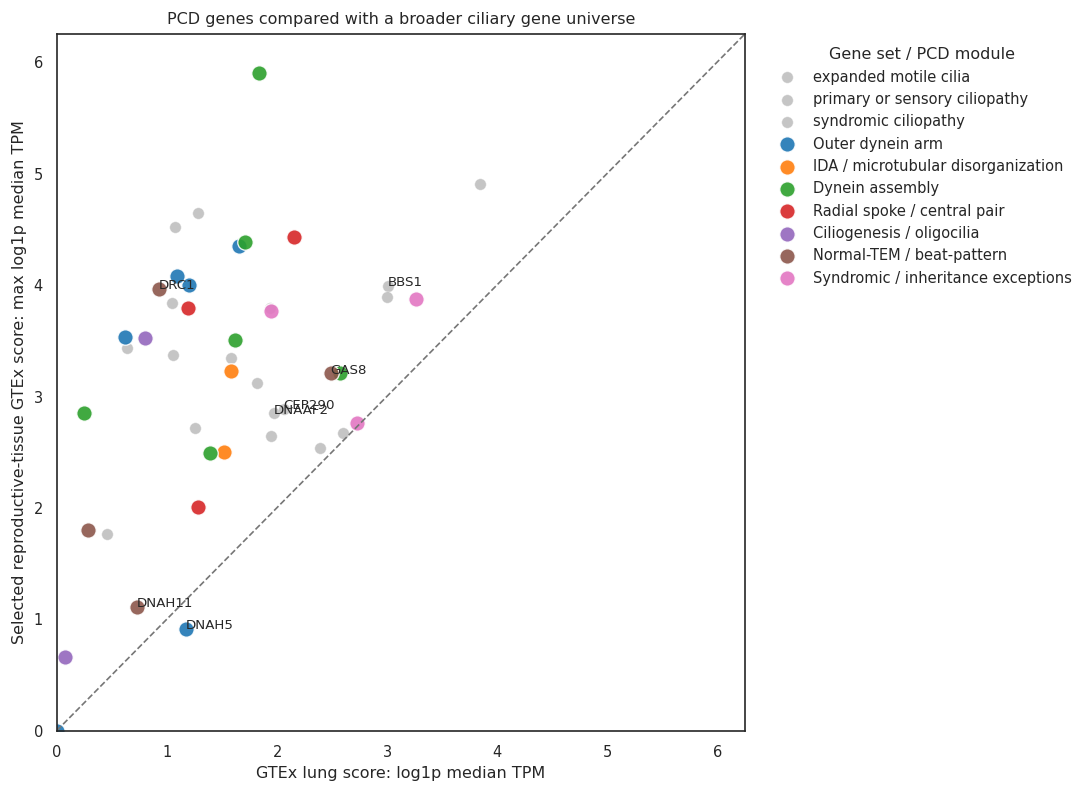

In [ ]:

wow_comparator_records = [
    {"gene_symbol": "DNAAF2", "gtex_query_symbol": "DNAAF2", "comparator_class": "expanded_motile_cilia", "source": "Curated motile-cilia comparator", "source_url": "https://www.ncbi.nlm.nih.gov/books/NBK1122/", "source_note": "Dynein assembly / motile-cilia biology comparator; not part of the core selected PCD panel here."},
    {"gene_symbol": "DNAAF3", "gtex_query_symbol": "DNAAF3", "comparator_class": "expanded_motile_cilia", "source": "Curated motile-cilia comparator", "source_url": "https://www.ncbi.nlm.nih.gov/books/NBK1122/", "source_note": "Dynein assembly / motile-cilia biology comparator."},
    {"gene_symbol": "CCDC151", "gtex_query_symbol": "CCDC151", "comparator_class": "expanded_motile_cilia", "source": "Curated motile-cilia comparator", "source_url": "https://www.ncbi.nlm.nih.gov/books/NBK1122/", "source_note": "Outer dynein arm docking / motile-cilia comparator."},
    {"gene_symbol": "TTC25", "gtex_query_symbol": "TTC25", "comparator_class": "expanded_motile_cilia", "source": "Curated motile-cilia comparator", "source_url": "https://www.ncbi.nlm.nih.gov/books/NBK1122/", "source_note": "Ciliary motility comparator."},
    {"gene_symbol": "SPEF2", "gtex_query_symbol": "SPEF2", "comparator_class": "expanded_motile_cilia", "source": "Curated motile-cilia comparator", "source_url": "https://www.ncbi.nlm.nih.gov/books/NBK1122/", "source_note": "Sperm flagellar / motile-cilia comparator."},
    {"gene_symbol": "CFAP43", "gtex_query_symbol": "CFAP43", "comparator_class": "expanded_motile_cilia", "source": "Curated motile-cilia comparator", "source_url": "https://www.ncbi.nlm.nih.gov/books/NBK1122/", "source_note": "Cilia- and flagella-associated comparator."},
    {"gene_symbol": "CFAP44", "gtex_query_symbol": "CFAP44", "comparator_class": "expanded_motile_cilia", "source": "Curated motile-cilia comparator", "source_url": "https://www.ncbi.nlm.nih.gov/books/NBK1122/", "source_note": "Cilia- and flagella-associated comparator."},
    {"gene_symbol": "CFAP57", "gtex_query_symbol": "CFAP57", "comparator_class": "expanded_motile_cilia", "source": "Curated motile-cilia comparator", "source_url": "https://www.ncbi.nlm.nih.gov/books/NBK1122/", "source_note": "Cilia- and flagella-associated comparator."},
    {"gene_symbol": "DNAH9", "gtex_query_symbol": "DNAH9", "comparator_class": "expanded_motile_cilia", "source": "Curated motile-cilia comparator", "source_url": "https://www.ncbi.nlm.nih.gov/books/NBK1122/", "source_note": "Axonemal dynein comparator."},
    {"gene_symbol": "CEP290", "gtex_query_symbol": "CEP290", "comparator_class": "primary_or_sensory_ciliopathy", "source": "Curated ciliopathy comparator", "source_url": "https://www.orpha.net/en/disease/detail/244", "source_note": "Broader primary/sensory ciliopathy comparator, not motile-PCD specific."},
    {"gene_symbol": "BBS1", "gtex_query_symbol": "BBS1", "comparator_class": "primary_or_sensory_ciliopathy", "source": "Curated ciliopathy comparator", "source_url": "https://www.orpha.net/en/disease/detail/244", "source_note": "Bardet-Biedl / primary-cilium comparator."},
    {"gene_symbol": "BBS10", "gtex_query_symbol": "BBS10", "comparator_class": "primary_or_sensory_ciliopathy", "source": "Curated ciliopathy comparator", "source_url": "https://www.orpha.net/en/disease/detail/244", "source_note": "Bardet-Biedl / primary-cilium comparator."},
    {"gene_symbol": "IFT88", "gtex_query_symbol": "IFT88", "comparator_class": "primary_or_sensory_ciliopathy", "source": "Curated ciliopathy comparator", "source_url": "https://www.orpha.net/en/disease/detail/244", "source_note": "Intraflagellar transport comparator."},
    {"gene_symbol": "IFT140", "gtex_query_symbol": "IFT140", "comparator_class": "primary_or_sensory_ciliopathy", "source": "Curated ciliopathy comparator", "source_url": "https://www.orpha.net/en/disease/detail/244", "source_note": "Intraflagellar transport comparator."},
    {"gene_symbol": "KIF3A", "gtex_query_symbol": "KIF3A", "comparator_class": "primary_or_sensory_ciliopathy", "source": "Curated ciliopathy comparator", "source_url": "https://www.orpha.net/en/disease/detail/244", "source_note": "Kinesin/cilium assembly comparator."},
    {"gene_symbol": "ARL13B", "gtex_query_symbol": "ARL13B", "comparator_class": "primary_or_sensory_ciliopathy", "source": "Curated ciliopathy comparator", "source_url": "https://www.orpha.net/en/disease/detail/244", "source_note": "Primary-cilium signaling comparator."},
    {"gene_symbol": "NPHP1", "gtex_query_symbol": "NPHP1", "comparator_class": "syndromic_ciliopathy", "source": "Curated syndromic ciliopathy comparator", "source_url": "https://www.orpha.net/en/disease/detail/244", "source_note": "Renal/syndromic ciliopathy comparator."},
    {"gene_symbol": "PKD2", "gtex_query_symbol": "PKD2", "comparator_class": "syndromic_ciliopathy", "source": "Curated syndromic ciliopathy comparator", "source_url": "https://www.orpha.net/en/disease/detail/244", "source_note": "Renal/syndromic ciliopathy comparator."},
]

wow_comparator_panel = pd.DataFrame(wow_comparator_records)
wow_comparator_panel = wow_comparator_panel[~wow_comparator_panel["gene_symbol"].isin(pcd_genes["gene_symbol"])]
wow_comparator_cache = PROCESSED_DIR / "pcd_wow_ciliary_comparator_gtex_expression.csv"
wow_comparator_unresolved_cache = PROCESSED_DIR / "pcd_wow_ciliary_comparator_unresolved.csv"
wow_gtex_api = "https://gtexportal.org/api/v2"


def wow_resolve_gtex_gene_id(wow_query_symbol: str) -> str | None:
    wow_response = requests.get(
        f"{wow_gtex_api}/reference/gene",
        params={"geneId": wow_query_symbol},
        timeout=30,
    )
    wow_response.raise_for_status()
    wow_records = wow_response.json().get("data", [])
    if not wow_records:
        return None
    wow_exact_records = [wow_record for wow_record in wow_records if wow_record.get("geneSymbol") == wow_query_symbol]
    return (wow_exact_records or wow_records)[0].get("gencodeId")


def wow_fetch_gtex_for_gene(wow_gene_symbol: str, wow_query_symbol: str) -> list[dict[str, object]]:
    wow_gencode_id = wow_resolve_gtex_gene_id(wow_query_symbol)
    if wow_gencode_id is None:
        return []
    wow_expression_response = requests.get(
        f"{wow_gtex_api}/expression/medianGeneExpression",
        params={"datasetId": "gtex_v8", "gencodeId": wow_gencode_id, "itemsPerPage": 250},
        timeout=30,
    )
    wow_expression_response.raise_for_status()
    return [
        {
            "gene_symbol": wow_gene_symbol,
            "gtex_query_symbol": wow_query_symbol,
            "gencode_id": wow_gencode_id,
            "gtex_returned_symbol": wow_record.get("geneSymbol"),
            "tissue": wow_record["tissueSiteDetailId"],
            "median_tpm": float(wow_record["median"]),
            "unit": wow_record.get("unit", "TPM"),
        }
        for wow_record in wow_expression_response.json().get("data", [])
    ]

if wow_comparator_cache.exists():
    wow_comparator_gtex_expression = pd.read_csv(wow_comparator_cache)
    try:
        wow_comparator_unresolved = pd.read_csv(wow_comparator_unresolved_cache)
    except (FileNotFoundError, pd.errors.EmptyDataError):
        wow_comparator_unresolved = pd.DataFrame(columns=["gene_symbol", "gtex_query_symbol"])
else:
    wow_comparator_rows = []
    wow_unresolved_rows = []
    for wow_comparator_record in wow_comparator_panel[["gene_symbol", "gtex_query_symbol"]].to_dict("records"):
        try:
            wow_rows_for_gene = wow_fetch_gtex_for_gene(
                wow_comparator_record["gene_symbol"],
                wow_comparator_record["gtex_query_symbol"],
            )
        except Exception:
            wow_rows_for_gene = []
        if wow_rows_for_gene:
            wow_comparator_rows.extend(wow_rows_for_gene)
        else:
            wow_unresolved_rows.append(wow_comparator_record)
    wow_comparator_gtex_expression = pd.DataFrame(wow_comparator_rows)
    wow_comparator_unresolved = pd.DataFrame(wow_unresolved_rows)
    wow_comparator_gtex_expression.to_csv(wow_comparator_cache, index=False)
    wow_comparator_unresolved.to_csv(wow_comparator_unresolved_cache, index=False)

wow_comparator_gtex_expression["log1p_tpm"] = np.log1p(wow_comparator_gtex_expression["median_tpm"])

wow_male_reproductive_tissues = ["Testis", "Prostate"]
wow_female_reproductive_tissues = ["Fallopian_Tube", "Ovary", "Uterus", "Cervix_Ectocervix", "Cervix_Endocervix", "Vagina"]
wow_reproductive_tissues = wow_male_reproductive_tissues + wow_female_reproductive_tissues
wow_respiratory_tissues = ["Lung"]
wow_context_tissues = ["Pituitary", "Thyroid", "Adrenal_Gland", "Kidney_Cortex", "Kidney_Medulla", "Brain_Cortex", "Brain_Cerebellum"]


def wow_domain_scores_from_expression(wow_expr_frame: pd.DataFrame) -> pd.DataFrame:
    wow_rows = []
    for wow_gene_symbol, wow_gene_group in wow_expr_frame.groupby("gene_symbol"):
        wow_rows.append(
            {
                "gene_symbol": wow_gene_symbol,
                "respiratory": wow_gene_group.loc[wow_gene_group["tissue"].isin(wow_respiratory_tissues), "log1p_tpm"].mean(),
                "reproductive": wow_gene_group.loc[wow_gene_group["tissue"].isin(wow_reproductive_tissues), "log1p_tpm"].mean(),
                "reproductive_max": wow_gene_group.loc[wow_gene_group["tissue"].isin(wow_reproductive_tissues), "log1p_tpm"].max(),
                "male_reproductive_max": wow_gene_group.loc[wow_gene_group["tissue"].isin(wow_male_reproductive_tissues), "log1p_tpm"].max(),
                "female_reproductive_max": wow_gene_group.loc[wow_gene_group["tissue"].isin(wow_female_reproductive_tissues), "log1p_tpm"].max(),
                "other_ciliary_context": wow_gene_group.loc[wow_gene_group["tissue"].isin(wow_context_tissues), "log1p_tpm"].mean(),
                "top_gtex_tissue": wow_gene_group.sort_values("log1p_tpm", ascending=False).iloc[0]["tissue"],
            }
        )
    return pd.DataFrame(wow_rows)

wow_comparator_domain_scores = wow_domain_scores_from_expression(wow_comparator_gtex_expression)
wow_comparator_domain_scores = wow_comparator_domain_scores.merge(
    wow_comparator_panel[["gene_symbol", "comparator_class", "source", "source_url", "source_note"]],
    on="gene_symbol",
    how="left",
)
wow_comparator_domain_scores["gene_set"] = wow_comparator_domain_scores["comparator_class"]
wow_comparator_domain_scores["is_pcd_panel"] = False

wow_pcd_domain_scores_for_comparison = analysis_table_extended[
    [
        "gene_symbol",
        "respiratory",
        "reproductive",
        "reproductive_max",
        "male_reproductive_max",
        "female_reproductive_max",
        "other ciliary context",
        "top_gtex_tissue",
        "pcd_module",
        "diagnostic_visibility",
    ]
].rename(columns={"other ciliary context": "other_ciliary_context"})
wow_pcd_domain_scores_for_comparison["gene_set"] = "canonical_pcd_panel"
wow_pcd_domain_scores_for_comparison["comparator_class"] = "canonical_pcd_panel"
wow_pcd_domain_scores_for_comparison["source"] = "Current curated PCD panel"
wow_pcd_domain_scores_for_comparison["source_url"] = "https://www.ncbi.nlm.nih.gov/books/NBK1122/"
wow_pcd_domain_scores_for_comparison["source_note"] = "Selected PCD panel used throughout this notebook."
wow_pcd_domain_scores_for_comparison["is_pcd_panel"] = True

wow_ciliary_comparison_table = pd.concat(
    [wow_pcd_domain_scores_for_comparison, wow_comparator_domain_scores],
    ignore_index=True,
    sort=False,
)
wow_ciliary_comparison_table["reproductive_minus_respiratory"] = (
    wow_ciliary_comparison_table["reproductive_max"] - wow_ciliary_comparison_table["respiratory"]
)
wow_ciliary_comparison_table["male_minus_respiratory"] = (
    wow_ciliary_comparison_table["male_reproductive_max"] - wow_ciliary_comparison_table["respiratory"]
)
wow_ciliary_comparison_table["female_minus_respiratory"] = (
    wow_ciliary_comparison_table["female_reproductive_max"] - wow_ciliary_comparison_table["respiratory"]
)
wow_ciliary_comparison_table["reproductive_above_lung"] = (
    wow_ciliary_comparison_table["reproductive_max"] > wow_ciliary_comparison_table["respiratory"]
)
wow_ciliary_comparison_table["female_reproductive_above_lung"] = (
    wow_ciliary_comparison_table["female_reproductive_max"] > wow_ciliary_comparison_table["respiratory"]
)

wow_ciliary_summary = (
    wow_ciliary_comparison_table.groupby("gene_set")
    .agg(
        genes=("gene_symbol", "count"),
        fraction_reproductive_above_lung=("reproductive_above_lung", "mean"),
        median_reproductive_minus_lung=("reproductive_minus_respiratory", "median"),
        fraction_female_reproductive_above_lung=("female_reproductive_above_lung", "mean"),
        median_female_minus_lung=("female_minus_respiratory", "median"),
    )
    .round(3)
    .reset_index()
)

fig_wow_ciliary_axis, ax_wow_ciliary_axis = plt.subplots(figsize=(9.2, 6.7))
wow_background = wow_ciliary_comparison_table[~wow_ciliary_comparison_table["is_pcd_panel"]]
for wow_gene_set_name, wow_gene_set_group in wow_background.groupby("gene_set"):
    ax_wow_ciliary_axis.scatter(
        wow_gene_set_group["respiratory"],
        wow_gene_set_group["reproductive_max"],
        s=48,
        alpha=0.42,
        label=wow_gene_set_name.replace("_", " "),
        color=PALETTE["neutral_mid"],
        edgecolor="white",
        linewidth=0.5,
    )
wow_pcd_points = wow_ciliary_comparison_table[wow_ciliary_comparison_table["is_pcd_panel"]]
for wow_module_name, wow_module_group in wow_pcd_points.groupby("pcd_module", observed=True):
    ax_wow_ciliary_axis.scatter(
        wow_module_group["respiratory"],
        wow_module_group["reproductive_max"],
        s=86,
        alpha=0.9,
        label=str(wow_module_name),
        color=module_palette[wow_module_name],
        edgecolor="white",
        linewidth=0.8,
    )
wow_axis_limit = max(wow_ciliary_comparison_table["respiratory"].max(), wow_ciliary_comparison_table["reproductive_max"].max()) * 1.06
ax_wow_ciliary_axis.plot([0, wow_axis_limit], [0, wow_axis_limit], linestyle="--", color=PALETTE["neutral_mid"], linewidth=1)
ax_wow_ciliary_axis.set_xlim(0, wow_axis_limit)
ax_wow_ciliary_axis.set_ylim(0, wow_axis_limit)
ax_wow_ciliary_axis.set_xlabel("GTEx lung score: log1p median TPM")
ax_wow_ciliary_axis.set_ylabel("Selected reproductive-tissue GTEx score: max log1p median TPM")
ax_wow_ciliary_axis.set_title("PCD genes compared with a broader ciliary gene universe")
for wow_label_gene in ["DNAH11", "GAS8", "DRC1", "DNAH5", "DNAAF2", "CEP290", "BBS1"]:
    wow_label_rows = wow_ciliary_comparison_table[wow_ciliary_comparison_table["gene_symbol"].eq(wow_label_gene)]
    if not wow_label_rows.empty:
        wow_label_row = wow_label_rows.iloc[0]
        ax_wow_ciliary_axis.text(wow_label_row["respiratory"], wow_label_row["reproductive_max"], wow_label_gene, fontsize=8)
ax_wow_ciliary_axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, title="Gene set / PCD module")
fig_wow_ciliary_axis.tight_layout()
save_figure(fig_wow_ciliary_axis, "pcd_vs_ciliary_universe_axis")

wow_comparator_review_table = pd.DataFrame(
    [
        {"gate": "Data integrity", "assessment": f"Comparator GTEx resolved {wow_comparator_gtex_expression['gene_symbol'].nunique()}/{len(wow_comparator_panel)} comparator genes; unresolved: {', '.join(wow_comparator_unresolved['gene_symbol'].tolist()) if not wow_comparator_unresolved.empty else 'none'}."},
        {"gate": "Claim integrity", "assessment": "This tests whether the PCD axis is distinctive relative to a small curated ciliary comparator; it does not establish disease specificity for all cilia genes."},
        {"gate": "Keep / revise / demote", "assessment": "Keep as a pilot-control figure if source and coverage are clear; soften specificity claims if comparator classes show similar reproductive visibility."},
    ]
)

mo.vstack(
    [
        mo.md("## PCD vs Broader Ciliary Universe\n\nThis pilot comparator tests whether the GTEx reproductive axis is a PCD-panel feature or a broader ciliary-gene visibility pattern. Comparator genes are deliberately small and source-cited so the control remains interpretable."),
        mo.ui.table(wow_comparator_panel, pagination=True, page_size=8),
        fig_wow_ciliary_axis,
        mo.md("**How to read this:** gray points are broader ciliary comparator genes; colored points are the curated PCD panel. The diagonal marks equal lung and selected reproductive-tissue GTEx scores. This is a bulk-expression visibility comparison, not a symptom or fertility claim."),
        mo.ui.table(wow_ciliary_summary, pagination=False),
        mo.md("### Review Gate: Ciliary Comparator"),
        mo.ui.table(wow_comparator_review_table, pagination=False),
    ]
)

PCA and 2D Evidence Atlas 
 PCA is used as an interpretable 2D map of public-data geometry. It is not a clustering model and does not prove biological separability. Expression PCA: uses standardized GTEx log1p TPM across selected tissues. Colors show curated mechanism modules. Evidence atlas PCA: uses standardized tissue, ProteinGym, ClinVar, PubMed, Open Targets, diagnostic-subtlety, and DMS-coverage features. Point size tracks the existing public-data gap heuristic; black-edged points are absent from checked ProteinGym coverage. <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"_marimo_row_id\":0,\"feature\":\"respiratory\",\"evidence_pc1_loading\":0.51,\"evidence_pc2_loading\":0.151},{\"_marimo_row_id\":1,\"feature\":\"reproductive_max\",\"evidence_pc1_loading\":0.433,\"evidence_pc2_loading\":-0.011},{\"_marimo_row_id\":2,\"feature\":\"other ciliary context\",\"evidence_pc1_loading\":0.476,\"evidence_pc2_loading\":0.111},{\"_marimo_row_id\":3,\"feature\":\"clinical_variant_count\",\"evidence_pc1_loading\":0.447,\"evidence_pc2_loading\":-0.031},{\"_marimo_row_id\":4,\"feature\":\"clinvar_total_records\",\"evidence_pc1_loading\":0.021,\"evidence_pc2_loading\":0.647},{\"_marimo_row_id\":5,\"feature\":\"pubmed_pcd_count_for_score\",\"evidence_pc1_loading\":-0.298,\"evidence_pc2_loading\":0.358},{\"_marimo_row_id\":6,\"feature\":\"opentargets_pcd_score_for_pca\",\"evidence_pc1_loading\":0.02,\"evidence_pc2_loading\":0.627},{\"_marimo_row_id\":7,\"feature\":\"diagnostic_subtlety_score\",\"evidence_pc1_loading\":-0.193,\"evidence_pc2_loading\":0.156},{\"_marimo_row_id\":8,\"feature\":\"proteingym_dms_assay_count\",\"evidence_pc1_loading\":0.0,\"evidence_pc2_loading\":0.0}]"' data-total-rows='9' data-total-columns='3' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='9' data-field-types='[["feature",["string","str"]],["evidence_pc1_loading",["number","float64"]],["evidence_pc2_loading",["number","float64"]]]' data-selection='"multi"' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='true' data-lazy='false' data-preload='false'> Review Gate: PCA and Evidence Atlas <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"_marimo_row_id\":0,\"gate\":\"Explained variance\",\"assessment\":\"GTEx PCA PC1/PC2 explain 75.1% and 11.4%; evidence PCA PC1/PC2 explain 35.2% and 28.1%.\"},{\"_marimo_row_id\":1,\"gate\":\"Feature dominance\",\"assessment\":\"Largest evidence loading contributor: clinvar_total_records. PCA is interpreted as visualization, not clustering proof.\"},{\"_marimo_row_id\":2,\"gate\":\"Keep / revise / demote\",\"assessment\":\"Keep as a hero map if it clarifies the atlas; avoid hard cluster language and cite standardized features in the caption.\"}]"' data-total-rows='3' data-total-columns='2' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='3' data-field-types='[["gate",["string","str"]],["assessment",["string","str"]]]' data-selection='"multi"' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='true' data-lazy='false' data-preload='false'>
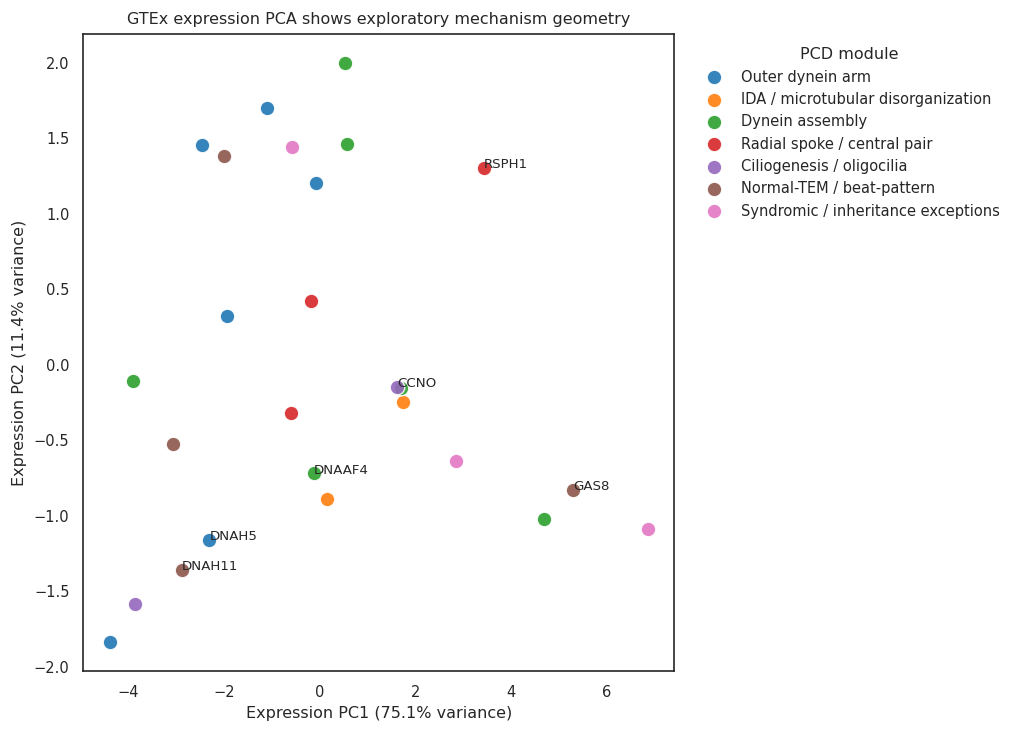
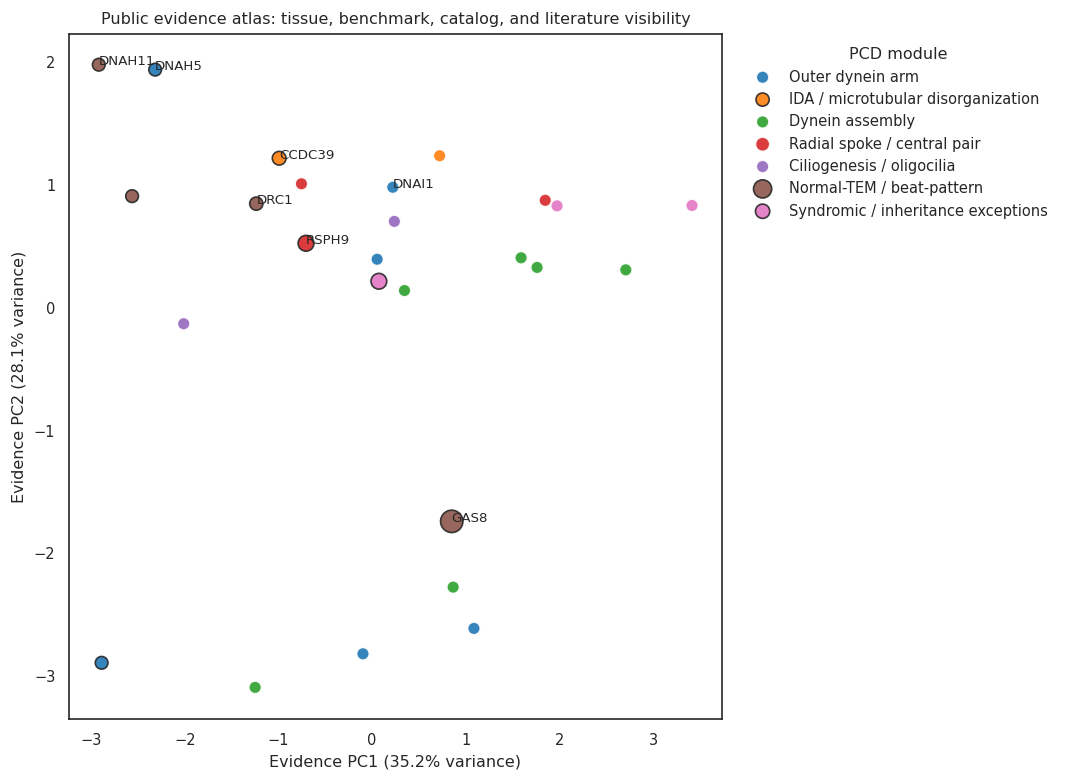

In [ ]:

wow_expression_tissues = [
    "Lung", "Testis", "Fallopian_Tube", "Ovary", "Uterus", "Prostate", "Pituitary", "Thyroid", "Kidney_Cortex", "Brain_Cortex", "Brain_Cerebellum"
]
wow_expression_matrix = (
    gtex_expression[gtex_expression["tissue"].isin(wow_expression_tissues)]
    .pivot_table(index="gene_symbol", columns="tissue", values="log1p_tpm", aggfunc="mean")
    .reindex(analysis_table_extended["gene_symbol"])
)
wow_expression_matrix = wow_expression_matrix.fillna(wow_expression_matrix.median(numeric_only=True))
wow_expression_scaled = StandardScaler().fit_transform(wow_expression_matrix)
wow_expression_pca_model = PCA(n_components=2, random_state=42)
wow_expression_pca_coords_array = wow_expression_pca_model.fit_transform(wow_expression_scaled)
wow_expression_pca_coords = pd.DataFrame(
    wow_expression_pca_coords_array,
    columns=["expression_pc1", "expression_pc2"],
    index=wow_expression_matrix.index,
).reset_index().rename(columns={"index": "gene_symbol"})
wow_expression_pca_coords = wow_expression_pca_coords.merge(
    analysis_table_extended[["gene_symbol", "pcd_module", "diagnostic_visibility", "proteingym_covered", "public_data_gap_score"]],
    on="gene_symbol",
    how="left",
)
wow_expression_pca_variance = wow_expression_pca_model.explained_variance_ratio_

fig_wow_expression_pca, ax_wow_expression_pca = plt.subplots(figsize=(8.6, 6.2))
for wow_expr_module_name, wow_expr_module_group in wow_expression_pca_coords.groupby("pcd_module", observed=True):
    ax_wow_expression_pca.scatter(
        wow_expr_module_group["expression_pc1"],
        wow_expr_module_group["expression_pc2"],
        s=76,
        color=module_palette[wow_expr_module_name],
        edgecolor="white",
        linewidth=0.8,
        alpha=0.9,
        label=str(wow_expr_module_name),
    )
for wow_expr_label_gene in ["DNAH11", "GAS8", "DNAH5", "DNAAF4", "RSPH1", "CCNO"]:
    wow_expr_label_row = wow_expression_pca_coords[wow_expression_pca_coords["gene_symbol"].eq(wow_expr_label_gene)]
    if not wow_expr_label_row.empty:
        wow_expr_record = wow_expr_label_row.iloc[0]
        ax_wow_expression_pca.text(wow_expr_record["expression_pc1"], wow_expr_record["expression_pc2"], wow_expr_label_gene, fontsize=8)
ax_wow_expression_pca.set_xlabel(f"Expression PC1 ({wow_expression_pca_variance[0] * 100:.1f}% variance)")
ax_wow_expression_pca.set_ylabel(f"Expression PC2 ({wow_expression_pca_variance[1] * 100:.1f}% variance)")
ax_wow_expression_pca.set_title("GTEx expression PCA shows exploratory mechanism geometry")
ax_wow_expression_pca.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, title="PCD module")
fig_wow_expression_pca.tight_layout()
save_figure(fig_wow_expression_pca, "pcd_expression_pca")

wow_evidence_feature_table = atlas_final_atlas_table.copy()
wow_evidence_feature_table["opentargets_pcd_score_for_pca"] = wow_evidence_feature_table["opentargets_pcd_score"].fillna(0)
wow_evidence_feature_cols = [
    "respiratory", "reproductive_max", "other ciliary context", "clinical_variant_count", "clinvar_total_records", "pubmed_pcd_count_for_score", "opentargets_pcd_score_for_pca", "diagnostic_subtlety_score", "proteingym_dms_assay_count"
]
wow_evidence_features = wow_evidence_feature_table[wow_evidence_feature_cols].copy()
for wow_evidence_col in wow_evidence_features.columns:
    wow_evidence_features[wow_evidence_col] = pd.to_numeric(wow_evidence_features[wow_evidence_col], errors="coerce").fillna(0)
wow_evidence_features[["clinical_variant_count", "clinvar_total_records", "pubmed_pcd_count_for_score", "proteingym_dms_assay_count"]] = np.log1p(
    wow_evidence_features[["clinical_variant_count", "clinvar_total_records", "pubmed_pcd_count_for_score", "proteingym_dms_assay_count"]]
)
wow_evidence_scaled = StandardScaler().fit_transform(wow_evidence_features)
wow_evidence_pca_model = PCA(n_components=2, random_state=42)
wow_evidence_pca_coords_array = wow_evidence_pca_model.fit_transform(wow_evidence_scaled)
wow_evidence_pca_coords = pd.DataFrame(
    wow_evidence_pca_coords_array,
    columns=["evidence_pc1", "evidence_pc2"],
)
wow_evidence_pca_coords["gene_symbol"] = wow_evidence_feature_table["gene_symbol"].values
wow_evidence_pca_coords = wow_evidence_pca_coords.merge(
    wow_evidence_feature_table[["gene_symbol", "pcd_module", "diagnostic_visibility", "proteingym_covered", "known_but_not_benchmark_ready", "public_data_gap_score"]],
    on="gene_symbol",
    how="left",
)
wow_evidence_pca_variance = wow_evidence_pca_model.explained_variance_ratio_
wow_evidence_pca_loadings = pd.DataFrame(
    wow_evidence_pca_model.components_.T,
    columns=["evidence_pc1_loading", "evidence_pc2_loading"],
    index=wow_evidence_feature_cols,
).reset_index().rename(columns={"index": "feature"})
wow_evidence_feature_dominance = wow_evidence_pca_loadings.assign(
    max_abs_loading=lambda wow_loadings_frame: wow_loadings_frame[["evidence_pc1_loading", "evidence_pc2_loading"]].abs().max(axis=1)
).sort_values("max_abs_loading", ascending=False)

fig_wow_evidence_pca, ax_wow_evidence_pca = plt.subplots(figsize=(9.0, 6.6))
for wow_evidence_module_name, wow_evidence_module_group in wow_evidence_pca_coords.groupby("pcd_module", observed=True):
    ax_wow_evidence_pca.scatter(
        wow_evidence_module_group["evidence_pc1"],
        wow_evidence_module_group["evidence_pc2"],
        s=np.clip(wow_evidence_module_group["public_data_gap_score"] * 34, 58, 180),
        color=module_palette[wow_evidence_module_name],
        edgecolor=np.where(wow_evidence_module_group["proteingym_covered"], "white", PALETTE["neutral_black"]),
        linewidth=1.0,
        alpha=0.9,
        label=str(wow_evidence_module_name),
    )
for wow_evidence_label_gene in ["DNAH11", "GAS8", "DRC1", "DNAH5", "CCDC39", "RSPH9", "DNAI1"]:
    wow_evidence_label_row = wow_evidence_pca_coords[wow_evidence_pca_coords["gene_symbol"].eq(wow_evidence_label_gene)]
    if not wow_evidence_label_row.empty:
        wow_evidence_record = wow_evidence_label_row.iloc[0]
        ax_wow_evidence_pca.text(wow_evidence_record["evidence_pc1"], wow_evidence_record["evidence_pc2"], wow_evidence_label_gene, fontsize=8)
ax_wow_evidence_pca.set_xlabel(f"Evidence PC1 ({wow_evidence_pca_variance[0] * 100:.1f}% variance)")
ax_wow_evidence_pca.set_ylabel(f"Evidence PC2 ({wow_evidence_pca_variance[1] * 100:.1f}% variance)")
ax_wow_evidence_pca.set_title("Public evidence atlas: tissue, benchmark, catalog, and literature visibility")
ax_wow_evidence_pca.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, title="PCD module")
fig_wow_evidence_pca.tight_layout()
save_figure(fig_wow_evidence_pca, "pcd_public_evidence_atlas_pca")

wow_pca_review_table = pd.DataFrame(
    [
        {"gate": "Explained variance", "assessment": f"GTEx PCA PC1/PC2 explain {wow_expression_pca_variance[0] * 100:.1f}% and {wow_expression_pca_variance[1] * 100:.1f}%; evidence PCA PC1/PC2 explain {wow_evidence_pca_variance[0] * 100:.1f}% and {wow_evidence_pca_variance[1] * 100:.1f}%."},
        {"gate": "Feature dominance", "assessment": f"Largest evidence loading contributor: {wow_evidence_feature_dominance.iloc[0]['feature']}. PCA is interpreted as visualization, not clustering proof."},
        {"gate": "Keep / revise / demote", "assessment": "Keep as a hero map if it clarifies the atlas; avoid hard cluster language and cite standardized features in the caption."},
    ]
)

mo.vstack(
    [
        mo.md("## PCA and 2D Evidence Atlas\n\nPCA is used as an interpretable 2D map of public-data geometry. It is not a clustering model and does not prove biological separability."),
        fig_wow_expression_pca,
        mo.md("**Expression PCA:** uses standardized GTEx log1p TPM across selected tissues. Colors show curated mechanism modules."),
        fig_wow_evidence_pca,
        mo.md("**Evidence atlas PCA:** uses standardized tissue, ProteinGym, ClinVar, PubMed, Open Targets, diagnostic-subtlety, and DMS-coverage features. Point size tracks the existing public-data gap heuristic; black-edged points are absent from checked ProteinGym coverage."),
        mo.ui.table(wow_evidence_pca_loadings.round(3), pagination=False),
        mo.md("### Review Gate: PCA and Evidence Atlas"),
        mo.ui.table(wow_pca_review_table, pagination=False),
    ]
)

gnomAD Constraint Context 
 This layer tests whether population constraint changes the mutation-evidence story. It is kept separate from clinical severity and variant interpretation. <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"_marimo_row_id\":0,\"metric\":\"PCD panel genes\",\"value\":26},{\"_marimo_row_id\":1,\"metric\":\"genes with gnomAD constraint rows\",\"value\":20},{\"_marimo_row_id\":2,\"metric\":\"source\",\"value\":\"https://storage.googleapis.com/gcp-public-data--gnomad/release/4.1/constraint/gnomad.v4.1.constraint_metrics.tsv\"},{\"_marimo_row_id\":3,\"metric\":\"cache\",\"value\":\"pcd_wow_gnomad_v4_1_constraint_panel.csv\"}]"' data-total-rows='4' data-total-columns='2' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='4' data-field-types='[["metric",["string","str"]],["value",["string","object"]]]' data-selection='"multi"' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='true' data-lazy='false' data-preload='false'> Caveat: gnomAD constraint summarizes population selection against classes of variants. It is not a PCD prognosis, penetrance, or diagnostic metric. Review Gate: Constraint Layer <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"_marimo_row_id\":0,\"gate\":\"Data integrity\",\"assessment\":\"Constraint rows joined for 20/26 panel genes using canonical gnomAD v4.1 rows.\"},{\"_marimo_row_id\":1,\"gate\":\"Claim integrity\",\"assessment\":\"LOEUF/pLI are population constraint metrics, not PCD severity, penetrance, or clinical actionability.\"},{\"_marimo_row_id\":2,\"gate\":\"Keep / revise / demote\",\"assessment\":\"Keep if source remains reachable and cached; otherwise demote to a source-cited future-work note.\"}]"' data-total-rows='3' data-total-columns='2' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='3' data-field-types='[["gate",["string","str"]],["assessment",["string","str"]]]' data-selection='"multi"' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='true' data-lazy='false' data-preload='false'>
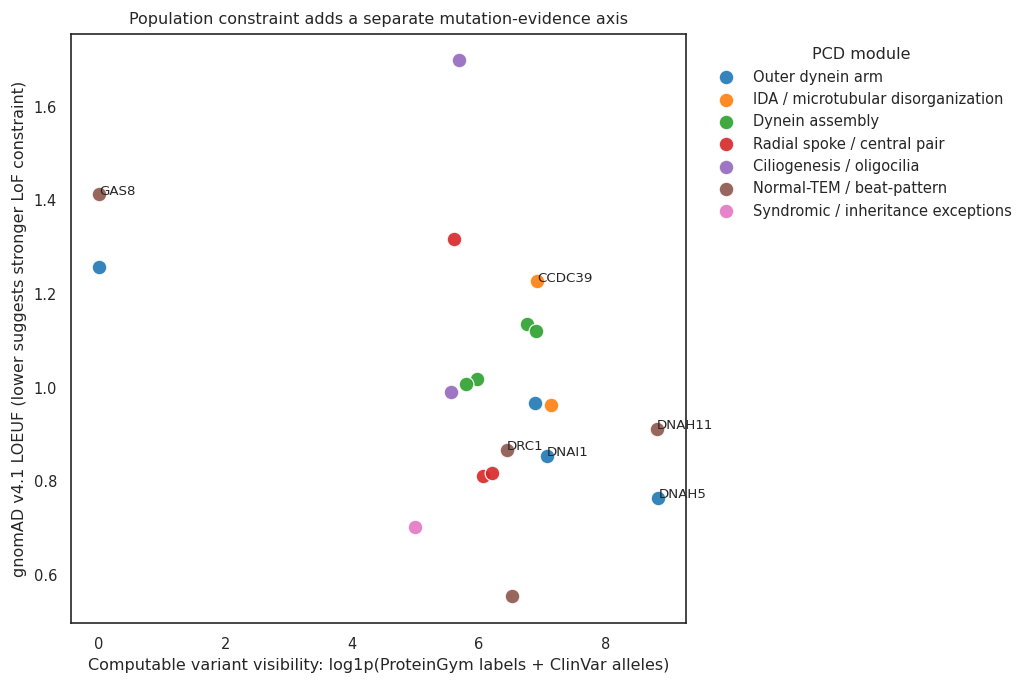

In [ ]:

wow_gnomad_constraint_url = "https://storage.googleapis.com/gcp-public-data--gnomad/release/4.1/constraint/gnomad.v4.1.constraint_metrics.tsv"
wow_gnomad_constraint_cache = PROCESSED_DIR / "pcd_wow_gnomad_v4_1_constraint_panel.csv"
wow_constraint_usecols = [
    "gene", "gene_id", "canonical", "mane_select", "lof.oe", "lof.pLI", "lof.oe_ci.upper", "lof.z_score", "mis.oe", "mis.z_score", "syn.oe", "syn.z_score"
]

if wow_gnomad_constraint_cache.exists():
    wow_constraint_panel = pd.read_csv(wow_gnomad_constraint_cache)
else:
    try:
        wow_constraint_raw = pd.read_csv(wow_gnomad_constraint_url, sep="\t", usecols=wow_constraint_usecols)
        wow_constraint_raw = wow_constraint_raw[
            wow_constraint_raw["gene"].isin(atlas_final_atlas_table["gene_symbol"])
            & wow_constraint_raw["canonical"].astype(bool)
            & wow_constraint_raw["gene_id"].astype(str).str.startswith("ENSG")
        ].copy()
        wow_constraint_raw = (
            wow_constraint_raw.sort_values(["gene", "mane_select"], ascending=[True, False])
            .groupby("gene", as_index=False)
            .head(1)
        )
        wow_constraint_panel = wow_constraint_raw.rename(
            columns={
                "gene": "gene_symbol",
                "gene_id": "gnomad_gene_id",
                "lof.oe": "gnomad_lof_oe",
                "lof.pLI": "gnomad_pLI",
                "lof.oe_ci.upper": "gnomad_loeuf",
                "lof.z_score": "gnomad_lof_z",
                "mis.oe": "gnomad_mis_oe",
                "mis.z_score": "gnomad_mis_z",
                "syn.oe": "gnomad_syn_oe",
                "syn.z_score": "gnomad_syn_z",
            }
        )
        wow_constraint_panel["constraint_source"] = wow_gnomad_constraint_url
        wow_constraint_panel["constraint_version"] = "gnomAD v4.1 constraint metrics"
        wow_constraint_panel["constraint_fetch_status"] = "ok"
        wow_constraint_panel.to_csv(wow_gnomad_constraint_cache, index=False)
    except Exception as wow_constraint_error:
        wow_constraint_panel = pd.DataFrame(
            {
                "gene_symbol": atlas_final_atlas_table["gene_symbol"],
                "constraint_source": wow_gnomad_constraint_url,
                "constraint_version": "gnomAD v4.1 constraint metrics",
                "constraint_fetch_status": f"fetch_failed: {wow_constraint_error}",
            }
        )

wow_constraint_augmented_table = atlas_final_atlas_table.merge(
    wow_constraint_panel,
    on="gene_symbol",
    how="left",
)
wow_constraint_augmented_table["constraint_fetch_status"] = wow_constraint_augmented_table["constraint_fetch_status"].fillna("not_found_in_constraint_table")
wow_constraint_coverage_summary = pd.DataFrame(
    [
        {"metric": "PCD panel genes", "value": len(wow_constraint_augmented_table)},
        {"metric": "genes with gnomAD constraint rows", "value": int(wow_constraint_augmented_table["gnomad_loeuf"].notna().sum()) if "gnomad_loeuf" in wow_constraint_augmented_table else 0},
        {"metric": "source", "value": wow_gnomad_constraint_url},
        {"metric": "cache", "value": wow_gnomad_constraint_cache.name},
    ]
)

fig_wow_constraint, ax_wow_constraint = plt.subplots(figsize=(8.7, 5.8))
wow_constraint_plot = wow_constraint_augmented_table.dropna(subset=["gnomad_loeuf"]).copy() if "gnomad_loeuf" in wow_constraint_augmented_table else pd.DataFrame()
if not wow_constraint_plot.empty:
    for wow_constraint_module_name, wow_constraint_module_group in wow_constraint_plot.groupby("pcd_module", observed=True):
        ax_wow_constraint.scatter(
            np.log1p(wow_constraint_module_group["clinical_variant_count"] + wow_constraint_module_group["clinvar_total_records"]),
            wow_constraint_module_group["gnomad_loeuf"],
            s=78,
            color=module_palette[wow_constraint_module_name],
            edgecolor="white",
            linewidth=0.8,
            alpha=0.9,
            label=str(wow_constraint_module_name),
        )
    for wow_constraint_label_gene in ["DNAH11", "DNAH5", "DRC1", "GAS8", "CCDC39", "DNAI1"]:
        wow_constraint_label_row = wow_constraint_plot[wow_constraint_plot["gene_symbol"].eq(wow_constraint_label_gene)]
        if not wow_constraint_label_row.empty:
            wow_constraint_record = wow_constraint_label_row.iloc[0]
            ax_wow_constraint.text(
                np.log1p(wow_constraint_record["clinical_variant_count"] + wow_constraint_record["clinvar_total_records"]),
                wow_constraint_record["gnomad_loeuf"],
                wow_constraint_label_gene,
                fontsize=8,
            )
    ax_wow_constraint.set_xlabel("Computable variant visibility: log1p(ProteinGym labels + ClinVar alleles)")
    ax_wow_constraint.set_ylabel("gnomAD v4.1 LOEUF (lower suggests stronger LoF constraint)")
    ax_wow_constraint.set_title("Population constraint adds a separate mutation-evidence axis")
    ax_wow_constraint.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, title="PCD module")
else:
    ax_wow_constraint.text(0.5, 0.5, "gnomAD constraint unavailable", ha="center", va="center")
    ax_wow_constraint.axis("off")
fig_wow_constraint.tight_layout()
save_figure(fig_wow_constraint, "pcd_gnomad_constraint_vs_public_visibility")

wow_constraint_review_table = pd.DataFrame(
    [
        {"gate": "Data integrity", "assessment": f"Constraint rows joined for {int(wow_constraint_augmented_table['gnomad_loeuf'].notna().sum()) if 'gnomad_loeuf' in wow_constraint_augmented_table else 0}/{len(wow_constraint_augmented_table)} panel genes using canonical gnomAD v4.1 rows."},
        {"gate": "Claim integrity", "assessment": "LOEUF/pLI are population constraint metrics, not PCD severity, penetrance, or clinical actionability."},
        {"gate": "Keep / revise / demote", "assessment": "Keep if source remains reachable and cached; otherwise demote to a source-cited future-work note."},
    ]
)

mo.vstack(
    [
        mo.md("## gnomAD Constraint Context\n\nThis layer tests whether population constraint changes the mutation-evidence story. It is kept separate from clinical severity and variant interpretation."),
        mo.ui.table(wow_constraint_coverage_summary, pagination=False),
        fig_wow_constraint,
        mo.md("**Caveat:** gnomAD constraint summarizes population selection against classes of variants. It is not a PCD prognosis, penetrance, or diagnostic metric."),
        mo.md("### Review Gate: Constraint Layer"),
        mo.ui.table(wow_constraint_review_table, pagination=False),
    ]
)

Quantitative HPA Support for GTEx Context 
 HPA per-gene TSV pages provide quantitative tissue and single-cell context. This is used as external support for ciliated-cell and reproductive-tissue visibility, not as a raw-value validation against GTEx. <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"_marimo_row_id\":0,\"metric\":\"genes with HPA per-gene TSV fetched\",\"value\":25},{\"_marimo_row_id\":1,\"metric\":\"genes with ciliated/deuterosomal/ependymal single-cell support\",\"value\":24},{\"_marimo_row_id\":2,\"metric\":\"genes with HPA reproductive tissue nTPM support\",\"value\":18},{\"_marimo_row_id\":3,\"metric\":\"cache\",\"value\":\"pcd_wow_hpa_gene_support.csv\"}]"' data-total-rows='4' data-total-columns='2' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='4' data-field-types='[["metric",["string","str"]],["value",["string","object"]]]' data-selection='"multi"' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='true' data-lazy='false' data-preload='false'> <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"\":0,\"_marimo_row_id\":0,\"gene_symbol\":\"ARMC4\",\"top_gtex_tissue\":\"Testis\",\"hpa_top_tissue\":\"testis\",\"hpa_ciliated_cell_max_ncpm\":653.3,\"hpa_reproductive_tissue_max_ntpm\":38.0,\"hpa_fetch_status\":\"ok\"},{\"\":1,\"_marimo_row_id\":1,\"gene_symbol\":\"CCDC103\",\"top_gtex_tissue\":\"Brain_Cortex\",\"hpa_top_tissue\":\"testis\",\"hpa_ciliated_cell_max_ncpm\":16.4,\"hpa_reproductive_tissue_max_ntpm\":38.9,\"hpa_fetch_status\":\"ok\"},{\"\":2,\"_marimo_row_id\":2,\"gene_symbol\":\"CCDC114\",\"top_gtex_tissue\":\"Testis\",\"hpa_top_tissue\":\"choroid plexus\",\"hpa_ciliated_cell_max_ncpm\":162.8,\"hpa_reproductive_tissue_max_ntpm\":24.0,\"hpa_fetch_status\":\"ok\"},{\"\":6,\"_marimo_row_id\":3,\"gene_symbol\":\"CCDC39\",\"top_gtex_tissue\":\"Ovary\",\"hpa_top_tissue\":NaN,\"hpa_ciliated_cell_max_ncpm\":NaN,\"hpa_reproductive_tissue_max_ntpm\":NaN,\"hpa_fetch_status\":\"fetch_failed: HTTP Error 404: Not Found\"},{\"\":7,\"_marimo_row_id\":4,\"gene_symbol\":\"CCDC40\",\"top_gtex_tissue\":\"Testis\",\"hpa_top_tissue\":\"fallopian tube\",\"hpa_ciliated_cell_max_ncpm\":301.7,\"hpa_reproductive_tissue_max_ntpm\":14.0,\"hpa_fetch_status\":\"ok\"},{\"\":17,\"_marimo_row_id\":5,\"gene_symbol\":\"CCNO\",\"top_gtex_tissue\":\"Testis\",\"hpa_top_tissue\":\"testis\",\"hpa_ciliated_cell_max_ncpm\":995.2,\"hpa_reproductive_tissue_max_ntpm\":12.5,\"hpa_fetch_status\":\"ok\"},{\"\":8,\"_marimo_row_id\":6,\"gene_symbol\":\"DNAAF1\",\"top_gtex_tissue\":\"Testis\",\"hpa_top_tissue\":\"testis\",\"hpa_ciliated_cell_max_ncpm\":768.5,\"hpa_reproductive_tissue_max_ntpm\":42.3,\"hpa_fetch_status\":\"ok\"},{\"\":9,\"_marimo_row_id\":7,\"gene_symbol\":\"DNAAF4\",\"top_gtex_tissue\":\"Thyroid\",\"hpa_top_tissue\":\"retina\",\"hpa_ciliated_cell_max_ncpm\":195.6,\"hpa_reproductive_tissue_max_ntpm\":NaN,\"hpa_fetch_status\":\"ok\"}]"' data-total-rows='26' data-total-columns='6' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='8' data-field-types='[["gene_symbol",["string","str"]],["top_gtex_tissue",["string","str"]],["hpa_top_tissue",["string","str"]],["hpa_ciliated_cell_max_ncpm",["number","float64"]],["hpa_reproductive_tissue_max_ntpm",["number","float64"]],["hpa_fetch_status",["string","str"]]]' data-selection='"multi"' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[["",["integer","int64"]]]' data-has-stable-row-id='true' data-lazy='false' data-preload='false'> Review Gate: HPA Quantitative Support <marimo-table data-initial-value=
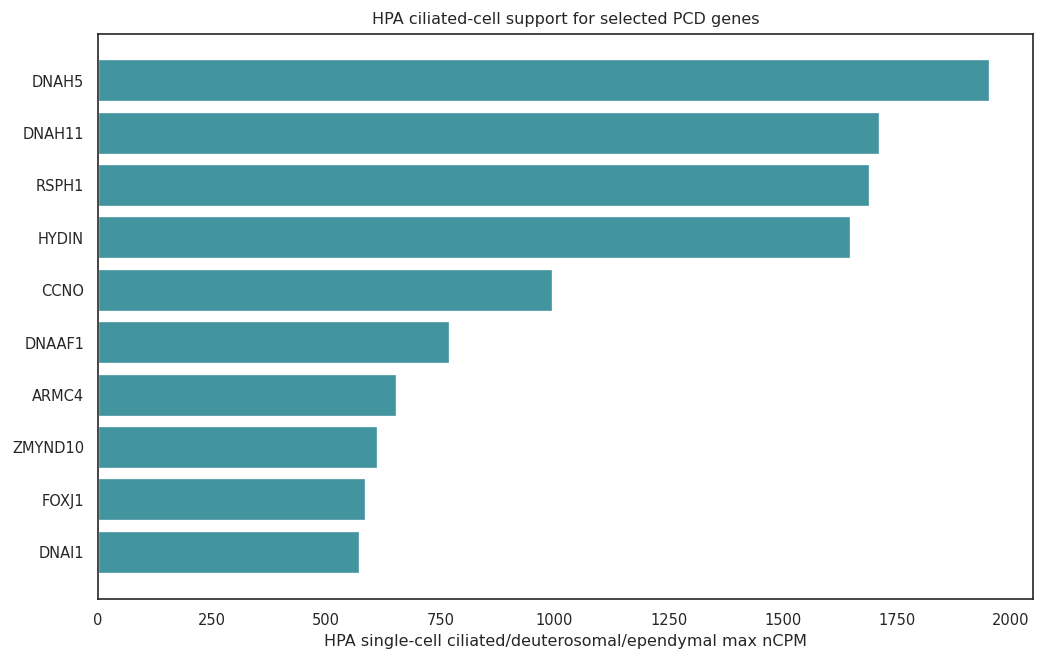

In [ ]:

wow_hpa_cache = PROCESSED_DIR / "pcd_wow_hpa_gene_support.csv"
wow_gtex_gene_ids = (
    gtex_expression[["gene_symbol", "gencode_id"]]
    .drop_duplicates()
    .assign(hpa_ensembl=lambda wow_frame: wow_frame["gencode_id"].astype(str).str.replace(r"\..*$", "", regex=True))
)


def wow_parse_hpa_metric_string(wow_metric_value: object) -> dict[str, float]:
    if pd.isna(wow_metric_value) or str(wow_metric_value).strip() == "":
        return {}
    wow_pairs = {}
    for wow_part in str(wow_metric_value).split(";"):
        if ":" not in wow_part:
            continue
        wow_key, wow_value = wow_part.rsplit(":", 1)
        try:
            wow_pairs[wow_key.strip()] = float(wow_value.strip())
        except ValueError:
            continue
    return wow_pairs

if wow_hpa_cache.exists():
    wow_hpa_support_table = pd.read_csv(wow_hpa_cache)
    wow_hpa_required_columns = ["hpa_ciliated_cell_max_ncpm", "hpa_reproductive_tissue_max_ntpm", "hpa_fetch_status"]
    if any(wow_required_column not in wow_hpa_support_table.columns for wow_required_column in wow_hpa_required_columns):
        wow_hpa_cache.unlink()
        wow_hpa_support_table = pd.DataFrame()
else:
    wow_hpa_support_table = pd.DataFrame()

if wow_hpa_support_table.empty:
    wow_hpa_rows = []
    for wow_hpa_gene_record in wow_gtex_gene_ids.to_dict("records"):
        wow_hpa_url = f"https://www.proteinatlas.org/{wow_hpa_gene_record['hpa_ensembl']}.tsv"
        try:
            wow_hpa_gene_df = pd.read_csv(wow_hpa_url, sep="\t")
            wow_hpa_gene_row = wow_hpa_gene_df.iloc[0]
            wow_hpa_tissue_values = wow_parse_hpa_metric_string(wow_hpa_gene_row.get("RNA tissue specific nTPM"))
            wow_hpa_cell_values = wow_parse_hpa_metric_string(wow_hpa_gene_row.get("RNA single cell type specific nCPM"))
            wow_hpa_top_tissue = max(wow_hpa_tissue_values, key=wow_hpa_tissue_values.get) if wow_hpa_tissue_values else "not reported"
            wow_hpa_top_tissue_value = wow_hpa_tissue_values.get(wow_hpa_top_tissue, np.nan) if wow_hpa_tissue_values else np.nan
            wow_hpa_ciliated_cell_values = {wow_key: wow_value for wow_key, wow_value in wow_hpa_cell_values.items() if "ciliated" in wow_key.lower() or "deuterosomal" in wow_key.lower() or "ependymal" in wow_key.lower()}
            wow_hpa_reproductive_tissue_values = {wow_key: wow_value for wow_key, wow_value in wow_hpa_tissue_values.items() if any(wow_term in wow_key.lower() for wow_term in ["testis", "fallopian", "ovary", "prostate", "vagina", "cervix"])}
            wow_hpa_rows.append(
                {
                    "gene_symbol": wow_hpa_gene_record["gene_symbol"],
                    "hpa_ensembl": wow_hpa_gene_record["hpa_ensembl"],
                    "hpa_url": wow_hpa_url,
                    "hpa_fetch_status": "ok",
                    "hpa_top_tissue": wow_hpa_top_tissue,
                    "hpa_top_tissue_ntpm": wow_hpa_top_tissue_value,
                    "hpa_rna_tissue_specificity": wow_hpa_gene_row.get("RNA tissue specificity"),
                    "hpa_tissue_expression_cluster": wow_hpa_gene_row.get("Tissue expression cluster"),
                    "hpa_single_cell_expression_cluster": wow_hpa_gene_row.get("Single cell expression cluster"),
                    "hpa_ciliated_cell_max_ncpm": max(wow_hpa_ciliated_cell_values.values()) if wow_hpa_ciliated_cell_values else np.nan,
                    "hpa_ciliated_cell_examples": "; ".join([f"{wow_key}: {wow_value:.1f}" for wow_key, wow_value in sorted(wow_hpa_ciliated_cell_values.items(), key=lambda item: item[1], reverse=True)[:3]]),
                    "hpa_reproductive_tissue_max_ntpm": max(wow_hpa_reproductive_tissue_values.values()) if wow_hpa_reproductive_tissue_values else np.nan,
                    "hpa_reproductive_tissue_examples": "; ".join([f"{wow_key}: {wow_value:.1f}" for wow_key, wow_value in sorted(wow_hpa_reproductive_tissue_values.items(), key=lambda item: item[1], reverse=True)[:3]]),
                }
            )
        except Exception as wow_hpa_error:
            wow_hpa_rows.append(
                {
                    "gene_symbol": wow_hpa_gene_record["gene_symbol"],
                    "hpa_ensembl": wow_hpa_gene_record["hpa_ensembl"],
                    "hpa_url": wow_hpa_url,
                    "hpa_fetch_status": f"fetch_failed: {wow_hpa_error}",
                }
            )
    wow_hpa_support_table = pd.DataFrame(wow_hpa_rows)
    wow_hpa_support_table.to_csv(wow_hpa_cache, index=False)

wow_hpa_gtex_agreement = atlas_final_atlas_table[["gene_symbol", "top_gtex_tissue", "reproductive_max", "respiratory"]].merge(
    wow_hpa_support_table,
    on="gene_symbol",
    how="left",
)
wow_hpa_gtex_agreement["hpa_supports_ciliated_context"] = wow_hpa_gtex_agreement["hpa_ciliated_cell_max_ncpm"].notna()
wow_hpa_gtex_agreement["hpa_supports_reproductive_context"] = wow_hpa_gtex_agreement["hpa_reproductive_tissue_max_ntpm"].notna()
wow_hpa_gtex_agreement["hpa_top_tissue_lower"] = wow_hpa_gtex_agreement["hpa_top_tissue"].fillna("").str.lower()
wow_hpa_gtex_agreement["gtex_top_tissue_lower"] = wow_hpa_gtex_agreement["top_gtex_tissue"].fillna("").str.replace("_", " ").str.lower()
wow_hpa_gtex_agreement["hpa_gtex_top_tissue_overlap"] = wow_hpa_gtex_agreement.apply(
    lambda wow_row: bool(wow_row["hpa_top_tissue_lower"] and (wow_row["hpa_top_tissue_lower"] in wow_row["gtex_top_tissue_lower"] or wow_row["gtex_top_tissue_lower"] in wow_row["hpa_top_tissue_lower"])),
    axis=1,
)

wow_hpa_summary = pd.DataFrame(
    [
        {"metric": "genes with HPA per-gene TSV fetched", "value": int(wow_hpa_gtex_agreement["hpa_fetch_status"].eq("ok").sum())},
        {"metric": "genes with ciliated/deuterosomal/ependymal single-cell support", "value": int(wow_hpa_gtex_agreement["hpa_supports_ciliated_context"].sum())},
        {"metric": "genes with HPA reproductive tissue nTPM support", "value": int(wow_hpa_gtex_agreement["hpa_supports_reproductive_context"].sum())},
        {"metric": "cache", "value": wow_hpa_cache.name},
    ]
)

wow_hpa_plot_table = wow_hpa_gtex_agreement.sort_values("hpa_ciliated_cell_max_ncpm", ascending=False).head(10)
fig_wow_hpa, ax_wow_hpa = plt.subplots(figsize=(8.8, 5.6))
ax_wow_hpa.barh(
    wow_hpa_plot_table["gene_symbol"],
    wow_hpa_plot_table["hpa_ciliated_cell_max_ncpm"].fillna(0),
    color=PALETTE["teal"],
)
ax_wow_hpa.set_xlabel("HPA single-cell ciliated/deuterosomal/ependymal max nCPM")
ax_wow_hpa.set_title("HPA ciliated-cell support for selected PCD genes")
ax_wow_hpa.invert_yaxis()
fig_wow_hpa.tight_layout()
save_figure(fig_wow_hpa, "pcd_hpa_gtex_agreement")
save_figure(fig_wow_hpa, "pcd_hpa_ciliated_cell_support")

wow_hpa_review_table = pd.DataFrame(
    [
        {"gate": "Data integrity", "assessment": f"Fetched HPA per-gene TSV rows for {int(wow_hpa_gtex_agreement['hpa_fetch_status'].eq('ok').sum())}/{len(wow_hpa_gtex_agreement)} panel genes."},
        {"gate": "Claim integrity", "assessment": "This is quantitative HPA support/context, not raw cross-platform validation or patient airway disease evidence."},
        {"gate": "Keep / revise / demote", "assessment": "Keep as support if per-gene TSV access remains stable; do not compare raw HPA nCPM and GTEx TPM directly."},
    ]
)

mo.vstack(
    [
        mo.md("## Quantitative HPA Support for GTEx Context\n\nHPA per-gene TSV pages provide quantitative tissue and single-cell context. This is used as external support for ciliated-cell and reproductive-tissue visibility, not as a raw-value validation against GTEx."),
        mo.ui.table(wow_hpa_summary, pagination=False),
        fig_wow_hpa,
        mo.ui.table(wow_hpa_gtex_agreement[["gene_symbol", "top_gtex_tissue", "hpa_top_tissue", "hpa_ciliated_cell_max_ncpm", "hpa_reproductive_tissue_max_ntpm", "hpa_fetch_status"]].sort_values("gene_symbol"), pagination=True, page_size=8),
        mo.md("### Review Gate: HPA Quantitative Support"),
        mo.ui.table(wow_hpa_review_table, pagination=False),
    ]
)

In [ ]:

wow_clinical_source_rows = [
    {
        "topic": "Disease overview",
        "statement_for_notebook": "PCD is a genetically heterogeneous disorder of motile-cilia function with chronic oto-sino-pulmonary disease and laterality, fertility, and neonatal respiratory contexts described at the disease level.",
        "source_type": "GeneReviews",
        "stable_url": "https://www.ncbi.nlm.nih.gov/books/NBK1122/",
        "pmid": "20301301",
        "boundary_note": "Disease-level overview only; not used for gene-specific symptom prediction.",
        "access_date": str(date.today()),
    },
    {
        "topic": "Rare disease classification",
        "statement_for_notebook": "Orphanet lists primary ciliary dyskinesia as ORPHA:244 and frames it as a rare inherited ciliopathy.",
        "source_type": "Orphanet",
        "stable_url": "https://www.orpha.net/en/disease/detail/244",
        "pmid": "",
        "boundary_note": "Classification context only; no prevalence number is reused here.",
        "access_date": str(date.today()),
    },
    {
        "topic": "Patient-facing disease context",
        "statement_for_notebook": "GARD describes PCD as a rare disease with respiratory infections, laterality defects, and fertility-related context among possible disease-level features.",
        "source_type": "GARD / NIH",
        "stable_url": "https://rarediseases.info.nih.gov/diseases/9631/primary-ciliary-dyskinesia",
        "pmid": "",
        "boundary_note": "Public explanatory context only; not used for individual risk or prognosis.",
        "access_date": str(date.today()),
    },
    {
        "topic": "Diagnostic boundary",
        "statement_for_notebook": "ERS diagnostic guidance emphasizes that PCD diagnosis requires specialized clinical testing and cannot be inferred from a single public-data layer.",
        "source_type": "Clinical guideline",
        "stable_url": "https://pmc.ncbi.nlm.nih.gov/articles/PMC6054534/",
        "pmid": "27836958",
        "boundary_note": "Used to explicitly bound this notebook away from diagnosis.",
        "access_date": str(date.today()),
    },
    {
        "topic": "Cohort heterogeneity",
        "statement_for_notebook": "The iPCD cohort literature shows PCD presentation and diagnosis are heterogeneous across populations and data collection contexts.",
        "source_type": "Cohort paper",
        "stable_url": "https://pmc.ncbi.nlm.nih.gov/articles/PMC5298195/",
        "pmid": "28053154",
        "boundary_note": "Aggregate cohort context; not used to estimate outcomes for genes or people.",
        "access_date": str(date.today()),
    },
    {
        "topic": "Diagnostic delay",
        "statement_for_notebook": "Published cohort work has discussed diagnostic delay in PCD, motivating public-data visibility questions without claiming this atlas can close that delay clinically.",
        "source_type": "Clinical cohort / epidemiology",
        "stable_url": "https://pubmed.ncbi.nlm.nih.gov/20530032/",
        "pmid": "20530032",
        "boundary_note": "Motivation only; the notebook does not evaluate diagnostic performance.",
        "access_date": str(date.today()),
    },
    {
        "topic": "Normal-ultrastructure caveat",
        "statement_for_notebook": "Examples such as DNAH11-associated PCD motivate the normal/subtle TEM category used in the diagnostic-visibility layer.",
        "source_type": "Gene/example paper",
        "stable_url": "https://pubmed.ncbi.nlm.nih.gov/18022865/",
        "pmid": "18022865",
        "boundary_note": "Used narrowly to justify a diagnostic-visibility category, not to infer symptoms from DNAH11 expression.",
        "access_date": str(date.today()),
    },
]

wow_phenotype_prognosis_sources = pd.DataFrame(wow_clinical_source_rows)
wow_phenotype_review_table = pd.DataFrame(
    [
        {"gate": "Source specificity", "assessment": f"Added {len(wow_phenotype_prognosis_sources)} concrete source rows with stable URLs, PMIDs when available, access dates, and boundary notes."},
        {"gate": "Clinical safety", "assessment": "Statements stay disease-level or diagnostic-boundary-level; no source row is used for patient-specific prognosis or gene-specific symptom prediction."},
        {"gate": "Keep / revise / demote", "assessment": "Keep as the clinical-context spine; any future clinical statement must map back to one of these rows or be removed."},
    ]
)

mo.vstack(
    [
        mo.md("## Citation-Backed Phenotype and Prognosis Context\n\nThis replaces generic clinical-context wording with precise source rows. The sources motivate disease-level context and boundaries; they do not turn the atlas into a diagnostic, prognostic, or treatment tool."),
        mo.ui.table(wow_phenotype_prognosis_sources, pagination=True, page_size=7),
        mo.md("### Review Gate: Phenotype and Prognosis Citations"),
        mo.ui.table(wow_phenotype_review_table, pagination=False),
    ]
)

Citation-Backed Phenotype and Prognosis Context 
 This replaces generic clinical-context wording with precise source rows. The sources motivate disease-level context and boundaries; they do not turn the atlas into a diagnostic, prognostic, or treatment tool. <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"_marimo_row_id\":0,\"topic\":\"Disease overview\",\"statement_for_notebook\":\"PCD is a genetically heterogeneous disorder of motile-cilia function with chronic oto-sino-pulmonary disease and laterality, fertility, and neonatal respiratory contexts described at the disease level.\",\"source_type\":\"GeneReviews\",\"stable_url\":\"https://www.ncbi.nlm.nih.gov/books/NBK1122/\",\"pmid\":\"20301301\",\"boundary_note\":\"Disease-level overview only; not used for gene-specific symptom prediction.\",\"access_date\":\"2026-05-14\"},{\"_marimo_row_id\":1,\"topic\":\"Rare disease classification\",\"statement_for_notebook\":\"Orphanet lists primary ciliary dyskinesia as ORPHA:244 and frames it as a rare inherited ciliopathy.\",\"source_type\":\"Orphanet\",\"stable_url\":\"https://www.orpha.net/en/disease/detail/244\",\"pmid\":\"\",\"boundary_note\":\"Classification context only; no prevalence number is reused here.\",\"access_date\":\"2026-05-14\"},{\"_marimo_row_id\":2,\"topic\":\"Patient-facing disease context\",\"statement_for_notebook\":\"GARD describes PCD as a rare disease with respiratory infections, laterality defects, and fertility-related context among possible disease-level features.\",\"source_type\":\"GARD / NIH\",\"stable_url\":\"https://rarediseases.info.nih.gov/diseases/9631/primary-ciliary-dyskinesia\",\"pmid\":\"\",\"boundary_note\":\"Public explanatory context only; not used for individual risk or prognosis.\",\"access_date\":\"2026-05-14\"},{\"_marimo_row_id\":3,\"topic\":\"Diagnostic boundary\",\"statement_for_notebook\":\"ERS diagnostic guidance emphasizes that PCD diagnosis requires specialized clinical testing and cannot be inferred from a single public-data layer.\",\"source_type\":\"Clinical guideline\",\"stable_url\":\"https://pmc.ncbi.nlm.nih.gov/articles/PMC6054534/\",\"pmid\":\"27836958\",\"boundary_note\":\"Used to explicitly bound this notebook away from diagnosis.\",\"access_date\":\"2026-05-14\"},{\"_marimo_row_id\":4,\"topic\":\"Cohort heterogeneity\",\"statement_for_notebook\":\"The iPCD cohort literature shows PCD presentation and diagnosis are heterogeneous across populations and data collection contexts.\",\"source_type\":\"Cohort paper\",\"stable_url\":\"https://pmc.ncbi.nlm.nih.gov/articles/PMC5298195/\",\"pmid\":\"28053154\",\"boundary_note\":\"Aggregate cohort context; not used to estimate outcomes for genes or people.\",\"access_date\":\"2026-05-14\"},{\"_marimo_row_id\":5,\"topic\":\"Diagnostic delay\",\"statement_for_notebook\":\"Published cohort work has discussed diagnostic delay in PCD, motivating public-data visibility questions without claiming this atlas can close that delay clinically.\",\"source_type\":\"Clinical cohort / epidemiology\",\"stable_url\":\"https://pubmed.ncbi.nlm.nih.gov/20530032/\",\"pmid\":\"20530032\",\"boundary_note\":\"Motivation only; the notebook does not evaluate diagnostic performance.\",\"access_date\":\"2026-05-14\"},{\"_marimo_row_id\":6,\"topic\":\"Normal-ultrastructure caveat\",\"statement_for_notebook\":\"Examples such as DNAH11-associated PCD motivate the normal/subtle TEM category used in the diagnostic-visibility layer.\",\"source_type\":\"Gene/example paper\",\"stable_url\":\"https://pubmed.ncbi.nlm.nih.gov/18022865/\",\"pmid\":\"18022865\",\"boundary_note\":\"Used narrowly to justify a diagnostic-visibility category, not to infer symptoms from DNAH11 expression.\",\"access_date\":\"2026-05-14\"}]"' data-total-rows='7' data-total-columns='7' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='7' data-field-types='[["topic",["string","str"]],["statement_for_notebook",["string","str"]],["source_type

Gap-Index Sensitivity 
 The original public-data gap score is a heuristic. This sensitivity analysis asks which genes remain visible curation leads under reasonable alternate weights. <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"\":13,\"_marimo_row_id\":0,\"gene_symbol\":\"DRC1\",\"pcd_module\":\"Normal-TEM / beat-pattern\",\"diagnostic_visibility\":\"Normal TEM / beat-pattern\",\"proteingym_covered\":false,\"known_but_not_benchmark_ready\":true,\"median_rank\":2.0,\"best_rank\":1,\"worst_rank\":5,\"rank_range\":4,\"appears_top_5_n_scenarios\":7,\"mean_scenario_score\":0.9849008189969003},{\"\":15,\"_marimo_row_id\":1,\"gene_symbol\":\"GAS8\",\"pcd_module\":\"Normal-TEM / beat-pattern\",\"diagnostic_visibility\":\"Normal TEM / beat-pattern\",\"proteingym_covered\":false,\"known_but_not_benchmark_ready\":false,\"median_rank\":2.0,\"best_rank\":1,\"worst_rank\":19,\"rank_range\":18,\"appears_top_5_n_scenarios\":5,\"mean_scenario_score\":1.3378054249185198},{\"\":16,\"_marimo_row_id\":2,\"gene_symbol\":\"HYDIN\",\"pcd_module\":\"Normal-TEM / beat-pattern\",\"diagnostic_visibility\":\"Normal TEM / beat-pattern\",\"proteingym_covered\":false,\"known_but_not_benchmark_ready\":true,\"median_rank\":3.0,\"best_rank\":1,\"worst_rank\":15,\"rank_range\":14,\"appears_top_5_n_scenarios\":5,\"mean_scenario_score\":0.7378190792686773},{\"\":24,\"_marimo_row_id\":3,\"gene_symbol\":\"RSPH9\",\"pcd_module\":\"Radial spoke / central pair\",\"diagnostic_visibility\":\"Often subtle / variable TEM\",\"proteingym_covered\":false,\"known_but_not_benchmark_ready\":true,\"median_rank\":4.0,\"best_rank\":1,\"worst_rank\":10,\"rank_range\":9,\"appears_top_5_n_scenarios\":5,\"mean_scenario_score\":1.0345187453426627},{\"\":14,\"_marimo_row_id\":4,\"gene_symbol\":\"FOXJ1\",\"pcd_module\":\"Syndromic / inheritance exceptions\",\"diagnostic_visibility\":\"Syndromic / inheritance exception\",\"proteingym_covered\":false,\"known_but_not_benchmark_ready\":false,\"median_rank\":5.0,\"best_rank\":1,\"worst_rank\":13,\"rank_range\":12,\"appears_top_5_n_scenarios\":5,\"mean_scenario_score\":0.9495843173043345},{\"\":3,\"_marimo_row_id\":5,\"gene_symbol\":\"CCDC39\",\"pcd_module\":\"IDA / microtubular disorganization\",\"diagnostic_visibility\":\"Visible TEM defect\",\"proteingym_covered\":false,\"known_but_not_benchmark_ready\":true,\"median_rank\":7.0,\"best_rank\":1,\"worst_rank\":17,\"rank_range\":16,\"appears_top_5_n_scenarios\":3,\"mean_scenario_score\":0.7775380505643137},{\"\":9,\"_marimo_row_id\":6,\"gene_symbol\":\"DNAH11\",\"pcd_module\":\"Normal-TEM / beat-pattern\",\"diagnostic_visibility\":\"Normal TEM / beat-pattern\",\"proteingym_covered\":false,\"known_but_not_benchmark_ready\":true,\"median_rank\":6.0,\"best_rank\":1,\"worst_rank\":23,\"rank_range\":22,\"appears_top_5_n_scenarios\":2,\"mean_scenario_score\":0.7499335966979643},{\"\":10,\"_marimo_row_id\":7,\"gene_symbol\":\"DNAH5\",\"pcd_module\":\"Outer dynein arm\",\"diagnostic_visibility\":\"Visible TEM defect\",\"proteingym_covered\":false,\"known_but_not_benchmark_ready\":true,\"median_rank\":9.0,\"best_rank\":1,\"worst_rank\":25,\"rank_range\":24,\"appears_top_5_n_scenarios\":2,\"mean_scenario_score\":0.6127349194897471},{\"\":1,\"_marimo_row_id\":8,\"gene_symbol\":\"CCDC103\",\"pcd_module\":\"Outer dynein arm\",\"diagnostic_visibility\":\"Visible TEM defect\",\"proteingym_covered\":false,\"known_but_not_benchmark_ready\":false,\"median_rank\":9.0,\"best_rank\":1,\"worst_rank\":26,\"rank_range\":25,\"appears_top_5_n_scenarios\":1,\"mean_scenario_score\":0.41295728010492044},{\"\":25,\"_marimo_row_id\":9,\"gene_symbol\":\"ZMYND10\",\"pcd_module\":\"Dynein assembly\",\"diagnostic_visibility\":\"Visible TEM defect\",\"proteingym_covered\":true,\"known_but_not_benchmark_ready\":false,\"median_rank\":10.0,\"best_rank\":1,\"worst_rank\":20,\"rank_range\":19,\"appears_top_5_n_scenarios\":1,\"mean_scenario_score\":0.5115001646057384}]"' data-total-rows='10' data-total-colum
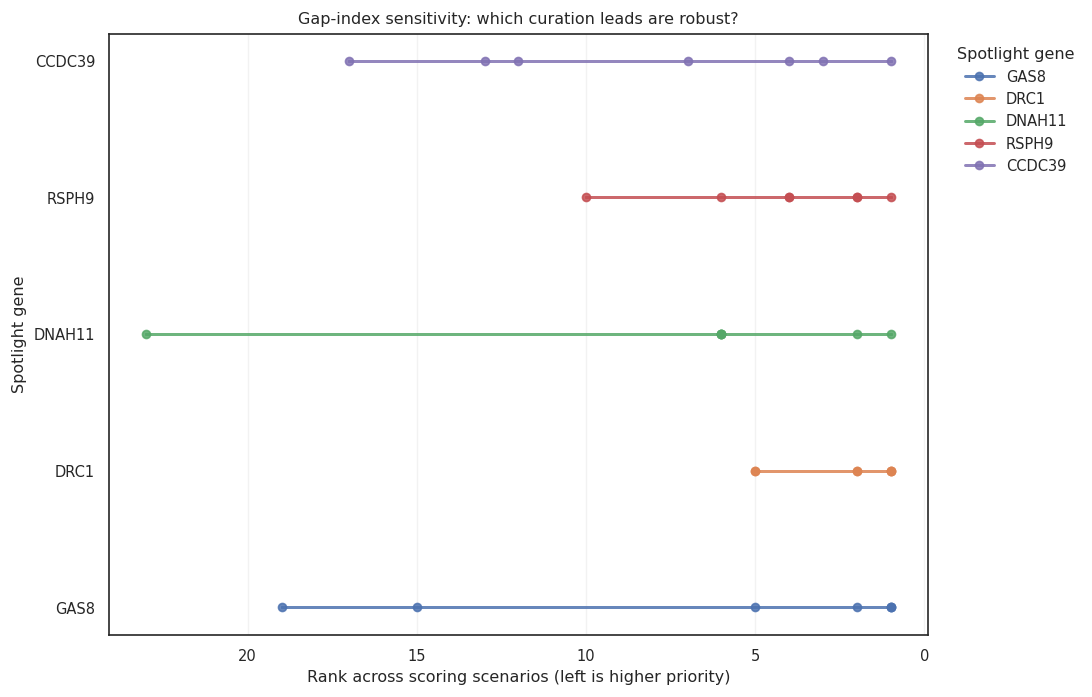

In [ ]:

def wow_minmax(wow_series: pd.Series) -> pd.Series:
    wow_numeric_series = pd.to_numeric(wow_series, errors="coerce").fillna(0)
    wow_range = wow_numeric_series.max() - wow_numeric_series.min()
    if wow_range == 0:
        return pd.Series(np.zeros(len(wow_numeric_series)), index=wow_numeric_series.index)
    return (wow_numeric_series - wow_numeric_series.min()) / wow_range

wow_gap_base = atlas_final_atlas_table.copy()
wow_gap_base["tissue_axis_priority"] = wow_minmax(wow_gap_base["reproductive_max_minus_respiratory"].clip(lower=0))
wow_gap_base["diagnostic_priority"] = wow_minmax(wow_gap_base["diagnostic_subtlety_score"])
wow_gap_base["benchmark_gap_priority"] = (~wow_gap_base["proteingym_covered"].astype(bool)).astype(float)
wow_gap_base["dms_gap_priority"] = (~wow_gap_base["proteingym_dms_covered"].astype(bool)).astype(float)
wow_gap_base["clinvar_gap_priority"] = 1 - wow_minmax(np.log1p(wow_gap_base["clinvar_total_records"]))
wow_gap_base["pubmed_gap_priority"] = 1 - wow_minmax(np.log1p(wow_gap_base["pubmed_pcd_count_for_score"]))
wow_gap_base["known_visibility_priority"] = wow_minmax(
    np.log1p(wow_gap_base["clinvar_total_records"])
    + np.log1p(wow_gap_base["pubmed_pcd_count_for_score"])
    + wow_gap_base["opentargets_pcd_score"].fillna(0)
)

wow_gap_scenarios = {
    "baseline_existing": {
        "public_data_gap_score": 1.0,
    },
    "include_clinvar_gap": {
        "tissue_axis_priority": 0.25,
        "diagnostic_priority": 0.25,
        "benchmark_gap_priority": 0.25,
        "clinvar_gap_priority": 0.25,
    },
    "include_pubmed_gap": {
        "tissue_axis_priority": 0.25,
        "diagnostic_priority": 0.25,
        "benchmark_gap_priority": 0.25,
        "pubmed_gap_priority": 0.25,
    },
    "downweight_diagnostic": {
        "tissue_axis_priority": 0.4,
        "diagnostic_priority": 0.1,
        "benchmark_gap_priority": 0.35,
        "dms_gap_priority": 0.15,
    },
    "tissue_only_priority": {
        "tissue_axis_priority": 1.0,
    },
    "benchmark_only_priority": {
        "benchmark_gap_priority": 0.7,
        "dms_gap_priority": 0.3,
    },
    "known_but_unbenchmarked": {
        "known_visibility_priority": 0.55,
        "benchmark_gap_priority": 0.35,
        "dms_gap_priority": 0.1,
    },
}

wow_gap_rank_frames = []
for wow_gap_scenario_name, wow_gap_weights in wow_gap_scenarios.items():
    wow_gap_scores = pd.Series(np.zeros(len(wow_gap_base)), index=wow_gap_base.index, dtype=float)
    for wow_gap_component, wow_gap_weight in wow_gap_weights.items():
        wow_gap_scores += wow_gap_base[wow_gap_component].astype(float).fillna(0) * wow_gap_weight
    wow_gap_rank_frame = wow_gap_base[["gene_symbol", "pcd_module", "diagnostic_visibility", "proteingym_covered", "known_but_not_benchmark_ready"]].copy()
    wow_gap_rank_frame["scenario"] = wow_gap_scenario_name
    wow_gap_rank_frame["scenario_score"] = wow_gap_scores
    wow_gap_rank_frame["rank"] = wow_gap_rank_frame["scenario_score"].rank(method="min", ascending=False).astype(int)
    wow_gap_rank_frames.append(wow_gap_rank_frame)

wow_gap_sensitivity_long = pd.concat(wow_gap_rank_frames, ignore_index=True)
wow_gap_rank_stability = (
    wow_gap_sensitivity_long.groupby(["gene_symbol", "pcd_module", "diagnostic_visibility", "proteingym_covered", "known_but_not_benchmark_ready"], dropna=False)
    .agg(
        median_rank=("rank", "median"),
        best_rank=("rank", "min"),
        worst_rank=("rank", "max"),
        rank_range=("rank", lambda wow_rank_values: int(wow_rank_values.max() - wow_rank_values.min())),
        appears_top_5_n_scenarios=("rank", lambda wow_rank_values: int((wow_rank_values <= 5).sum())),
        mean_scenario_score=("scenario_score", "mean"),
    )
    .reset_index()
    .sort_values(["appears_top_5_n_scenarios", "median_rank", "rank_range"], ascending=[False, True, True])
)

wow_gap_spotlight_genes = ["GAS8", "DRC1", "DNAH11", "RSPH9", "CCDC39"]
wow_gap_spotlight = wow_gap_sensitivity_long[wow_gap_sensitivity_long["gene_symbol"].isin(wow_gap_spotlight_genes)]
fig_wow_gap_sensitivity, ax_wow_gap_sensitivity = plt.subplots(figsize=(9.2, 5.9))
for wow_gap_gene in wow_gap_spotlight_genes:
    wow_gap_gene_rows = wow_gap_spotlight[wow_gap_spotlight["gene_symbol"].eq(wow_gap_gene)]
    if wow_gap_gene_rows.empty:
        continue
    ax_wow_gap_sensitivity.plot(
        wow_gap_gene_rows["rank"],
        [wow_gap_gene] * len(wow_gap_gene_rows),
        marker="o",
        linewidth=1.8,
        alpha=0.85,
        label=wow_gap_gene,
    )
ax_wow_gap_sensitivity.invert_xaxis()
ax_wow_gap_sensitivity.set_xlabel("Rank across scoring scenarios (left is higher priority)")
ax_wow_gap_sensitivity.set_ylabel("Spotlight gene")
ax_wow_gap_sensitivity.set_title("Gap-index sensitivity: which curation leads are robust?")
ax_wow_gap_sensitivity.grid(axis="x", alpha=0.25)
ax_wow_gap_sensitivity.legend(title="Spotlight gene", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig_wow_gap_sensitivity.tight_layout()
save_figure(fig_wow_gap_sensitivity, "pcd_gap_index_sensitivity")

wow_gap_review_table = pd.DataFrame(
    [
        {"gate": "Scoring transparency", "assessment": f"Computed {len(wow_gap_scenarios)} explicit heuristic scenarios; each component is shown separately and no p-values are used."},
        {"gate": "Rank stability", "assessment": f"Most robust top lead by scenario count: {wow_gap_rank_stability.iloc[0]['gene_symbol']} ({wow_gap_rank_stability.iloc[0]['appears_top_5_n_scenarios']} top-5 appearances)."},
        {"gate": "Keep / revise / demote", "assessment": "Keep the robust-lead table; phrase unstable ranks as sensitivity, not as a single definitive priority list."},
    ]
)

mo.vstack(
    [
        mo.md("## Gap-Index Sensitivity\n\nThe original public-data gap score is a heuristic. This sensitivity analysis asks which genes remain visible curation leads under reasonable alternate weights."),
        mo.ui.table(wow_gap_rank_stability.head(10), pagination=False),
        fig_wow_gap_sensitivity,
        mo.md("**Caveat:** these are prioritization scenarios for public-data curation, not statistical tests and not clinical gene ranking."),
        mo.md("### Review Gate: Gap Sensitivity"),
        mo.ui.table(wow_gap_review_table, pagination=False),
    ]
)

Known, But Not Benchmark-Ready 
 This leaderboard asks which genes are visible in public disease/literature/catalog layers but absent from checked ProteinGym benchmark labels. <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"\":3,\"_marimo_row_id\":0,\"gene_symbol\":\"DNAH5\",\"pcd_module\":\"Outer dynein arm\",\"diagnostic_visibility\":\"Visible TEM defect\",\"pubmed_pcd_count_for_score\":146.0,\"clinvar_total_records\":6835,\"opentargets_pcd_score\":0.7978606360108926,\"proteingym_covered\":false,\"proteingym_mapping_status\":\"strict RefSeq checked: absent\",\"proteingym_dms_covered\":false,\"proteingym_dms_assay_count\":0,\"public_visibility_sort_key\":14.61825126702511,\"top_gtex_tissue\":\"Pituitary\",\"reproductive_max_minus_respiratory\":-0.25764071857918425},{\"\":19,\"_marimo_row_id\":1,\"gene_symbol\":\"DNAH11\",\"pcd_module\":\"Normal-TEM / beat-pattern\",\"diagnostic_visibility\":\"Normal TEM / beat-pattern\",\"pubmed_pcd_count_for_score\":93.0,\"clinvar_total_records\":6683,\"opentargets_pcd_score\":0.7708358096505472,\"proteingym_covered\":false,\"proteingym_mapping_status\":\"strict RefSeq checked: absent\",\"proteingym_dms_covered\":false,\"proteingym_dms_assay_count\":0,\"public_visibility_sort_key\":14.121602481635835,\"top_gtex_tissue\":\"Esophagus_Muscularis\",\"reproductive_max_minus_respiratory\":0.38528564403034393},{\"\":6,\"_marimo_row_id\":2,\"gene_symbol\":\"CCDC39\",\"pcd_module\":\"IDA / microtubular disorganization\",\"diagnostic_visibility\":\"Visible TEM defect\",\"pubmed_pcd_count_for_score\":66.0,\"clinvar_total_records\":1012,\"opentargets_pcd_score\":0.7990794650434373,\"proteingym_covered\":false,\"proteingym_mapping_status\":\"strict RefSeq checked: absent\",\"proteingym_dms_covered\":false,\"proteingym_dms_assay_count\":0,\"public_visibility_sort_key\":11.924443588683086,\"top_gtex_tissue\":\"Ovary\",\"reproductive_max_minus_respiratory\":0.9808789268701044},{\"\":22,\"_marimo_row_id\":3,\"gene_symbol\":\"HYDIN\",\"pcd_module\":\"Normal-TEM / beat-pattern\",\"diagnostic_visibility\":\"Normal TEM / beat-pattern\",\"pubmed_pcd_count_for_score\":34.0,\"clinvar_total_records\":676,\"opentargets_pcd_score\":0.7946520109540017,\"proteingym_covered\":false,\"proteingym_mapping_status\":\"strict RefSeq checked: absent\",\"proteingym_dms_covered\":false,\"proteingym_dms_assay_count\":0,\"public_visibility_sort_key\":10.86767134535569,\"top_gtex_tissue\":\"Testis\",\"reproductive_max_minus_respiratory\":1.519419652967045},{\"\":20,\"_marimo_row_id\":4,\"gene_symbol\":\"DRC1\",\"pcd_module\":\"Normal-TEM / beat-pattern\",\"diagnostic_visibility\":\"Normal TEM / beat-pattern\",\"pubmed_pcd_count_for_score\":26.0,\"clinvar_total_records\":625,\"opentargets_pcd_score\":0.7776833491146203,\"proteingym_covered\":false,\"proteingym_mapping_status\":\"strict RefSeq checked: absent\",\"proteingym_dms_covered\":false,\"proteingym_dms_assay_count\":0,\"public_visibility_sort_key\":10.512870586219046,\"top_gtex_tissue\":\"Testis\",\"reproductive_max_minus_respiratory\":3.038905673634087},{\"\":16,\"_marimo_row_id\":5,\"gene_symbol\":\"RSPH9\",\"pcd_module\":\"Radial spoke / central pair\",\"diagnostic_visibility\":\"Often subtle / variable TEM\",\"pubmed_pcd_count_for_score\":24.0,\"clinvar_total_records\":270,\"opentargets_pcd_score\":0.7644990693927721,\"proteingym_covered\":false,\"proteingym_mapping_status\":\"strict RefSeq checked: absent\",\"proteingym_dms_covered\":false,\"proteingym_dms_assay_count\":0,\"public_visibility_sort_key\":9.585493715140673,\"top_gtex_tissue\":\"Testis\",\"reproductive_max_minus_respiratory\":2.59439028407834},{\"\":23,\"_marimo_row_id\":6,\"gene_symbol\":\"FOXJ1\",\"pcd_module\":\"Syndromic / inheritance exceptions\",\"diagnostic_visibility\":\"Syndromic / inheritance exception\",\"pubmed_pcd_count_for_score\":20.0,\"clinvar_total_records\":147,\"opentargets_pcd_score\":0.7148565189992354,\"proteingym_covered\":false,\"proteingym_mapping_status\":\"st
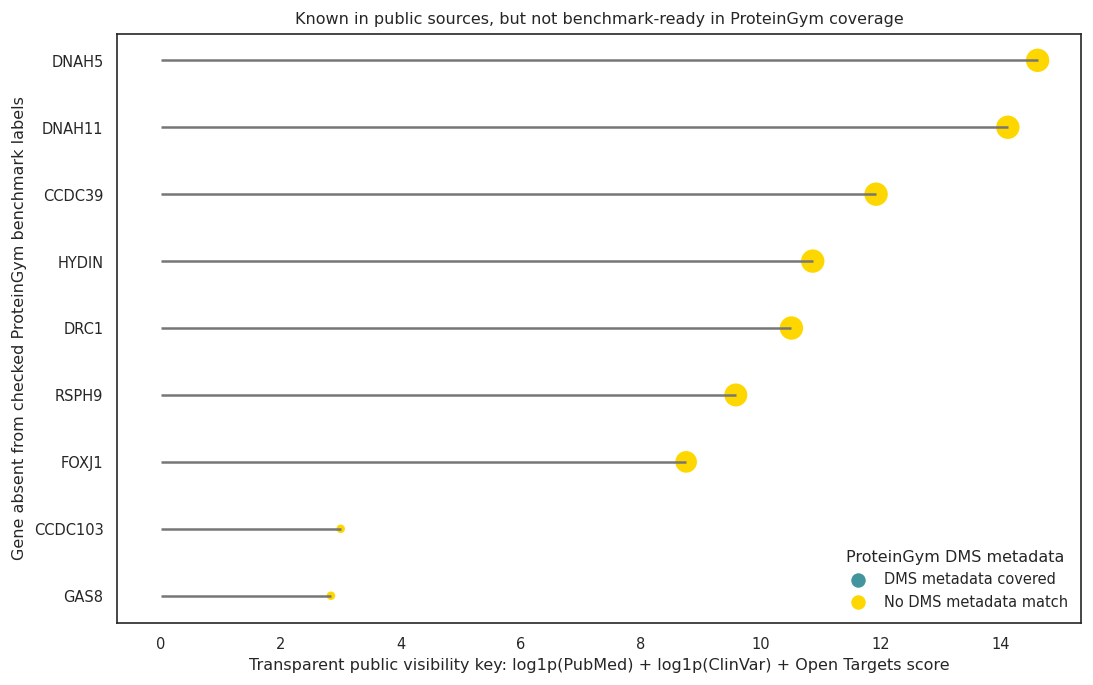

In [ ]:

wow_leaderboard_base = atlas_final_atlas_table.copy()
wow_leaderboard_base["benchmark_absent"] = ~wow_leaderboard_base["proteingym_covered"].astype(bool)
wow_leaderboard_base["dms_absent"] = ~wow_leaderboard_base["proteingym_dms_covered"].astype(bool)
wow_leaderboard_base["public_visibility_sort_key"] = (
    np.log1p(wow_leaderboard_base["pubmed_pcd_count_for_score"])
    + np.log1p(wow_leaderboard_base["clinvar_total_records"])
    + wow_leaderboard_base["opentargets_pcd_score"].fillna(0)
)
wow_known_not_benchmark_ready_leaderboard = (
    wow_leaderboard_base[
        wow_leaderboard_base["benchmark_absent"]
        & (
            (wow_leaderboard_base["pubmed_pcd_count_for_score"] > 0)
            | (wow_leaderboard_base["clinvar_total_records"] > 0)
            | (wow_leaderboard_base["opentargets_pcd_score"].fillna(0) > 0)
        )
    ][
        [
            "gene_symbol", "pcd_module", "diagnostic_visibility", "pubmed_pcd_count_for_score", "clinvar_total_records", "opentargets_pcd_score", "proteingym_covered", "proteingym_mapping_status", "proteingym_dms_covered", "proteingym_dms_assay_count", "public_visibility_sort_key", "top_gtex_tissue", "reproductive_max_minus_respiratory",
        ]
    ]
    .sort_values(["public_visibility_sort_key", "clinvar_total_records", "pubmed_pcd_count_for_score"], ascending=[False, False, False])
    .head(10)
)

fig_wow_leaderboard, ax_wow_leaderboard = plt.subplots(figsize=(9.2, 5.8))
wow_leaderboard_plot = wow_known_not_benchmark_ready_leaderboard.sort_values("public_visibility_sort_key")
ax_wow_leaderboard.hlines(
    y=wow_leaderboard_plot["gene_symbol"],
    xmin=0,
    xmax=wow_leaderboard_plot["public_visibility_sort_key"],
    color=PALETTE["neutral_mid"],
    linewidth=1.5,
)
ax_wow_leaderboard.scatter(
    wow_leaderboard_plot["public_visibility_sort_key"],
    wow_leaderboard_plot["gene_symbol"],
    s=np.clip(np.log1p(wow_leaderboard_plot["clinvar_total_records"]) * 38, 35, 220),
    color=np.where(wow_leaderboard_plot["proteingym_dms_covered"], PALETTE["teal"], PALETTE["gold"]),
    edgecolor="white",
    linewidth=0.8,
)
ax_wow_leaderboard.set_xlabel("Transparent public visibility key: log1p(PubMed) + log1p(ClinVar) + Open Targets score")
ax_wow_leaderboard.set_ylabel("Gene absent from checked ProteinGym benchmark labels")
ax_wow_leaderboard.set_title("Known in public sources, but not benchmark-ready in ProteinGym coverage")
ax_wow_leaderboard.scatter([], [], s=90, color=PALETTE["teal"], edgecolor="white", linewidth=0.8, label="DMS metadata covered")
ax_wow_leaderboard.scatter([], [], s=90, color=PALETTE["gold"], edgecolor="white", linewidth=0.8, label="No DMS metadata match")
ax_wow_leaderboard.legend(title="ProteinGym DMS metadata", loc="lower right", frameon=False)
fig_wow_leaderboard.tight_layout()
save_figure(fig_wow_leaderboard, "pcd_known_not_benchmark_ready_leaderboard")

wow_leaderboard_context_cards = wow_known_not_benchmark_ready_leaderboard.assign(
    curation_lead_note=lambda wow_frame: np.where(
        wow_frame["proteingym_dms_covered"],
        "Public disease visibility exists and a DMS assay is present, but checked ProteinGym clinical labels are absent.",
        "Public disease visibility exists, but checked ProteinGym clinical labels and DMS assay metadata are absent or not matched.",
    )
)[["gene_symbol", "pcd_module", "diagnostic_visibility", "pubmed_pcd_count_for_score", "clinvar_total_records", "opentargets_pcd_score", "proteingym_mapping_status", "proteingym_dms_covered", "curation_lead_note"]]

wow_leaderboard_review_table = pd.DataFrame(
    [
        {"gate": "Sort logic", "assessment": "Sort key is displayed and combines PubMed, ClinVar, and Open Targets visibility; components remain visible so the score is not opaque."},
        {"gate": "Claim integrity", "assessment": "'Known' means visible in public sources, not most important, severe, or clinically actionable."},
        {"gate": "Keep / revise / demote", "assessment": "Keep as an action map for benchmark curation; flag any PubMed-ambiguous genes in the table rather than hiding ambiguity."},
    ]
)

mo.vstack(
    [
        mo.md("## Known, But Not Benchmark-Ready\n\nThis leaderboard asks which genes are visible in public disease/literature/catalog layers but absent from checked ProteinGym benchmark labels."),
        mo.ui.table(wow_known_not_benchmark_ready_leaderboard, pagination=False),
        fig_wow_leaderboard,
        mo.ui.table(wow_leaderboard_context_cards, pagination=False),
        mo.md("### Review Gate: Leaderboard"),
        mo.ui.table(wow_leaderboard_review_table, pagination=False),
    ]
)

In [ ]:

wow_demo_storyboard = pd.DataFrame(
    [
        {
            "beat": "1. Hook",
            "claim": "PCD is multi-system motile-cilia biology, not just a respiratory keyword.",
            "evidence_to_show": "Dataset provenance + curated PCD panel + HPA ciliated-cell context.",
            "figure_or_table": "PCD panel, HPA support table",
            "caveat": "Public expression and catalog visibility are not patient-level phenotypes.",
        },
        {
            "beat": "2. Surprise",
            "claim": "The GTEx reproductive axis is prominent and often exceeds lung visibility.",
            "evidence_to_show": "Module tissue heatmap and reproductive-vs-lung scatter.",
            "figure_or_table": "module-by-tissue heatmap; reproductive vs lung axis",
            "caveat": "Bulk tissue expression is context, not fertility prediction.",
        },
        {
            "beat": "3. Control",
            "claim": "A small broader ciliary comparator shows the axis is not a trivial PCD-only artifact; it may reflect a wider ciliary program.",
            "evidence_to_show": f"Comparator resolved {wow_comparator_gtex_expression['gene_symbol'].nunique()}/{len(wow_comparator_panel)} genes; PCD and comparator summaries shown side by side.",
            "figure_or_table": "pcd_vs_ciliary_universe_axis",
            "caveat": "Comparator is curated and small, so specificity language stays cautious.",
        },
        {
            "beat": "4. Gap",
            "claim": "Benchmark-ready mutation-effect coverage is uneven; public disease visibility and ProteinGym visibility are not the same thing.",
            "evidence_to_show": "ProteinGym, ClinVar, PubMed, Open Targets, DMS, and gnomAD layers.",
            "figure_or_table": "evidence PCA; ClinVar vs ProteinGym; known-not-benchmark-ready leaderboard",
            "caveat": "Counts reflect public-resource visibility and query design, not clinical importance.",
        },
        {
            "beat": "5. Action Map",
            "claim": "The most useful output is a source-cited curation map: robust leads, fragile rankings, and explicit boundaries.",
            "evidence_to_show": f"Gap sensitivity identifies {wow_gap_rank_stability.iloc[0]['gene_symbol']} as the most scenario-robust top-5 lead; leaderboard exposes transparent components.",
            "figure_or_table": "gap sensitivity; source rows; final review gates",
            "caveat": "The ranking is heuristic and should guide data curation, not clinical decisions.",
        },
    ]
)

wow_final_finding_block = pd.DataFrame(
    [
        {"prompt": "What we found", "answer": "PCD genes occupy a strong reproductive/ciliated-tissue expression axis, while benchmark-ready mutation-effect resources cover the panel unevenly."},
        {"prompt": "Evidence", "answer": f"GTEx, ProteinGym, ClinVar, PubMed, Open Targets, gnomAD, HPA, and curated clinical-context sources were joined with review gates; baseline ProteinGym/ClinVar/PubMed/Open Targets visibility remains {int(atlas_final_atlas_table['proteingym_covered'].sum())}/{len(atlas_final_atlas_table)}, {int(atlas_final_atlas_table['clinvar_visible'].sum())}/{len(atlas_final_atlas_table)}, {int((atlas_final_atlas_table['pubmed_pcd_count_for_score'] > 0).sum())}/{len(atlas_final_atlas_table)}, and {int(atlas_final_atlas_table['opentargets_found'].sum())}/{len(atlas_final_atlas_table)}."},
        {"prompt": "Why it matters", "answer": "The notebook points to concrete public-data curation opportunities where disease visibility exists outside ProteinGym-ready benchmark labels."},
        {"prompt": "Caveat", "answer": "Every layer is a public-data visibility layer; none diagnoses PCD, predicts prognosis, recommends therapy, or interprets an individual's variants."},
    ]
)

wow_storyboard_review_table = pd.DataFrame(
    [
        {"gate": "Story flow", "assessment": "The final arc reduces the notebook to five beats: hook, surprise, control, gap, action map."},
        {"gate": "Figure count", "assessment": "Primary figures are limited to the heatmap/axis, comparator, evidence PCA, gap sensitivity, and leaderboard; other outputs remain supporting context."},
        {"gate": "Demo readiness", "assessment": "Keep as the judge-facing close: it names the memorable insight while preserving all clinical and data-source caveats."},
    ]
)

mo.vstack(
    [
        mo.md("## Demo Storyboard: Five Beats\n\nThis is the shortest path through the notebook for a judge-facing walkthrough."),
        mo.ui.table(wow_demo_storyboard, pagination=False),
        mo.md("### Final Finding Block"),
        mo.ui.table(wow_final_finding_block, pagination=False),
        mo.md("### Review Gate: Storyboard"),
        mo.ui.table(wow_storyboard_review_table, pagination=False),
    ]
)

Demo Storyboard: Five Beats 
 This is the shortest path through the notebook for a judge-facing walkthrough. <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"_marimo_row_id\":0,\"beat\":\"1. Hook\",\"claim\":\"PCD is multi-system motile-cilia biology, not just a respiratory keyword.\",\"evidence_to_show\":\"Dataset provenance + curated PCD panel + HPA ciliated-cell context.\",\"figure_or_table\":\"PCD panel, HPA support table\",\"caveat\":\"Public expression and catalog visibility are not patient-level phenotypes.\"},{\"_marimo_row_id\":1,\"beat\":\"2. Surprise\",\"claim\":\"The GTEx reproductive axis is prominent and often exceeds lung visibility.\",\"evidence_to_show\":\"Module tissue heatmap and reproductive-vs-lung scatter.\",\"figure_or_table\":\"module-by-tissue heatmap; reproductive vs lung axis\",\"caveat\":\"Bulk tissue expression is context, not fertility prediction.\"},{\"_marimo_row_id\":2,\"beat\":\"3. Control\",\"claim\":\"A small broader ciliary comparator shows the axis is not a trivial PCD-only artifact; it may reflect a wider ciliary program.\",\"evidence_to_show\":\"Comparator resolved 18/18 genes; PCD and comparator summaries shown side by side.\",\"figure_or_table\":\"pcd_vs_ciliary_universe_axis\",\"caveat\":\"Comparator is curated and small, so specificity language stays cautious.\"},{\"_marimo_row_id\":3,\"beat\":\"4. Gap\",\"claim\":\"Benchmark-ready mutation-effect coverage is uneven; public disease visibility and ProteinGym visibility are not the same thing.\",\"evidence_to_show\":\"ProteinGym, ClinVar, PubMed, Open Targets, DMS, and gnomAD layers.\",\"figure_or_table\":\"evidence PCA; ClinVar vs ProteinGym; known-not-benchmark-ready leaderboard\",\"caveat\":\"Counts reflect public-resource visibility and query design, not clinical importance.\"},{\"_marimo_row_id\":4,\"beat\":\"5. Action Map\",\"claim\":\"The most useful output is a source-cited curation map: robust leads, fragile rankings, and explicit boundaries.\",\"evidence_to_show\":\"Gap sensitivity identifies DRC1 as the most scenario-robust top-5 lead; leaderboard exposes transparent components.\",\"figure_or_table\":\"gap sensitivity; source rows; final review gates\",\"caveat\":\"The ranking is heuristic and should guide data curation, not clinical decisions.\"}]"' data-total-rows='5' data-total-columns='5' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='5' data-field-types='[["beat",["string","str"]],["claim",["string","str"]],["evidence_to_show",["string","str"]],["figure_or_table",["string","str"]],["caveat",["string","str"]]]' data-selection='"multi"' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='true' data-lazy='false' data-preload='false'> Final Finding Block <marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"_marimo_row_id\":0,\"prompt\":\"What we found\",\"answer\":\"PCD genes occupy a strong reproductive/ciliated-tissue expression axis, while benchmark-ready mutation-effect resources cover the panel unevenly.\"},{\"_marimo_row_id\":1,\"prompt\":\"Evidence\",\"answer\":\"GTEx, ProteinGym, ClinVar, PubMed, Open Targets, gnomAD, HPA, and curated clinical-context sources were joined with review gates; baseline ProteinGym/ClinVar/PubMed/Open Targets visibility remains 17/26, 20/26, 26/26, and 20/26.\"},{\"_marimo_row_id\":2,\"prompt\":\"Why it matters\",\"answer\":\"The notebook points to concrete public-data curation opportunities where disease visibility exists outside ProteinGym-ready benchmark labels.\"},{\"_marimo_row_id\":3,\"prompt\":\"Caveat\",\"answer\":\"Every layer is a public-data visibility layer; none diagnoses PCD, predicts prognosis, recommends therapy, or interprets an individual's variants.\"}]"' data-total-rows='4' data-total-c